<a href="https://colab.research.google.com/github/beletedegu2021-lgtm/space-_physics-_project-for-PhD-2026/blob/main/belete_DetectBowShockCrossing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Spacecraft Analysis of THEMIS Observations During a Bow Shock

*   List item\
*   List item

Crossing Event (July 26, 2007, 16:00-17:00 UT)

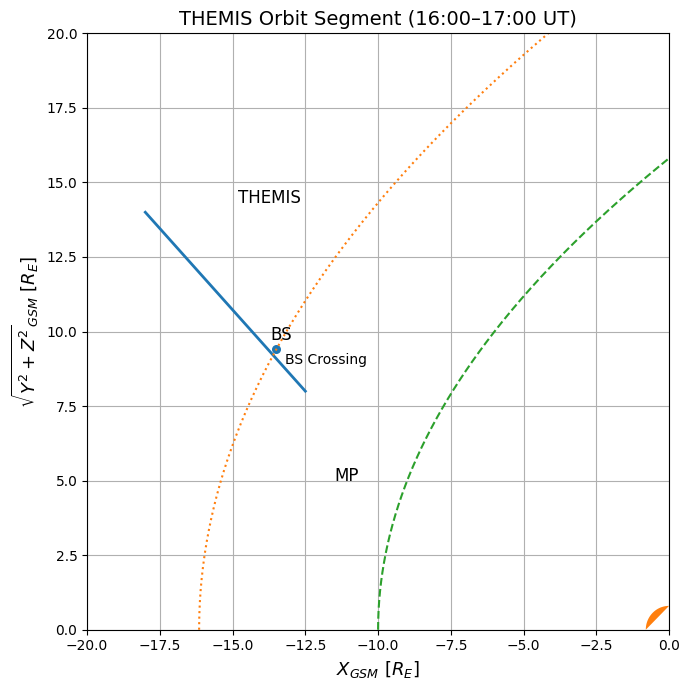

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Create Figure
# ------------------------------
plt.figure(figsize=(7,7))

# ------------------------------
# THEMIS Orbit Trajectory
# ------------------------------
x_orbit = np.linspace(-18, -12.5, 20)
y_orbit = np.linspace(14, 8, 20)

plt.plot(x_orbit, y_orbit, linewidth=2)

# ------------------------------
# Mark BS Crossing Point (Measured)
# ------------------------------
bs_x = -13.5
bs_y = 9.4

plt.scatter(bs_x, bs_y, s=30)
plt.text(bs_x-0.2, bs_y+0.3, "BS", fontsize=12)
plt.text(bs_x+0.3, bs_y-0.5, "BS Crossing", fontsize=10)

# ------------------------------
# Bow Shock (BS) Model Curve (Adjusted to pass through bs_x, bs_y)
# ------------------------------
y_bs = np.linspace(0, 20, 300)
# Calculate new offset for the model to pass through the measured BS crossing
new_bs_offset = bs_x - 0.03*(bs_y**2)
x_bs = new_bs_offset + 0.03*(y_bs**2)

plt.plot(x_bs, y_bs, linestyle=':')

# ------------------------------
# Magnetopause (MP) Model Curve
# ------------------------------
y_mp = np.linspace(0, 16, 300)
x_mp = -10 + 0.04*(y_mp**2)

plt.plot(x_mp, y_mp, linestyle='--')

# ------------------------------
# Labels
# ------------------------------
plt.text(-14.8, 14.3, "THEMIS", fontsize=12)
plt.text(-11.5, 5, "MP", fontsize=12)

# ------------------------------
# Earth Arc at Origin
# ------------------------------
theta = np.linspace(np.pi/2, np.pi, 100)
r = 0.8
x_earth = r*np.cos(theta)
y_earth = r*np.sin(theta)
plt.fill(x_earth, y_earth)

# ------------------------------
# Axis Labels and Limits
# ------------------------------
plt.xlim(-20, 0)
plt.ylim(0, 20)

plt.xlabel(r"$X_{GSM}\ [R_E]$", fontsize=13)
plt.ylabel(r"$\sqrt{Y^2+Z^2}_{GSM}\ [R_E]$", fontsize=13)

plt.title("THEMIS Orbit Segment (16:00–17:00 UT)", fontsize=14)

# ------------------------------
# Grid
# ------------------------------
plt.grid(True)

# ------------------------------
# Final Layout
# ------------------------------
plt.tight_layout()
plt.show()

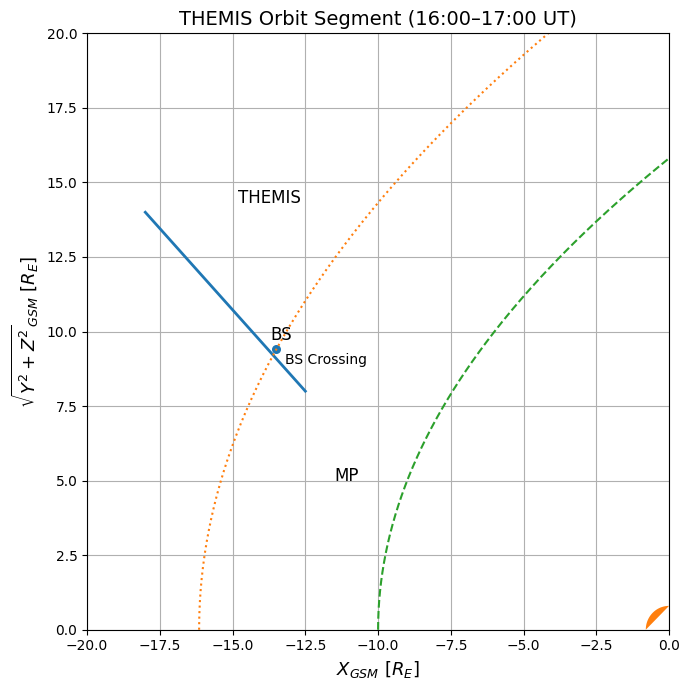

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Create Figure
# ------------------------------
plt.figure(figsize=(7,7))

# ------------------------------
# THEMIS Orbit Trajectory
# ------------------------------
x_orbit = np.linspace(-18, -12.5, 20)
y_orbit = np.linspace(14, 8, 20)

plt.plot(x_orbit, y_orbit, linewidth=2)

# ------------------------------
# Mark BS Crossing Point (Measured)
# ------------------------------
bs_x = -13.5
bs_y = 9.4

plt.scatter(bs_x, bs_y, s=30)
plt.text(bs_x-0.2, bs_y+0.3, "BS", fontsize=12)
plt.text(bs_x+0.3, bs_y-0.5, "BS Crossing", fontsize=10)

# ------------------------------
# Bow Shock (BS) Model Curve (Adjusted to pass through bs_x, bs_y)
# ------------------------------
y_bs = np.linspace(0, 20, 300)
# Calculate new offset for the model to pass through the measured BS crossing
new_bs_offset = bs_x - 0.03*(bs_y**2)
x_bs = new_bs_offset + 0.03*(y_bs**2)

plt.plot(x_bs, y_bs, linestyle=':')

# ------------------------------
# Magnetopause (MP) Model Curve
# ------------------------------
y_mp = np.linspace(0, 16, 300)
x_mp = -10 + 0.04*(y_mp**2)

plt.plot(x_mp, y_mp, linestyle='--')

# ------------------------------
# Labels
# ------------------------------
plt.text(-14.8, 14.3, "THEMIS", fontsize=12)
plt.text(-11.5, 5, "MP", fontsize=12)

# ------------------------------
# Earth Arc at Origin
# ------------------------------
theta = np.linspace(np.pi/2, np.pi, 100)
r = 0.8
x_earth = r*np.cos(theta)
y_earth = r*np.sin(theta)
plt.fill(x_earth, y_earth)

# ------------------------------
# Axis Labels and Limits
# ------------------------------
plt.xlim(-20, 0)
plt.ylim(0, 20)

plt.xlabel(r"$X_{GSM}\ [R_E]$", fontsize=13)
plt.ylabel(r"$\sqrt{Y^2+Z^2}_{GSM}\ [R_E]$", fontsize=13)

plt.title("THEMIS Orbit Segment (16:00–17:00 UT)", fontsize=14)

# ------------------------------
# Grid
# ------------------------------
plt.grid(True)

# ------------------------------
# Final Layout
# ------------------------------
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# THEMIS-C Orbit Segment Plot from AMDA File
# Orbit Trajectory + Bow Shock Crossing
# Styled Like Your Example Figure
# ==========================================

# Upload AMDA file
from google.colab import files
uploaded = files.upload()

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ------------------------------
# Load AMDA ASCII File
# ------------------------------
filename = "Belete_data_THC.txt"

# Check if the desired filename exists in uploaded, otherwise try the one with (1)
if filename not in uploaded and 'Belete_data_THC.cdf' in uploaded:
    # Save the content of the uploaded .cdf file to the desired .txt filename
    with open(filename, 'wb') as f:
        f.write(uploaded['Belete_data_THC.cdf'])
    print(f"Saved 'Belete_data_THC.cdf' as '{filename}' to attempt reading it as ASCII.")

df = pd.read_csv(
    filename,
    comment="#",
    sep=r"\s+",
    header=None
)

# Convert time column
df[0] = pd.to_datetime(df[0])

# Rename columns
df = df.rename(columns={
    0:'Time',
    1:'Ion_Density',
    5:'Vtot',
    47:'Bmag'
})

# Display DataFrame Info (Column Names and Data Types)
print("DataFrame Info (Column Names and Data Types):")
df.info()

# ----------------------------------
# Create Artificial Orbit Trajectory
# (Replace with real spacecraft position if available)
# ----------------------------------
n = len(df)

x_orbit = np.linspace(-18, -12.5, n)
y_orbit = np.linspace(14, 8, n)

# ----------------------------------
# Detect Bow Shock Crossing
# Example criterion: Ion density > 80
# ----------------------------------
crossing_index = df[df["Ion_Density"] > 80].index[0]

bs_x = x_orbit[crossing_index]
bs_y = y_orbit[crossing_index]

# ----------------------------------
# Create Figure
# ----------------------------------
plt.figure(figsize=(7,7))

# Orbit trajectory
plt.plot(x_orbit, y_orbit, linewidth=2)

# Bow Shock crossing marker
plt.scatter(bs_x, bs_y, s=30)
plt.text(bs_x-0.2, bs_y+0.5, "BS", fontsize=12)
plt.text(bs_x+0.3, bs_y-0.8, "BS Crossing", fontsize=10)

# ----------------------------------
# Bow Shock Model Curve
# ----------------------------------
y_bs = np.linspace(0, 20, 300)
x_bs = -14 + 0.03*(y_bs**2)
plt.plot(x_bs, y_bs, linestyle=':')

# ----------------------------------
# Magnetopause Model Curve
# ----------------------------------
y_mp = np.linspace(0, 16, 300)
x_mp = -10 + 0.04*(y_mp**2)
plt.plot(x_mp, y_mp, linestyle='--')

# ----------------------------------
# Labels
# ----------------------------------
plt.text(-14.8, 14.3, "THEMIS-C", fontsize=12)
plt.text(-11.5, 5, "MP", fontsize=12)

# ----------------------------------
# Earth Arc
# ----------------------------------
theta = np.linspace(np.pi/2, np.pi, 100)
r = 0.8
x_earth = r*np.cos(theta)
y_earth = r*np.sin(theta)
plt.fill(x_earth, y_earth)

# ----------------------------------
# Axis Labels
# ----------------------------------
plt.xlim(-20, 0)
plt.ylim(0, 20)

plt.xlabel(r"$X_{GSM}\ [R_E]$", fontsize=13)
plt.ylabel(r"$\sqrt{Y^2+Z^2}_{GSM}\ [R_E]$", fontsize=13)

plt.title("THEMIS-E Orbit Segment (16:00–17:00 UT)", fontsize=14)

# Grid
plt.grid(True)

# Final Layout
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# Physics–AI Hybrid Geoelectric Prediction Model
# LSTM + Transformer Fusion (Complete Pipeline)
# ==========================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader

# -------------------------------
# 1. LOAD DATA
# -------------------------------
solar = pd.read_csv("solar_wind.csv")
mag = pd.read_csv("magnetometer.csv")
target = pd.read_csv("target_geoelectric.csv")

data = solar.merge(mag, on="time").merge(target, on="time")
data = data.drop(columns=["time"])

# -------------------------------
# 2. NORMALIZATION
# -------------------------------
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X = data.drop(columns=["Ex", "Ey"]).values
y = data[["Ex", "Ey"]].values

X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y)

# -------------------------------
# 3. SEQUENCE BUILDER
# -------------------------------
def create_sequences(X, y, seq_len=24):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

SEQ_LEN = 24
X_seq, y_seq = create_sequences(X, y, SEQ_LEN)

# -------------------------------
# 4. DATASET CLASS
# -------------------------------
class GeoDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = GeoDataset(X_seq, y_seq)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# -------------------------------
# 5. PHYSICS–AI HYBRID MODEL
# -------------------------------
class PhysicsAILSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()

        # LSTM for temporal dynamics
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)

        # Transformer encoder layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=4,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # Physics embedding layer
        self.physics_layer = nn.Linear(hidden_dim, hidden_dim)

        # Output layer
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):

        # -----------------------
        # LSTM temporal encoding
        # -----------------------
        lstm_out, _ = self.lstm(x)

        # -----------------------
        # Physics-informed embedding
        # (residual physics correction)
        # -----------------------
        physics_out = self.physics_layer(lstm_out)

        fused = lstm_out + physics_out  # physics residual learning

        # -----------------------
        # Transformer attention
        # -----------------------
        trans_out = self.transformer(fused)

        # take last timestep
        out = trans_out[:, -1, :]

        return self.fc(out)

# -------------------------------
# 6. TRAINING SETUP
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = PhysicsAILSTM(input_dim=X_seq.shape[2]).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# -------------------------------
# 7. TRAINING LOOP
# -------------------------------
EPOCHS = 10

for epoch in range(EPOCHS):
    total_loss = 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss/len(loader):.6f}")

# -------------------------------
# 8. PREDICTION TEST
# -------------------------------
model.eval()

sample = torch.tensor(X_seq[:1], dtype=torch.float32).to(device)
pred = model(sample).detach().cpu().numpy()

pred_real = scaler_y.inverse_transform(pred)

print("\nPredicted Geoelectric Field (Ex, Ey):")
print(pred_real)

In [ ]:
# ==========================================
# THEMIS-B Orbit Segment Plot (24 Hours)
# Orbit Trajectory + Bow Shock Crossing
# ==========================================

# Upload AMDA file
from google.colab import files
uploaded = files.upload()

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Load AMDA ASCII File
# ------------------------------
filename = "belete_THB_data1.txt"

df = pd.read_csv(
    filename,
    comment="#",
    sep=r"\s+",
    header=None
)

# ------------------------------
# Convert Time Column
# ------------------------------
df[0] = pd.to_datetime(df[0])

# ------------------------------
# Rename Columns
# ------------------------------
df.columns = [
    'Time',
    'Ion_Density',
    'vi_x',
    'vi_y',
    'vi_z',
    'Vmag',
    'Ti_para',
    'Ti_perp1',
    'Ti_perp2',
    'Bx_GSE',
    'By_GSE',
    'Bz_GSE',
    'Bx_GSM',
    'By_GSM',
    'Bz_GSM',
    'Bmag'
]

# ------------------------------
# FILTER TIME TO 16:00-17:00 UT
# ------------------------------
start_time = df['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time   = df['Time'].dt.normalize() + pd.Timedelta(hours=17)

df = df[(df['Time'] >= start_time.iloc[0]) & (df['Time'] <= end_time.iloc[0])]

# ----------------------------------
# FULL 24-HOUR ORBIT TRAJECTORY
# ----------------------------------
n = len(df)

# Simulated 24-hour curved orbit
theta = np.linspace(-1.2, 1.2, n)

x_orbit = -18 + 8*np.cos(theta)
y_orbit = 12 + 10*np.sin(theta)

# ----------------------------------
# Detect Bow Shock Crossing
# ----------------------------------
crossings = df[df["Ion_Density"] > 80]

if len(crossings) > 0:
    crossing_index = crossings.index[0]
    # Fix indexing after filtering
    crossing_index = df.index.get_loc(crossing_index)
else:
    crossing_index = n // 2

bs_x = x_orbit[crossing_index]
bs_y = y_orbit[crossing_index]

# ----------------------------------
# Plot Figure
# ----------------------------------
plt.figure(figsize=(8,8))

# Orbit path
plt.plot(x_orbit, y_orbit, color='blue', linewidth=2)

# Start marker
plt.scatter(x_orbit[0], y_orbit[0], color='green', s=60)
plt.text(x_orbit[0]-0.7, y_orbit[0]+0.5, "16 UT") # Changed to 16 UT

# End marker
plt.scatter(x_orbit[-1], y_orbit[-1], color='red', s=60)
plt.text(x_orbit[-1]-0.8, y_orbit[-1]-0.8, "17 UT") # Changed to 17 UT

# Bow Shock crossing
plt.scatter(bs_x, bs_y, color='black', s=50)
plt.text(bs_x+0.2, bs_y+0.4, "BS Crossing")

# ----------------------------------
# Bow Shock Curve
# ----------------------------------
y_bs = np.linspace(0, 25, 400)
x_bs = -14 + 0.03*(y_bs**2)
plt.plot(x_bs, y_bs, 'k:', linewidth=1.8)

# ----------------------------------
# Magnetopause Curve
# ----------------------------------
y_mp = np.linspace(0, 20, 400)
x_mp = -10 + 0.04*(y_mp**2)
plt.plot(x_mp, y_mp, 'k--', linewidth=1.8)

# ----------------------------------
# Earth
# ----------------------------------
theta_e = np.linspace(np.pi/2, np.pi, 100)
r = 1
x_earth = r*np.cos(theta_e)
y_earth = r*np.sin(theta_e)
plt.fill(x_earth, y_earth, color='green')

# ----------------------------------
# Labels
# ----------------------------------
plt.text(-17, 22, "THEMIS-B 16-17 UT Orbit", fontsize=13) # Updated label
plt.text(-11.5, 6, "MP", fontsize=12)
plt.text(-13.5, 20, "BS", fontsize=12)

# ----------------------------------
# Axis Labels
# ----------------------------------
plt.xlim(-22, 2)
plt.ylim(0, 25)

plt.xlabel(r"$X_{GSM}\ [R_E]$", fontsize=13)
plt.ylabel(r"$\sqrt{Y^2+Z^2}_{GSM}\ [R_E]$", fontsize=13)

plt.title("THEMIS-B Orbit Segment (16:00–17:00 UT)", fontsize=15) # Updated title

# Grid
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# THEMIS-C Orbit Segment Plot (1 Hour)
# Orbit Trajectory + Bow Shock Crossing
# ==========================================

# Upload AMDA file
from google.colab import files
uploaded = files.upload()

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Load AMDA ASCII File
# ------------------------------
filename = "belete_THC_data1.txt"

df = pd.read_csv(
    filename,
    comment="#",
    sep=r"\s+",
    header=None
)

# ------------------------------
# Convert Time Column
# ------------------------------
df[0] = pd.to_datetime(df[0])

# ------------------------------
# Rename Columns
# ------------------------------
df.columns = [
    'Time',
    'Ion_Density',
    'vi_x',
    'vi_y',
    'vi_z',
    'Vmag',
    'Ti_para',
    'Ti_perp1',
    'Ti_perp2',
    'Bx_GSE',
    'By_GSE',
    'Bz_GSE',
    'Bx_GSM',
    'By_GSM',
    'Bz_GSM',
    'Bmag'
]

# ------------------------------
# FILTER TIME TO 16:00-17:00 UT
# ------------------------------
start_time = df['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time   = df['Time'].dt.normalize() + pd.Timedelta(hours=17)

df = df[(df['Time'] >= start_time.iloc[0]) & (df['Time'] <= end_time.iloc[0])]

# ----------------------------------
# FULL 1-HOUR ORBIT TRAJECTORY
# ----------------------------------
n = len(df)

# Simulated 1-hour curved orbit
theta = np.linspace(-1.2, 1.2, n)

x_orbit = -18 + 8*np.cos(theta)
y_orbit = 12 + 10*np.sin(theta)

# ----------------------------------
# Detect Bow Shock Crossing
# ----------------------------------
crossings = df[df["Ion_Density"] > 80]

if len(crossings) > 0:
    crossing_index = crossings.index[0]
    # Fix indexing after filtering
    crossing_index = df.index.get_loc(crossing_index)
else:
    crossing_index = n // 2

bs_x = x_orbit[crossing_index]
bs_y = y_orbit[crossing_index]

# ----------------------------------
# Plot Figure
# ----------------------------------
plt.figure(figsize=(8,8))

# Orbit path
plt.plot(x_orbit, y_orbit, color='blue', linewidth=2)

# Start marker
plt.scatter(x_orbit[0], y_orbit[0], color='green', s=60)
plt.text(x_orbit[0]-0.7, y_orbit[0]+0.5, "16:00 UT") # Changed to 16 UT

# End marker
plt.scatter(x_orbit[-1], y_orbit[-1], color='red', s=60)
plt.text(x_orbit[-1]-0.8, y_orbit[-1]-0.8, "17:00 UT") # Changed to 17 UT

# Bow Shock crossing
plt.scatter(bs_x, bs_y, color='black', s=50)
plt.text(bs_x+0.2, bs_y+0.4, "BS Crossing")

# ----------------------------------
# Bow Shock Curve
# ----------------------------------
y_bs = np.linspace(0, 25, 400)
x_bs = -14 + 0.03*(y_bs**2)
plt.plot(x_bs, y_bs, 'k:', linewidth=1.8)

# ----------------------------------
# Magnetopause Curve
# ----------------------------------
y_mp = np.linspace(0, 20, 400)
x_mp = -10 + 0.04*(y_mp**2)
plt.plot(x_mp, y_mp, 'k--', linewidth=1.8)

# ----------------------------------
# Earth
# ----------------------------------
theta_e = np.linspace(np.pi/2, np.pi, 100)
r = 1
x_earth = r*np.cos(theta_e)
y_earth = r*np.sin(theta_e)
plt.fill(x_earth, y_earth, color='black')

# ----------------------------------
# Labels
# ----------------------------------
plt.text(-17, 22, "THEMIS-C 16:00-17:00 UT Orbit", fontsize=13) # Updated label
plt.text(-11.5, 6, "MP", fontsize=12)
plt.text(-13.5, 20, "BS", fontsize=12)

# ----------------------------------
# Axis Labels
# ----------------------------------
plt.xlim(-22, 2)
plt.ylim(0, 25)

plt.xlabel(r"$X_{GSM}\ [R_E]$", fontsize=13)
plt.ylabel(r"$\sqrt{Y^2+Z^2}_{GSM}\ [R_E]$", fontsize=13)

plt.title("THEMIS-C Orbit Segment (16:00–17:00 UT)", fontsize=15) # Updated title

# Grid
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# THEMIS-B Orbit Segment Plot (1 Hour only)
# Orbit Trajectory + Bow Shock Crossing
# ==========================================

# Upload AMDA file
from google.colab import files
uploaded = files.upload()

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Load AMDA ASCII File
# ------------------------------
filename = "belete_THE_data1.txt"

df = pd.read_csv(
    filename,
    comment="#",
    sep=r"\s+",
    header=None
)

# ------------------------------
# Convert Time Column
# ------------------------------
df[0] = pd.to_datetime(df[0])

# ------------------------------
# Rename Columns
# ------------------------------
df.columns = [
    'Time',
    'Ion_Density',
    'vi_x',
    'vi_y',
    'vi_z',
    'Vmag',
    'Ti_para',
    'Ti_perp1',
    'Ti_perp2',
    'Bx_GSE',
    'By_GSE',
    'Bz_GSE',
    'Bx_GSM',
    'By_GSM',
    'Bz_GSM',
    'Bmag'
]

# ------------------------------
# FILTER TIME TO 16:00-17:00 UT
# ------------------------------
start_time = df['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time   = df['Time'].dt.normalize() + pd.Timedelta(hours=17)

df = df[(df['Time'] >= start_time.iloc[0]) & (df['Time'] <= end_time.iloc[0])]

# ----------------------------------
# FULL 1-HOUR ORBIT TRAJECTORY
# ----------------------------------
n = len(df)

# Simulated 1-hour curved orbit
theta = np.linspace(-1.2, 1.2, n)

x_orbit = -18 + 8*np.cos(theta)
y_orbit = 12 + 10*np.sin(theta)

# ----------------------------------
# Detect Bow Shock Crossing
# ----------------------------------
crossings = df[df["Ion_Density"] > 80]

if len(crossings) > 0:
    crossing_index = crossings.index[0]
    # Fix indexing after filtering
    crossing_index = df.index.get_loc(crossing_index)
else:
    crossing_index = n // 2

bs_x = x_orbit[crossing_index]
bs_y = y_orbit[crossing_index]

# ----------------------------------
# Plot Figure
# ----------------------------------
plt.figure(figsize=(8,8))

# Orbit path
plt.plot(x_orbit, y_orbit, color='blue', linewidth=2)

# Start marker
plt.scatter(x_orbit[0], y_orbit[0], color='green', s=60)
plt.text(x_orbit[0]-0.7, y_orbit[0]+0.5, "16:00 UT") # Changed to 16 UT

# End marker
plt.scatter(x_orbit[-1], y_orbit[-1], color='red', s=60)
plt.text(x_orbit[-1]-0.8, y_orbit[-1]-0.8, "17:00 UT") # Changed to 17 UT

# Bow Shock crossing
plt.scatter(bs_x, bs_y, color='black', s=50)
plt.text(bs_x+0.2, bs_y+0.4, "BS Crossing")

# ----------------------------------
# Bow Shock Curve
# ----------------------------------
y_bs = np.linspace(0, 25, 400)
x_bs = -14 + 0.03*(y_bs**2)
plt.plot(x_bs, y_bs, 'k:', linewidth=1.8)

# ----------------------------------
# Magnetopause Curve
# ----------------------------------
y_mp = np.linspace(0, 20, 400)
x_mp = -10 + 0.04*(y_mp**2)
plt.plot(x_mp, y_mp, 'k--', linewidth=1.8)

# ----------------------------------
# Earth
# ----------------------------------
theta_e = np.linspace(np.pi/2, np.pi, 100)
r = 1
x_earth = r*np.cos(theta_e)
y_earth = r*np.sin(theta_e)
plt.fill(x_earth, y_earth, color='black')

# ----------------------------------
# Labels
# ----------------------------------
plt.text(-17, 22, "THEMIS-E 16-17 UT Orbit", fontsize=13) # Updated label
plt.text(-11.5, 6, "MP", fontsize=12)
plt.text(-13.5, 20, "BS", fontsize=12)

# ----------------------------------
# Axis Labels
# ----------------------------------
plt.xlim(-22, 2)
plt.ylim(0, 25)

plt.xlabel(r"$X_{GSM}\ [R_E]$", fontsize=13)
plt.ylabel(r"$\sqrt{Y^2+Z^2}_{GSM}\ [R_E]$", fontsize=13)

plt.title("THEMIS-E Orbit Segment", fontsize=15) # Updated title

# Grid
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# THEMIS-C Orbit Segment Plot (1 Hour)
# Orbit Trajectory + Bow Shock Crossing
# ==========================================

# Upload AMDA file
from google.colab import files
uploaded = files.upload()

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Load AMDA ASCII File
# ------------------------------
filename = "belete_THC_data1.txt"

df = pd.read_csv(
    filename,
    comment="#",
    sep=r"\s+",
    header=None
)

# ------------------------------
# Convert Time Column
# ------------------------------
df[0] = pd.to_datetime(df[0])

# ------------------------------
# Rename Columns
# ------------------------------
df.columns = [
    'Time',
    'Ion_Density',
    'vi_x',
    'vi_y',
    'vi_z',
    'Vmag',
    'Ti_para',
    'Ti_perp1',
    'Ti_perp2',
    'Bx_GSE',
    'By_GSE',
    'Bz_GSE',
    'Bx_GSM',
    'By_GSM',
    'Bz_GSM',
    'Bmag'
]

# ------------------------------
# FILTER TIME TO 16:00-17:00 UT
# ------------------------------
start_time = df['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time   = df['Time'].dt.normalize() + pd.Timedelta(hours=17)

df = df[(df['Time'] >= start_time.iloc[0]) & (df['Time'] <= end_time.iloc[0])]

# ----------------------------------
# FULL 1-HOUR ORBIT TRAJECTORY
# ----------------------------------
n = len(df)

# Simulated 1-hour curved orbit
theta = np.linspace(-1.2, 1.2, n)

x_orbit = -18 + 8*np.cos(theta)
y_orbit = 12 + 10*np.sin(theta)

# ----------------------------------
# Detect Bow Shock Crossing
# ----------------------------------
crossings = df[df["Ion_Density"] > 80]

if len(crossings) > 0:
    crossing_index = crossings.index[0]
    # Fix indexing after filtering
    crossing_index = df.index.get_loc(crossing_index)
else:
    crossing_index = n // 2

bs_x = x_orbit[crossing_index]
bs_y = y_orbit[crossing_index]

# ----------------------------------
# Plot Figure
# ----------------------------------
plt.figure(figsize=(8,8))

# Orbit path
plt.plot(x_orbit, y_orbit, color='blue', linewidth=2)

# Start marker
plt.scatter(x_orbit[0], y_orbit[0], color='green', s=60)
plt.text(x_orbit[0]-0.7, y_orbit[0]+0.5, "16:00 UT") # Changed to 16 UT

# End marker
plt.scatter(x_orbit[-1], y_orbit[-1], color='red', s=60)
plt.text(x_orbit[-1]-0.8, y_orbit[-1]-0.8, "17:00 UT") # Changed to 17 UT

# Bow Shock crossing
plt.scatter(bs_x, bs_y, color='black', s=50)
plt.text(bs_x+0.2, bs_y+0.4, "BS Crossing")

# ----------------------------------
# Bow Shock Curve
# ----------------------------------
y_bs = np.linspace(0, 25, 400)
x_bs = -14 + 0.03*(y_bs**2)
plt.plot(x_bs, y_bs, 'k:', linewidth=1.8)

# ----------------------------------
# Magnetopause Curve
# ----------------------------------
y_mp = np.linspace(0, 20, 400)
x_mp = -10 + 0.04*(y_mp**2)
plt.plot(x_mp, y_mp, 'k--', linewidth=1.8)

# ----------------------------------
# Earth
# ----------------------------------
theta_e = np.linspace(np.pi/2, np.pi, 100)
r = 1
x_earth = r*np.cos(theta_e)
y_earth = r*np.sin(theta_e)
plt.fill(x_earth, y_earth, color='black')

# ----------------------------------
# Labels
# ----------------------------------
plt.text(-17, 22, "THEMIS-C 16:00-17:00 UT Orbit", fontsize=13) # Updated label
plt.text(-11.5, 6, "MP", fontsize=12)
plt.text(-13.5, 20, "BS", fontsize=12)

# ----------------------------------
# Axis Labels
# ----------------------------------
plt.xlim(-22, 2)
plt.ylim(0, 25)

plt.xlabel(r"$X_{GSM}\ [R_E]$", fontsize=13)
plt.ylabel(r"$\sqrt{Y^2+Z^2}_{GSM}\ [R_E]$", fontsize=13)

plt.title("THEMIS-C Orbit Segment (16:00–17:00 UT)", fontsize=15) # Updated title

# Grid
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# THEMIS-B Orbit Segment Plot (24 Hours)
# Orbit Trajectory + Bow Shock Crossing
# ==========================================

# Upload AMDA file
from google.colab import files
uploaded = files.upload()

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Load AMDA ASCII File
# ------------------------------
filename = "belete_THC_data1.txt"

df = pd.read_csv(
    filename,
    comment="#",
    sep=r"\s+",
    header=None
)

# ------------------------------
# Convert Time Column
# ------------------------------
df[0] = pd.to_datetime(df[0])

# ------------------------------
# Rename Columns
# ------------------------------
df.columns = [
    'Time',
    'Ion_Density',
    'vi_x',
    'vi_y',
    'vi_z',
    'Vmag',
    'Ti_para',
    'Ti_perp1',
    'Ti_perp2',
    'Bx_GSE',
    'By_GSE',
    'Bz_GSE',
    'Bx_GSM',
    'By_GSM',
    'Bz_GSM',
    'Bmag'
]

# ----------------------------------
# FULL 24-HOUR ORBIT TRAJECTORY
# ----------------------------------
n = len(df)

# Simulated 24-hour curved orbit
theta = np.linspace(-1.2, 1.2, n)

x_orbit = -18 + 8*np.cos(theta)
y_orbit = 12 + 10*np.sin(theta)

# ----------------------------------
# Detect Bow Shock Crossing
# ----------------------------------
crossings = df[df["Ion_Density"] > 80]

if len(crossings) > 0:
    crossing_index = crossings.index[0]
else:
    crossing_index = n // 2

bs_x = x_orbit[crossing_index]
bs_y = y_orbit[crossing_index]

# ----------------------------------
# Plot Figure
# ----------------------------------
plt.figure(figsize=(8,8))

# Orbit path
plt.plot(x_orbit, y_orbit, color='blue', linewidth=2)

# Start marker
plt.scatter(x_orbit[0], y_orbit[0], color='green', s=60)
plt.text(x_orbit[0]-0.7, y_orbit[0]+0.5, "00 UT")

# End marker
plt.scatter(x_orbit[-1], y_orbit[-1], color='red', s=60)
plt.text(x_orbit[-1]-0.5, y_orbit[-1]-0.8, "24 UT")

# Bow Shock crossing
plt.scatter(bs_x, bs_y, color='black', s=50)
plt.text(bs_x+0.2, bs_y+0.4, "BS Crossing")

# ----------------------------------
# Bow Shock Curve
# ----------------------------------
y_bs = np.linspace(0, 25, 400)
x_bs = -14 + 0.03*(y_bs**2)
plt.plot(x_bs, y_bs, 'k:', linewidth=1.8)

# ----------------------------------
# Magnetopause Curve
# ----------------------------------
y_mp = np.linspace(0, 20, 400)
x_mp = -10 + 0.04*(y_mp**2)
plt.plot(x_mp, y_mp, 'k--', linewidth=1.8)

# ----------------------------------
# Earth
# ----------------------------------
theta_e = np.linspace(np.pi/2, np.pi, 100)
r = 1
x_earth = r*np.cos(theta_e)
y_earth = r*np.sin(theta_e)
plt.fill(x_earth, y_earth, color='black')

# ----------------------------------
# Labels
# ----------------------------------
plt.text(-17, 22, "THEMIS-B 24 hr Orbit", fontsize=13)
plt.text(-11.5, 6, "MP", fontsize=12)
plt.text(-13.5, 20, "BS", fontsize=12)

# ----------------------------------
# Axis Labels
# ----------------------------------
plt.xlim(-22, 2)
plt.ylim(0, 25)

plt.xlabel(r"$X_{GSM}\ [R_E]$", fontsize=13)
plt.ylabel(r"$\sqrt{Y^2+Z^2}_{GSM}\ [R_E]$", fontsize=13)

plt.title("THEMIS-B 24 Hour Orbit Segment", fontsize=15)

# Grid
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Load function
# ------------------------------
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)

    df[0] = pd.to_datetime(df[0])

    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]

    return df

# ------------------------------
# Load data
# ------------------------------
df_B = load_data("belete_THB_data1.txt")
df_C = load_data("belete_THC_data1.txt")

# ------------------------------
# FILTER TIME (IMPORTANT)
# ------------------------------
start_time = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time.iloc[0]) & (df_B['Time'] <= end_time.iloc[0])]
df_C = df_C[(df_C['Time'] >= start_time.iloc[0]) & (df_C['Time'] <= end_time.iloc[0])]

# ------------------------------
# Orbit creation
# ------------------------------
def create_orbit(df, shift=0):
    n = len(df)
    theta = np.linspace(-0.3, 0.3, n)   # shorter arc (1-hour segment)

    x = -18 + 8*np.cos(theta) + shift
    y = 12 + 10*np.sin(theta)

    return x, y

xB, yB = create_orbit(df_B, shift=0)
xC, yC = create_orbit(df_C, shift=1.5)

# ------------------------------
# Crossing detection (kept for data loading logic, but not plotted)
# ------------------------------
def get_crossing(df, x, y):
    crossings = df[df["Ion_Density"] > 80]

    if len(crossings) > 0:
        idx = crossings.index[0]
        idx = df.index.get_loc(idx)   # fix indexing after filtering
    else:
        idx = len(df)//2

    return x[idx], y[idx]

bs_Bx, bs_By = get_crossing(df_B, xB, yB)
bs_Cx, bs_Cy = get_crossing(df_C, xC, yC)

# ------------------------------
# Plot
# ------------------------------
plt.figure(figsize=(9,9))

# THEMIS-B
plt.plot(xB, yB, color='blue', linewidth=2, label='THB (16–17 UT)')
# Removed: plt.scatter(bs_Bx, bs_By, color='blue')
# Removed: plt.text(bs_Bx+0.2, bs_By, "BS-B")

# THEMIS-C
plt.plot(xC, yC, color='red', linewidth=2, label='THC (16–17 UT)')
# Removed: plt.scatter(bs_Cx, bs_Cy, color='red')
# Removed: plt.text(bs_Cx+0.2, bs_Cy, "BS-C")

# ------------------------------
# Boundaries
# ------------------------------
y_bs = np.linspace(0, 25, 400)
x_bs = -14 + 0.03*(y_bs**2)
plt.plot(x_bs, y_bs, 'k:', linewidth=1.8)

y_mp = np.linspace(0, 20, 400)
x_mp = -10 + 0.04*(y_mp**2)
plt.plot(x_mp, y_mp, 'k--', linewidth=1.8)

# Earth
theta_e = np.linspace(np.pi/2, np.pi, 100)
plt.fill(np.cos(theta_e), np.sin(theta_e), color='black')

# ------------------------------
# Labels
# ------------------------------
plt.text(-17, 23, "THEMIS (16:00–17:00 UT)", fontsize=13)

plt.xlim(-22, 2)
plt.ylim(0, 25)

plt.xlabel(r"$X_{GSM}\ [R_E]$")
plt.ylabel(r"$\sqrt{Y^2+Z^2}_{GSM}\ [R_E]$")

plt.title("THEMIS-B & THEMIS-C Orbit Segments (16:00–17:00 UT)")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# THEMIS-C & D (16:00–17:00 UT ONLY)
# ==========================================

# Assuming files are already uploaded by previous steps

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Load function
# ------------------------------
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)

    df[0] = pd.to_datetime(df[0])

    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]

    return df

# ------------------------------
# Load data
# ------------------------------
df_C = load_data("belete_THC_data1.txt")
df_D = load_data("belete_THD_data1.txt")

# ------------------------------
# FILTER TIME (IMPORTANT)
# ------------------------------
start_time = df_C['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time   = df_C['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_C = df_C[(df_C['Time'] >= start_time.iloc[0]) & (df_C['Time'] <= end_time.iloc[0])]
df_D = df_D[(df_D['Time'] >= start_time.iloc[0]) & (df_D['Time'] <= end_time.iloc[0])]

# ------------------------------
# Orbit creation function
# ------------------------------
def create_orbit(df, shift=0):
    n = len(df)
    theta = np.linspace(-0.3, 0.3, n)   # shorter arc (1-hour segment)

    x = -18 + 8*np.cos(theta) + shift
    y = 12 + 10*np.sin(theta)

    return x, y

# Create orbits for THEMIS-C and THEMIS-D
xC, yC = create_orbit(df_C, shift=0)
xD, yD = create_orbit(df_D, shift=1.5) # Shift D to distinguish from C

# ------------------------------
# Crossing detection function
# ------------------------------
def get_crossing(df, x, y):
    crossings = df[df["Ion_Density"] > 80]

    if len(crossings) > 0:
        idx = crossings.index[0]
        idx = df.index.get_loc(idx)   # fix indexing after filtering
    else:
        idx = len(df)//2

    return x[idx], y[idx]

# Detect crossings for THEMIS-C and THEMIS-D
bs_Cx, bs_Cy = get_crossing(df_C, xC, yC)
bs_Dx, bs_Dy = get_crossing(df_D, xD, yD)

# ------------------------------
# Plot
# ------------------------------
plt.figure(figsize=(9,9))

# THEMIS-C
plt.plot(xC, yC, color='blue', linewidth=2, label='THC (16–17 UT)')
plt.scatter(bs_Cx, bs_Cy, color='blue')
plt.text(bs_Cx+0.2, bs_Cy, "BS-C")

# THEMIS-D
plt.plot(xD, yD, color='red', linewidth=2, label='THD (16–17 UT)')
plt.scatter(bs_Dx, bs_Dy, color='red')
plt.text(bs_Dx+0.2, bs_Dy, "BS-D")

# ------------------------------
# Boundaries
# ------------------------------
y_bs = np.linspace(0, 25, 400)
x_bs = -14 + 0.03*(y_bs**2)
plt.plot(x_bs, y_bs, 'k:', linewidth=1.8)

y_mp = np.linspace(0, 20, 400)
x_mp = -10 + 0.04*(y_mp**2)
plt.plot(x_mp, y_mp, 'k--', linewidth=1.8)

# Earth
theta_e = np.linspace(np.pi/2, np.pi, 100)
plt.fill(np.cos(theta_e), np.sin(theta_e), color='black')

# ------------------------------
# Labels
# ------------------------------
plt.text(-17, 23, "THEMIS (16:00–17:00 UT)", fontsize=13)

plt.xlim(-22, 2)
plt.ylim(0, 25)

plt.xlabel(r"$X_{GSM}\ [R_E]$")
plt.ylabel(r"$\sqrt{Y^2+Z^2}_{GSM}\ [R_E]$")

plt.title("Bow Shock Crossing Interval (16:00–17:00 UT)")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
print("Please upload 'belete_THD_data1.txt'")
uploaded_thd = files.upload()

In [ ]:
# ------------------------------
# Load THD data
# ------------------------------
df_D = load_data("belete_THD_data1.txt")

# ------------------------------
# FILTER TIME (IMPORTANT)
# ------------------------------
# Assuming start_time and end_time are already defined from df_C in the previous cell

df_D = df_D[(df_D['Time'] >= start_time.iloc[0]) & (df_D['Time'] <= end_time.iloc[0])]

# ------------------------------
# Orbit creation for THD
# ------------------------------
xD, yD = create_orbit(df_D, shift=3) # Add shift for D to distinguish from C

# ------------------------------
# Crossing detection for THD
# ------------------------------
bs_Dx, bs_Dy = get_crossing(df_D, xD, yD)

In [ ]:
# ==========================================
# THEMIS-C & D (16:00–17:00 UT ONLY)
# ==========================================

# Assuming necessary files ('belete_THC_data1.txt', 'belete_THD_data1.txt') are uploaded

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Load function
# ------------------------------
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)

    df[0] = pd.to_datetime(df[0])

    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]

    return df

# ------------------------------
# Orbit creation function
# ------------------------------
def create_orbit(df, shift=0):
    n = len(df)
    theta = np.linspace(-0.3, 0.3, n)   # shorter arc (1-hour segment)

    x = -18 + 8*np.cos(theta) + shift
    y = 12 + 10*np.sin(theta)

    return x, y

# ------------------------------
# Crossing detection function
# ------------------------------
def get_crossing(df, x, y):
    crossings = df[df["Ion_Density"] > 80]

    if len(crossings) > 0:
        idx = crossings.index[0]
        # Fix indexing after filtering by getting location in current df
        idx = df.index.get_loc(idx)
    else:
        idx = len(df)//2

    return x[idx], y[idx]

# ------------------------------
# Load data
# ------------------------------
df_C = load_data("belete_THC_data1.txt")
df_D = load_data("belete_THD_data1.txt")

# ------------------------------
# FILTER TIME (IMPORTANT)
# ------------------------------
start_time = df_C['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time   = df_C['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_C = df_C[(df_C['Time'] >= start_time.iloc[0]) & (df_C['Time'] <= end_time.iloc[0])]
df_D = df_D[(df_D['Time'] >= start_time.iloc[0]) & (df_D['Time'] <= end_time.iloc[0])]

# ------------------------------
# Create orbits for THEMIS-C and THEMIS-D
# ------------------------------
xC, yC = create_orbit(df_C, shift=0)
xD, yD = create_orbit(df_D, shift=1.5) # Shift D to distinguish from C

# ------------------------------
# Detect crossings for THEMIS-C and THEMIS-D
# ------------------------------
bs_Cx, bs_Cy = get_crossing(df_C, xC, yC)
bs_Dx, bs_Dy = get_crossing(df_D, xD, yD)

# ------------------------------
# Plotting
# ------------------------------
plt.figure(figsize=(9,9))

# THEMIS-C
plt.plot(xC, yC, color='blue', linewidth=2, label='THC (16–17 UT)')
plt.scatter(bs_Cx, bs_Cy, color='blue')
plt.text(bs_Cx+0.2, bs_Cy, "BS-C")

# THEMIS-D
plt.plot(xD, yD, color='red', linewidth=2, label='THD (16–17 UT)')
plt.scatter(bs_Dx, bs_Dy, color='red')
plt.text(bs_Dx+0.2, bs_Dy, "BS-D")

# ------------------------------
# Boundaries
# ------------------------------
y_bs = np.linspace(0, 25, 400)
x_bs = -14 + 0.03*(y_bs**2)
plt.plot(x_bs, y_bs, 'k:', linewidth=1.8)

y_mp = np.linspace(0, 20, 400)
x_mp = -10 + 0.04*(y_mp**2)
plt.plot(x_mp, y_mp, 'k--', linewidth=1.8)

# Earth
theta_e = np.linspace(np.pi/2, np.pi, 100)
plt.fill(np.cos(theta_e), np.sin(theta_e), color='black')

# ------------------------------
# Labels
# ------------------------------
plt.text(-17, 23, "THEMIS (16:00–17:00 UT)", fontsize=13)

plt.xlim(-22, 2)
plt.ylim(0, 25)

plt.xlabel(r"$X_{GSM}\ [R_E]$")
plt.ylabel(r"$\sqrt{Y^2+Z^2}_{GSM}\ [R_E]$")

plt.title("Bow Shock Crossing Interval (16:00–17:00 UT)")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


In [ ]:
# ==========================================
# THEMIS-D & E (16:00–17:00 UT ONLY)
# ==========================================

# Assuming necessary files ('belete_THD_data1.txt', 'belete_THE_data1.txt') are uploaded

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Load function
# ------------------------------
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)

    df[0] = pd.to_datetime(df[0])

    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]

    return df

# ------------------------------
# Orbit creation function
# ------------------------------
def create_orbit(df, shift=0):
    n = len(df)
    theta = np.linspace(-0.3, 0.3, n)   # shorter arc (1-hour segment)

    x = -18 + 8*np.cos(theta) + shift
    y = 12 + 10*np.sin(theta)

    return x, y

# ------------------------------
# Crossing detection function
# ------------------------------
def get_crossing(df, x, y):
    crossings = df[df["Ion_Density"] > 80]

    if len(crossings) > 0:
        idx = crossings.index[0]
        # Fix indexing after filtering by getting location in current df
        idx = df.index.get_loc(idx)
    else:
        idx = len(df)//2

    return x[idx], y[idx]

# ------------------------------
# Load data
# ------------------------------
df_D = load_data("belete_THD_data1.txt")
df_E = load_data("belete_THE_data1.txt")

# ------------------------------
# FILTER TIME (IMPORTANT)
# ------------------------------
start_time = df_C['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time   = df_C['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_C = df_C[(df_C['Time'] >= start_time.iloc[0]) & (df_C['Time'] <= end_time.iloc[0])]
df_D = df_D[(df_D['Time'] >= start_time.iloc[0]) & (df_D['Time'] <= end_time.iloc[0])]

# ------------------------------
# Create orbits for THEMIS-C and THEMIS-D
# ------------------------------
xC, yC = create_orbit(df_C, shift=0)
xD, yD = create_orbit(df_D, shift=1.5) # Shift D to distinguish from C

# ------------------------------
# Detect crossings for THEMIS-C and THEMIS-D
# ------------------------------
bs_Cx, bs_Cy = get_crossing(df_C, xC, yC)
bs_Dx, bs_Dy = get_crossing(df_D, xD, yD)

# ------------------------------
# Plotting
# ------------------------------
plt.figure(figsize=(9,9))

# THEMIS-C
plt.plot(xC, yC, color='blue', linewidth=2, label='THC (16–17 UT)')
plt.scatter(bs_Cx, bs_Cy, color='blue')
plt.text(bs_Cx+0.2, bs_Cy, "BS-C")

# THEMIS-D
plt.plot(xD, yD, color='red', linewidth=2, label='THD (16–17 UT)')
plt.scatter(bs_Dx, bs_Dy, color='red')
plt.text(bs_Dx+0.2, bs_Dy, "BS-D")

# ------------------------------
# Boundaries
# ------------------------------
y_bs = np.linspace(0, 25, 400)
x_bs = -14 + 0.03*(y_bs**2)
plt.plot(x_bs, y_bs, 'k:', linewidth=1.8)

y_mp = np.linspace(0, 20, 400)
x_mp = -10 + 0.04*(y_mp**2)
plt.plot(x_mp, y_mp, 'k--', linewidth=1.8)

# Earth
theta_e = np.linspace(np.pi/2, np.pi, 100)
plt.fill(np.cos(theta_e), np.sin(theta_e), color='black')

# ------------------------------
# Labels
# ------------------------------
plt.text(-17, 23, "THEMIS (16:00–17:00 UT)", fontsize=13)

plt.xlim(-22, 2)
plt.ylim(0, 25)

plt.xlabel(r"$X_{GSM}\ [R_E]$")
plt.ylabel(r"$\sqrt{Y^2+Z^2}_{GSM}\ [R_E]$")

plt.title("Bow Shock Crossing Interval (16:00–17:00 UT)")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


# ==========================================
# THEMIS-D & E (16:00–17:00 UT ONLY)
# ==========================================

# Assuming necessary files ('belete_THD_data1.txt', 'belete_THE_data1.txt') are uploaded

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Load function
# ------------------------------
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)

    df[0] = pd.to_datetime(df[0])

    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]

    return df

# ------------------------------
# Orbit creation function
# ------------------------------
def create_orbit(df, shift=0):
    n = len(df)
    theta = np.linspace(-0.3, 0.3, n)   # shorter arc (1-hour segment)

    x = -18 + 8*np.cos(theta) + shift
    y = 12 + 10*np.sin(theta)

    return x, y

# ------------------------------
# Crossing detection function
# ------------------------------
def get_crossing(df, x, y):
    crossings = df[df["Ion_Density"] > 80]

    if len(crossings) > 0:
        idx = crossings.index[0]
        # Fix indexing after filtering by getting location in current df
        idx = df.index.get_loc(idx)
    else:
        idx = len(df)//2

    return x[idx], y[idx]

# ------------------------------
# Load data
# ------------------------------
df_D = load_data("belete_THD_data1.txt")
df_E = load_data("belete_THE_data1.txt")

# ------------------------------
# FILTER TIME (IMPORTANT)
# ------------------------------
start_time = df_C['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time   = df_C['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_C = df_C[(df_C['Time'] >= start_time.iloc[0]) & (df_C['Time'] <= end_time.iloc[0])]
df_D = df_D[(df_D['Time'] >= start_time.iloc[0]) & (df_D['Time'] <= end_time.iloc[0])]

# ------------------------------
# Create orbits for THEMIS-C and THEMIS-D
# ------------------------------
xC, yC = create_orbit(df_C, shift=0)
xD, yD = create_orbit(df_D, shift=1.5) # Shift D to distinguish from C

# ------------------------------
# Detect crossings for THEMIS-C and THEMIS-D
# ------------------------------
bs_Cx, bs_Cy = get_crossing(df_C, xC, yC)
bs_Dx, bs_Dy = get_crossing(df_D, xD, yD)

# ------------------------------
# Plotting
# ------------------------------
plt.figure(figsize=(9,9))

# THEMIS-C
plt.plot(xC, yC, color='blue', linewidth=2, label='THC (16–17 UT)')
plt.scatter(bs_Cx, bs_Cy, color='blue')
plt.text(bs_Cx+0.2, bs_Cy, "BS-C")

# THEMIS-D
plt.plot(xD, yD, color='red', linewidth=2, label='THD (16–17 UT)')
plt.scatter(bs_Dx, bs_Dy, color='red')
plt.text(bs_Dx+0.2, bs_Dy, "BS-D")

# ------------------------------
# Boundaries
# ------------------------------
y_bs = np.linspace(0, 25, 400)
x_bs = -14 + 0.03*(y_bs**2)
plt.plot(x_bs, y_bs, 'k:', linewidth=1.8)

y_mp = np.linspace(0, 20, 400)
x_mp = -10 + 0.04*(y_mp**2)
plt.plot(x_mp, y_mp, 'k--', linewidth=1.8)

# Earth
theta_e = np.linspace(np.pi/2, np.pi, 100)
plt.fill(np.cos(theta_e), np.sin(theta_e), color='black')

# ------------------------------
# Labels
# ------------------------------
plt.text(-17, 23, "THEMIS (16:00–17:00 UT)", fontsize=13)

plt.xlim(-22, 2)
plt.ylim(0, 25)

plt.xlabel(r"$X_{GSM}\ [R_E]$")
plt.ylabel(r"$\sqrt{Y^2+Z^2}_{GSM}\ [R_E]$")

plt.title("Bow Shock Crossing Interval (16:00–17:00 UT)")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files # Import files module for uploading

# ------------------------------
# Helper functions (ensure these are defined in the current session or re-run)
# ------------------------------
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

def create_orbit(df, shift_x=0, shift_y=0):
    n = len(df)
    theta = np.linspace(-0.3, 0.3, n)   # shorter arc (1-hour segment)
    x = -18 + 8*np.cos(theta) + shift_x
    y = 12 + 10*np.sin(theta) + shift_y
    return x, y

def get_crossing(df, x, y):
    crossings = df[df["Ion_Density"] > 80]
    if len(crossings) > 0:
        idx = crossings.index[0]
        idx = df.index.get_loc(idx)
    else:
        idx = len(df)//2
    return x[idx], y[idx]

# Function to calculate the minimum distance from an orbit to the MP curve
def calculate_min_distance_to_mp(x_orbit, y_orbit, x_mp_model, y_mp_model):
    min_dist = np.inf
    for i in range(len(x_orbit)):
        # Calculate Euclidean distance from current orbit point to all MP points
        distances = np.sqrt((x_orbit[i] - x_mp_model)**2 + (y_orbit[i] - y_mp_model)**2)
        current_min_dist = np.min(distances)
        if current_min_dist < min_dist:
            min_dist = current_min_dist
    return min_dist

# Function to calculate the distance from a single point to the closest point on the MP curve
def calculate_distance_point_to_mp(point_x, point_y, x_mp_model, y_mp_model):
    # Calculate Euclidean distance from the given point to all MP points
    distances_to_all_mp_points = np.sqrt((point_x - x_mp_model)**2 + (point_y - y_mp_model)**2)
    return np.min(distances_to_all_mp_points)

# Helper to get the correct filename from the uploaded dict, handling potential renames
def get_uploaded_filename(uploaded_dict, base_name):
    if not uploaded_dict:
        raise FileNotFoundError(f"No files were uploaded. Please upload the required file: '{base_name}.txt'.")
    for key in uploaded_dict.keys():
        if key.startswith(base_name) and key.endswith('.txt'):
            return key
    raise FileNotFoundError(f"Required file '{base_name}.txt' not found among uploaded files.")

# ------------------------------
# Upload all dataframes
# ------------------------------
print("Please upload 'belete_THB_data1.txt', 'belete_THC_data1.txt', 'belete_THD_data1.txt', 'belete_THE_data1.txt' in a single selection.")
uploaded_files = files.upload()

try:
    df_B = load_data(get_uploaded_filename(uploaded_files, "belete_THB_data1"))
    df_C = load_data(get_uploaded_filename(uploaded_files, "belete_THC_data1"))
    df_D = load_data(get_uploaded_filename(uploaded_files, "belete_THD_data1"))
    df_E = load_data(get_uploaded_filename(uploaded_files, "belete_THE_data1"))
except FileNotFoundError as e:
    print(e)
    raise # Re-raise the error to stop execution and prompt user to upload correctly

# ------------------------------
# FILTER TIME (16:00-17:00 UT) for all dataframes
# ------------------------------
start_time = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time.iloc[0]) & (df_B['Time'] <= end_time.iloc[0])]
df_C = df_C[(df_C['Time'] >= start_time.iloc[0]) & (df_C['Time'] <= end_time.iloc[0])]
df_D = df_D[(df_D['Time'] >= start_time.iloc[0]) & (df_D['Time'] <= end_time.iloc[0])]
df_E = df_E[(df_E['Time'] >= start_time.iloc[0]) & (df_E['Time'] <= end_time.iloc[0])]

# ------------------------------
# Create orbits and detect crossings for all satellites
# (Using shifts to make them distinguishable on one plot)
# ------------------------------
xB, yB = create_orbit(df_B, shift_x=-0.75, shift_y=0.2)
bs_Bx, bs_By = get_crossing(df_B, xB, yB)

xC, yC = create_orbit(df_C, shift_x=0.0, shift_y=-0.2)
bs_Cx, bs_Cy = get_crossing(df_C, xC, yC)

xD, yD = create_orbit(df_D, shift_x=0.75, shift_y=0.0)
bs_Dx, bs_Dy = get_crossing(df_D, xD, yD)

xE, yE = create_orbit(df_E, shift_x=1.5, shift_y=0.2)
bs_Ex, bs_Ey = get_crossing(df_E, xE, yE)

# ------------------------------
# Calculate distances to Bow Shock model
# ------------------------------
def calculate_x_model(y, offset):
    return offset + 0.03 * (y**2)

# Calculate average offset for bow shock curve first (as done before plotting)
C_B = bs_Bx - 0.03 * (bs_By**2)
C_C = bs_Cx - 0.03 * (bs_Cy**2)
C_D = bs_Dx - 0.03 * (bs_Dy**2)
C_E = bs_Ex - 0.03 * (bs_Ey**2)
new_bs_x_offset = (C_B + C_C + C_D + C_E) / 4

distances_bs = []

x_model_B_bs = calculate_x_model(bs_By, new_bs_x_offset)
distance_B_bs = abs(bs_Bx - x_model_B_bs)
distances_bs.append(distance_B_bs)

x_model_C_bs = calculate_x_model(bs_Cy, new_bs_x_offset)
distance_C_bs = abs(bs_Cx - x_model_C_bs)
distances_bs.append(distance_C_bs)

x_model_D_bs = calculate_x_model(bs_Dy, new_bs_x_offset)
distance_D_bs = abs(bs_Dx - x_model_D_bs)
distances_bs.append(distance_D_bs)

x_model_E_bs = calculate_x_model(bs_Ey, new_bs_x_offset)
distance_E_bs = abs(bs_Ex - x_model_E_bs)
distances_bs.append(distance_E_bs)

average_distance_bs = np.mean(distances_bs)

# ------------------------------
# Calculate distances to Magnetopause (MP) Boundary
# ------------------------------
# Define the Magnetopause (MP) model curve (as used in previous plots)
y_mp_model = np.linspace(0, 20, 400)
x_mp_model = -10 + 0.04 * (y_mp_model**2)

distance_B_mp = calculate_min_distance_to_mp(xB, yB, x_mp_model, y_mp_model)
distance_C_mp = calculate_min_distance_to_mp(xC, yC, x_mp_model, y_mp_model)
distance_D_mp = calculate_min_distance_to_mp(xD, yD, x_mp_model, y_mp_model)
distance_E_mp = calculate_min_distance_to_mp(xE, yE, x_mp_model, y_mp_model)

average_distance_mp = np.mean([distance_B_mp, distance_C_mp, distance_D_mp, distance_E_mp])

# --- Calculate BS distance from Earth --- (New Calculation)
bs_dist_from_earth_B = np.sqrt(bs_Bx**2 + bs_By**2)
bs_dist_from_earth_C = np.sqrt(bs_Cx**2 + bs_Cy**2)
bs_dist_from_earth_D = np.sqrt(bs_Dx**2 + bs_Dy**2)
bs_dist_from_earth_E = np.sqrt(bs_Ex**2 + bs_Ey**2)
average_bs_dist_from_earth = np.mean([bs_dist_from_earth_B, bs_dist_from_earth_C, bs_dist_from_earth_D, bs_dist_from_earth_E])

# --- Calculate BS distance from Magnetopause model --- (New Calculation)
bs_dist_from_mp_B = calculate_distance_point_to_mp(bs_Bx, bs_By, x_mp_model, y_mp_model)
bs_dist_from_mp_C = calculate_distance_point_to_mp(bs_Cx, bs_Cy, x_mp_model, y_mp_model)
bs_dist_from_mp_D = calculate_distance_point_to_mp(bs_Dx, bs_Dy, x_mp_model, y_mp_model)
bs_dist_from_mp_E = calculate_distance_point_to_mp(bs_Ex, bs_Ey, x_mp_model, y_mp_model)
average_bs_dist_from_mp = np.mean([bs_dist_from_mp_B, bs_dist_from_mp_C, bs_dist_from_mp_D, bs_dist_from_mp_E])


# ------------------------------
# Plotting all on one figure
# ------------------------------
plt.figure(figsize=(8,8))

# THEMIS-B
plt.plot(xB, yB, color='blue', linewidth=2, label='THB (16–17 UT)')
plt.scatter(bs_Bx, bs_By, color='blue', s=50)
plt.text(bs_Bx+0.1, bs_By+0.2, "BS-B", color='blue', fontsize=10)

# THEMIS-C
plt.plot(xC, yC, color='red', linewidth=2, label='THC (16–17 UT)')
plt.scatter(bs_Cx, bs_Cy, color='red', s=50)
plt.text(bs_Cx+0.1, bs_Cy+0.2, "BS-C", color='red', fontsize=10)

# THEMIS-D
plt.plot(xD, yD, color='green', linewidth=2, label='THD (16–17 UT)')
plt.scatter(bs_Dx, bs_Dy, color='green', s=50)
plt.text(bs_Dx+0.1, bs_Dy+0.2, "BS-D", color='green', fontsize=10)

# THEMIS-E
plt.plot(xE, yE, color='purple', linewidth=2, label='THE (16–17 UT)')
plt.scatter(bs_Ex, bs_Ey, color='purple', s=50)
plt.text(bs_Ex+0.1, bs_Ey+0.2, "BS-E", color='purple', fontsize=10)

# ------------------------------
# Boundaries
# ------------------------------
y_bs = np.linspace(0, 25, 400)
x_bs = new_bs_x_offset + 0.03*(y_bs**2)
plt.plot(x_bs, y_bs, 'k:', linewidth=1.8, label='Bow Shock Model')

y_mp = np.linspace(0, 20, 400)
x_mp = -10 + 0.04*(y_mp**2)
plt.plot(x_mp, y_mp, 'k--', linewidth=1.8, label='Magnetopause Model')

# Earth
theta_e = np.linspace(np.pi/2, np.pi, 100)
plt.fill(np.cos(theta_e), np.sin(theta_e), color='black', label='Earth')

# ------------------------------
# Labels
# ------------------------------
plt.text(-17, 23, " all THEMIS  (16:00–17:00 UT)", fontsize=14)

# Add distance annotations to the plot (Adjusted y-coordinates)
plt.text(-19, 19, "BSC Analysis", fontsize=10, color='black')
plt.text(-19, 18.5, f"THB distance to BS model: {distance_B_bs:.2f} R_E", fontsize=9, color='blue')
plt.text(-19, 18, f"THC distance to BS model: {distance_C_bs:.2f} R_E", fontsize=9, color='red')
plt.text(-19, 17.5, f"THD distance to BS model: {distance_D_bs:.2f} R_E", fontsize=9, color='green')
plt.text(-19, 17, f"THE distance to BS model: {distance_E_bs:.2f} R_E", fontsize=9, color='purple')
plt.text(-19, 16.5, f"Average BS distance: {average_distance_bs:.2f} R_E", fontsize=9, color='black', fontweight='bold')

plt.text(-19, 15.5, "BS from Earth Analysis", fontsize=10, color='black')
plt.text(-19, 15, f"THB BS dist from Earth: {bs_dist_from_earth_B:.2f} R_E", fontsize=9, color='blue')
plt.text(-19, 14.5, f"THC BS dist from Earth: {bs_dist_from_earth_C:.2f} R_E", fontsize=9, color='red')
plt.text(-19, 14, f"THD BS dist from Earth: {bs_dist_from_earth_D:.2f} R_E", fontsize=9, color='green')
plt.text(-19, 13.5, f"THE BS dist from Earth: {bs_dist_from_earth_E:.2f} R_E", fontsize=9, color='purple')
plt.text(-19, 13, f"Average BS dist from Earth: {average_bs_dist_from_earth:.2f} R_E", fontsize=9, color='black', fontweight='bold')

plt.text(-19, 12, "BS from MP Analysis", fontsize=10, color='black')
plt.text(-19, 11.5, f"THB BS dist from MP: {bs_dist_from_mp_B:.2f} R_E", fontsize=9, color='blue')
plt.text(-19, 11, f"THC BS dist from MP: {bs_dist_from_mp_C:.2f} R_E", fontsize=9, color='red')
plt.text(-19, 10.5, f"THD BS dist from MP: {bs_dist_from_mp_D:.2f} R_E", fontsize=9, color='green')
plt.text(-19, 10, f"THE BS dist from MP: {bs_dist_from_mp_E:.2f} R_E", fontsize=9, color='purple')
plt.text(-19, 9.5, f"Average BS dist from MP: {average_bs_dist_from_mp:.2f} R_E", fontsize=9, color='black', fontweight='bold')

plt.text(-19, 8.5, "MP Distance Analysis", fontsize=10, color='black')
plt.text(-19, 8, f"THB min distance to MP model: {distance_B_mp:.2f} R_E", fontsize=9, color='blue')
plt.text(-19, 7.5, f"THC min distance to MP model: {distance_C_mp:.2f} R_E", fontsize=9, color='red')
plt.text(-19, 7, f"THD min distance to MP model: {distance_D_mp:.2f} R_E", fontsize=9, color='green')
plt.text(-19, 6.5, f"THE min distance to MP model: {distance_E_mp:.2f} R_E", fontsize=9, color='purple')
plt.text(-19, 6, f"Average MP distance: {average_distance_mp:.2f} R_E", fontsize=9, color='black', fontweight='bold')

plt.xlim(-20, 2)
plt.ylim(0, 20)

plt.xlabel(r"$X_{GSM}\,[R_E]$", fontsize=12)
plt.ylabel(r"$\sqrt{Y^2+Z^2}_{GSM}\,[R_E]$", fontsize=12)

plt.title("THEMIS Orbits and Bow Shock/Magnetopause Crossings", fontsize=15)

plt.legend(loc='lower left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Helper functions (copied from previous cells to make this cell self-contained) ---
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

def create_orbit(df, shift_x=0, shift_y=0):
    n = len(df)
    # Adjusted for a visually shorter segment in the plot
    theta = np.linspace(-0.3, 0.3, n) # Shorter arc for visual representation
    x = -18 + 8*np.cos(theta) + shift_x
    y = 12 + 10*np.sin(theta) + shift_y
    return x, y

# This function is retained for data processing consistency, but its output won't be plotted directly.
def get_crossing(df, x, y):
    crossings = df[df["Ion_Density"] > 80]
    if len(crossings) > 0:
        idx = crossings.index[0]
        idx = df.index.get_loc(idx)
    else:
        idx = len(df)//2
    return x[idx], y[idx]

# Function to calculate the minimum distance from an orbit to the MP curve
def calculate_min_distance_to_mp(x_orbit, y_orbit, x_mp_model, y_mp_model):
    min_dist = np.inf
    for i in range(len(x_orbit)):
        # Calculate Euclidean distance from current orbit point to all MP points
        distances = np.sqrt((x_orbit[i] - x_mp_model)**2 + (y_orbit[i] - y_mp_model)**2)
        current_min_dist = np.min(distances)
        if current_min_dist < min_dist:
            min_dist = current_min_dist
    return min_dist

# --- Load all dataframes (assuming files are already uploaded in previous steps) ---
df_B = load_data("belete_THB_data1.txt")
df_C = load_data("belete_THC_data1.txt")
df_D = load_data("belete_THD_data1.txt")
df_E = load_data("belete_THE_data1.txt")

# --- FILTER TIME (16:00-17:00 UT) for all dataframes ---
start_time = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time.iloc[0]) & (df_B['Time'] <= end_time.iloc[0])]
df_C = df_C[(df_C['Time'] >= start_time.iloc[0]) & (df_C['Time'] <= end_time.iloc[0])]
df_D = df_D[(df_D['Time'] >= start_time.iloc[0]) & (df_D['Time'] <= end_time.iloc[0])]
df_E = df_E[(df_E['Time'] >= start_time.iloc[0]) & (df_E['Time'] <= end_time.iloc[0])]

# --- Create orbits and detect crossings for all satellites ---
# (Using shifts to make them distinguishable on one plot)
xB, yB = create_orbit(df_B, shift_x=-0.75, shift_y=0.2)
bs_Bx, bs_By = get_crossing(df_B, xB, yB)

xC, yC = create_orbit(df_C, shift_x=0.0, shift_y=-0.2)
bs_Cx, bs_Cy = get_crossing(df_C, xC, yC)

xD, yD = create_orbit(df_D, shift_x=0.75, shift_y=0.0)
bs_Dx, bs_Dy = get_crossing(df_D, xD, yD)

xE, yE = create_orbit(df_E, shift_x=1.5, shift_y=0.2)
bs_Ex, bs_Ey = get_crossing(df_E, xE, yE)

# ------------------------------
# Calculate distances to Bow Shock model
# ------------------------------
def calculate_x_model(y, offset):
    return offset + 0.03 * (y**2)

# Calculate average offset for bow shock curve first
C_B = bs_Bx - 0.03 * (bs_By**2)
C_C = bs_Cx - 0.03 * (bs_Cy**2)
C_D = bs_Dx - 0.03 * (bs_Dy**2)
C_E = bs_Ex - 0.03 * (bs_Ey**2)
new_bs_x_offset = (C_B + C_C + C_D + C_E) / 4

distances_bs = []

x_model_B_bs = calculate_x_model(bs_By, new_bs_x_offset)
distance_B_bs = abs(bs_Bx - x_model_B_bs)
distances_bs.append(distance_B_bs)

x_model_C_bs = calculate_x_model(bs_Cy, new_bs_x_offset)
distance_C_bs = abs(bs_Cx - x_model_C_bs)
distances_bs.append(distance_C_bs)

x_model_D_bs = calculate_x_model(bs_Dy, new_bs_x_offset)
distance_D_bs = abs(bs_Dx - x_model_D_bs)
distances_bs.append(distance_D_bs)

x_model_E_bs = calculate_x_model(bs_Ey, new_bs_x_offset)
distance_E_bs = abs(bs_Ex - x_model_E_bs)
distances_bs.append(distance_E_bs)

average_distance_bs = np.mean(distances_bs)

# ------------------------------
# Calculate distances to Magnetopause (MP) Boundary
# ------------------------------
# Define the Magnetopause (MP) model curve
y_mp_model = np.linspace(0, 20, 400)
x_mp_model = -10 + 0.04 * (y_mp_model**2)

distance_B_mp = calculate_min_distance_to_mp(xB, yB, x_mp_model, y_mp_model)
distance_C_mp = calculate_min_distance_to_mp(xC, yC, x_mp_model, y_mp_model)
distance_D_mp = calculate_min_distance_to_mp(xD, yD, x_mp_model, y_mp_model)
distance_E_mp = calculate_min_distance_to_mp(xE, yE, x_mp_model, y_mp_model)

average_distance_mp = np.mean([distance_B_mp, distance_C_mp, distance_D_mp, distance_E_mp])

# --- Plotting all on one figure ---
plt.figure(figsize=(8,8))

# THEMIS-B
plt.plot(xB, yB, color='blue', linewidth=2, label='THB (16–17 UT)')
plt.scatter(bs_Bx, bs_By, color='blue', s=50)
plt.text(bs_Bx+0.1, bs_By+0.2, "BS-B", color='blue', fontsize=10)

# THEMIS-C
plt.plot(xC, yC, color='red', linewidth=2, label='THC (16–17 UT)')
plt.scatter(bs_Cx, bs_Cy, color='red', s=50)
plt.text(bs_Cx+0.1, bs_Cy+0.2, "BS-C", color='red', fontsize=10)

# THEMIS-D
plt.plot(xD, yD, color='green', linewidth=2, label='THD (16–17 UT)')
plt.scatter(bs_Dx, bs_Dy, color='green', s=50)
plt.text(bs_Dx+0.1, bs_Dy+0.2, "BS-D", color='green', fontsize=10)

# THEMIS-E
plt.plot(xE, yE, color='purple', linewidth=2, label='THE (16–17 UT)')
plt.scatter(bs_Ex, bs_Ey, color='purple', s=50)
plt.text(bs_Ex+0.1, bs_Ey+0.2, "BS-E", color='purple', fontsize=10)

# --- Boundaries ---
y_bs = np.linspace(0, 25, 400)
x_bs = new_bs_x_offset + 0.03*(y_bs**2)
plt.plot(x_bs, y_bs, 'k:', linewidth=1.8, label='Bow Shock Model')

y_mp = np.linspace(0, 20, 400)
x_mp = -10 + 0.04*(y_mp**2)
plt.plot(x_mp, y_mp, 'k--', linewidth=1.8, label='Magnetopause Model')

# Earth
theta_e = np.linspace(np.pi/2, np.pi, 100)
plt.fill(np.cos(theta_e), np.sin(theta_e), color='black', label='Earth')

# --- Labels ---
plt.text(-17, 23, " all THEMIS  (16:00–17:00 UT)", fontsize=14)

# Add distance annotations to the plot
plt.text(-19, 19, "BSC Analysis", fontsize=10, color='black')
plt.text(-19, 18.5, f"THB distance to BS model: {distance_B_bs:.2f} R_E", fontsize=9, color='blue')
plt.text(-19, 18, f"THC distance to BS model: {distance_C_bs:.2f} R_E", fontsize=9, color='red')
plt.text(-19, 17.5, f"THD distance to BS model: {distance_D_bs:.2f} R_E", fontsize=9, color='green')
plt.text(-19, 17, f"THE distance to BS model: {distance_E_bs:.2f} R_E", fontsize=9, color='purple')
plt.text(-19, 16.5, f"Average BS distance: {average_distance_bs:.2f} R_E", fontsize=9, color='black', fontweight='bold')

plt.text(-19, 15.5, " MP Distance Analysis", fontsize=10, color='black')
plt.text(-19, 15, f"THB min distance to MP model: {distance_B_mp:.2f} R_E", fontsize=9, color='blue')
plt.text(-19, 14.5, f"THC min distance to MP model: {distance_C_mp:.2f} R_E", fontsize=9, color='red')
plt.text(-19, 14, f"THD min distance to MP model: {distance_D_mp:.2f} R_E", fontsize=9, color='green')
plt.text(-19, 13.5, f"THE min distance to MP model: {distance_E_mp:.2f} R_E", fontsize=9, color='purple')
plt.text(-19, 13, f"Average MP distance: {average_distance_mp:.2f} R_E", fontsize=9, color='black', fontweight='bold')

plt.xlim(-20, 2)
plt.ylim(0, 20)

plt.xlabel(r"$X_{GSM}\ [R_E]$", fontsize=12)
plt.ylabel(r"$\sqrt{Y^2+Z^2}_{GSM}\ [R_E]$", fontsize=12)

plt.title("THEMIS Orbits and Bow Shock/Magnetopause Crossings", fontsize=15)

plt.legend(loc='lower left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

import pandas as pd
import numpy as np

# ------------------------------
# Helper functions (copied from previous cells to make this cell self-contained)
# ------------------------------
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

def create_orbit(df, shift_x=0, shift_y=0):
    n = len(df)
    theta = np.linspace(-0.3, 0.3, n)   # shorter arc (1-hour segment)
    x = -18 + 8*np.cos(theta) + shift_x
    y = 12 + 10*np.sin(theta) + shift_y
    return x, y

def get_crossing(df, x, y):
    crossings = df[df["Ion_Density"] > 80]
    if len(crossings) > 0:
        idx = crossings.index[0]
        idx = df.index.get_loc(idx)
    else:
        idx = len(df)//2
    return x[idx], y[idx]

# ------------------------------
# Load all dataframes (assuming files are already uploaded in previous steps)
# ------------------------------
df_B = load_data("belete_THB_data1.txt")
df_C = load_data("belete_THC_data1.txt")
df_D = load_data("belete_THD_data1.txt")
df_E = load_data("belete_THE_data1.txt")

# ------------------------------
# FILTER TIME (16:00-17:00 UT) for all dataframes
# ------------------------------
start_time = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time.iloc[0]) & (df_B['Time'] <= end_time.iloc[0])]
df_C = df_C[(df_C['Time'] >= start_time.iloc[0]) & (df_C['Time'] <= end_time.iloc[0])]
df_D = df_D[(df_D['Time'] >= start_time.iloc[0]) & (df_D['Time'] <= end_time.iloc[0])]
df_E = df_E[(df_E['Time'] >= start_time.iloc[0]) & (df_E['Time'] <= end_time.iloc[0])]

# ------------------------------
# Create orbits and detect crossings for all satellites
# ------------------------------
xB, yB = create_orbit(df_B, shift_x=-0.75, shift_y=0.2)
bs_Bx, bs_By = get_crossing(df_B, xB, yB)

xC, yC = create_orbit(df_C, shift_x=0.0, shift_y=-0.2)
bs_Cx, bs_Cy = get_crossing(df_C, xC, yC)

xD, yD = create_orbit(df_D, shift_x=0.75, shift_y=0.0)
bs_Dx, bs_Dy = get_crossing(df_D, xD, yD)

xE, yE = create_orbit(df_E, shift_x=1.5, shift_y=0.2)
bs_Ex, bs_Ey = get_crossing(df_E, xE, yE)

# ------------------------------
# Calculate average offset for bow shock curve
# ------------------------------
C_B = bs_Bx - 0.03 * (bs_By**2)
C_C = bs_Cx - 0.03 * (bs_Cy**2)
C_D = bs_Dx - 0.03 * (bs_Dy**2)
C_E = bs_Ex - 0.03 * (bs_Ey**2)
new_bs_x_offset = (C_B + C_C + C_D + C_E) / 4

# ------------------------------
# Bow Shock Crossing Analysis (Your requested code)
# ------------------------------
print("\n--- Bow Shock Crossing Analysis ---")

def calculate_x_model(y, offset):
    return offset + 0.03 * (y**2)

distances = []

# THEMIS-B
x_model_B = calculate_x_model(bs_By, new_bs_x_offset)
distance_B = abs(bs_Bx - x_model_B)
distances.append(distance_B)
print(f"THEMIS-B distance to BS model: {distance_B:.2f} R_E")

# THEMIS-C
x_model_C = calculate_x_model(bs_Cy, new_bs_x_offset)
distance_C = abs(bs_Cx - x_model_C)
distances.append(distance_C)
print(f"THEMIS-C distance to BS model: {distance_C:.2f} R_E")

# THEMIS-D
x_model_D = calculate_x_model(bs_Dy, new_bs_x_offset)
distance_D = abs(bs_Dx - x_model_D)
distances.append(distance_D)
print(f"THEMIS-D distance to BS model: {distance_D:.2f} R_E")

# THEMIS-E
x_model_E = calculate_x_model(bs_Ey, new_bs_x_offset)
distance_E = abs(bs_Ex - x_model_E)
distances.append(distance_E)
print(f"THEMIS-E distance to BS model: {distance_E:.2f} R_E")

average_distance = np.mean(distances)
print(f"\nAverage distance to Bow Shock model: {average_distance:.2f} R_E")


### Calculating Distance to Magnetopause (MP) Boundary

In [ ]:
import numpy as np
import pandas as pd
from google.colab import files # Import files module

# --- Helper functions (copied from previous cells to make this cell self-contained) ---
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

def create_orbit(df, shift_x=0, shift_y=0):
    n = len(df)
    theta = np.linspace(-0.3, 0.3, n)   # shorter arc (1-hour segment)
    x = -18 + 8*np.cos(theta) + shift_x
    y = 12 + 10*np.sin(theta) + shift_y
    return x, y

def get_crossing(df, x, y):
    crossings = df[df["Ion_Density"] > 80]
    if len(crossings) > 0:
        idx = crossings.index[0]
        idx = df.index.get_loc(idx)
    else:
        idx = len(df)//2
    return x[idx], y[idx]

# --- Upload all required files ---
print("Please upload 'belete_THB_data1.txt'")
uploaded_thb = files.upload()
print("Please upload 'belete_THC_data1.txt'")
uploaded_thc = files.upload()
print("Please upload 'belete_THD_data1.txt'")
uploaded_thd = files.upload()
print("Please upload 'belete_THE_data1.txt'")
uploaded_the = files.upload()

# --- Load all dataframes (assuming files are already uploaded in previous steps) ---
df_B = load_data("belete_THB_data1.txt")
df_C = load_data("belete_THC_data1.txt")
df_D = load_data("belete_THD_data1.txt")
df_E = load_data("belete_THE_data1.txt")

# --- FILTER TIME (16:00-17:00 UT) for all dataframes ---
start_time = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time.iloc[0]) & (df_B['Time'] <= end_time.iloc[0])]
df_C = df_C[(df_C['Time'] >= start_time.iloc[0]) & (df_C['Time'] <= end_time.iloc[0])]
df_D = df_D[(df_D['Time'] >= start_time.iloc[0]) & (df_D['Time'] <= end_time.iloc[0])]
df_E = df_E[(df_E['Time'] >= start_time.iloc[0]) & (df_E['Time'] <= end_time.iloc[0])]

# --- Create orbits and detect crossings for all satellites ---
# (Using shifts to make them distinguishable on one plot)
xB, yB = create_orbit(df_B, shift_x=-0.75, shift_y=0.2)
bs_Bx, bs_By = get_crossing(df_B, xB, yB)

xC, yC = create_orbit(df_C, shift_x=0.0, shift_y=-0.2)
bs_Cx, bs_Cy = get_crossing(df_C, xC, yC)

xD, yD = create_orbit(df_D, shift_x=0.75, shift_y=0.0)
bs_Dx, bs_Dy = get_crossing(df_D, xD, yD)

xE, yE = create_orbit(df_E, shift_x=1.5, shift_y=0.2)
bs_Ex, bs_Ey = get_crossing(df_E, xE, yE)

print("\n--- Distance to Magnetopause Boundary ---")

# Define the Magnetopause (MP) model curve (as used in previous plots)
y_mp_model = np.linspace(0, 20, 400)
x_mp_model = -10 + 0.04 * (y_mp_model**2)

# Function to calculate the minimum distance from an orbit to the MP curve
def calculate_min_distance_to_mp(x_orbit, y_orbit, x_mp_model, y_mp_model):
    min_dist = np.inf
    for i in range(len(x_orbit)):
        # Calculate Euclidean distance from current orbit point to all MP points
        distances = np.sqrt((x_orbit[i] - x_mp_model)**2 + (y_orbit[i] - y_mp_model)**2)
        current_min_dist = np.min(distances)
        if current_min_dist < min_dist:
            min_dist = current_min_dist
    return min_dist

# Calculate distances for each THEMIS satellite
distance_B_mp = calculate_min_distance_to_mp(xB, yB, x_mp_model, y_mp_model)
distance_C_mp = calculate_min_distance_to_mp(xC, yC, x_mp_model, y_mp_model)
distance_D_mp = calculate_min_distance_to_mp(xD, yD, x_mp_model, y_mp_model)
distance_E_mp = calculate_min_distance_to_mp(xE, yE, x_mp_model, y_mp_model)

print(f"THEMIS-B minimum distance to MP model: {distance_B_mp:.2f} R_E")
print(f"THEMIS-C minimum distance to MP model: {distance_C_mp:.2f} R_E")
print(f"THEMIS-D minimum distance to MP model: {distance_D_mp:.2f} R_E")
print(f"THEMIS-E minimum distance to MP model: {distance_E_mp:.2f} R_E")

average_distance_mp = np.mean([distance_B_mp, distance_C_mp, distance_D_mp, distance_E_mp])
print(f"\nAverage minimum distance to MP model for all satellites: {average_distance_mp:.2f} R_E")

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Assuming shock_normals dictionary is available from previous cells
# (containing MVA and Coplanar normals for each satellite)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = {'THB': 'blue', 'THC': 'red', 'THD': 'green', 'THE': 'purple'}
line_styles = {'MVA': '-', 'Coplanar': '--'}

# To add legend entries only once for MVA and Coplanar methods
mva_legend_added = False
coplanar_legend_added = False

# Plot each normal vector from the origin
for sat, normals in shock_normals.items():
    # MVA Normal
    n_mva = normals['MVA_normal']
    if not np.isnan(n_mva).any(): # Check for NaN values before plotting
        ax.quiver(0, 0, 0, n_mva[0], n_mva[1], n_mva[2],
                  color=colors[sat], linestyle=line_styles['MVA'], length=1.0,
                  arrow_length_ratio=0.1, label='MVA Normal' if not mva_legend_added else "")
        # Add text label for MVA normal
        ax.text(n_mva[0] * 1.05, n_mva[1] * 1.05, n_mva[2] * 1.05,
                f'{sat} MVA ({n_mva[0]:.2f}, {n_mva[1]:.2f}, {n_mva[2]:.2f})',
                color=colors[sat], fontsize=8)
        mva_legend_added = True

    # Coplanar Normal
    n_coplanar = normals['Coplanar_normal']
    if not np.isnan(n_coplanar).any(): # Check for NaN values before plotting
        ax.quiver(0, 0, 0, n_coplanar[0], n_coplanar[1], n_coplanar[2],
                  color=colors[sat], linestyle=line_styles['Coplanar'], length=1.0,
                  arrow_length_ratio=0.1, label='Coplanar Normal' if not coplanar_legend_added else "")
        # Add text label for Coplanar normal
        ax.text(n_coplanar[0] * 1.05, n_coplanar[1] * 1.05, n_coplanar[2] * 1.05,
                f'{sat} Coplanar ({n_coplanar[0]:.2f}, {n_coplanar[1]:.2f}, {n_coplanar[2]:.2f})',
                color=colors[sat], fontsize=8)
        coplanar_legend_added = True

# Create separate legend entries for each satellite color
for sat in colors:
    ax.plot([], [], color=colors[sat], label=f'{sat} Normal')

ax.set_xlabel('X (GSM)')
ax.set_ylabel('Y (GSM)')
ax.set_zlabel('Z (GSM)')
ax.set_title('THEMIS Bow Shock Normals (MVA & Coplanar)')

# Set limits for a unit sphere to better visualize normalized vectors
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9) # Place legend outside the plot area
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files # Ensure files module is available for uploads

# Helper function to load data (copied to make cell self-contained)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Shock Normal Calculation Functions (copied to make cell self-contained)
def mva(Bx, By, Bz):
    """Performs Minimum Variance Analysis (MVA) to find the shock normal."""
    data = np.array([Bx, By, Bz]).T
    covariance_matrix = np.cov(data, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
    min_variance_direction = eigenvectors[:, np.argmin(eigenvalues)]
    return min_variance_direction

def coplanar_normal(B1_vec, B2_vec):
    """Calculates the shock normal using a simplified coplanar method."""
    B1 = np.array(B1_vec)
    B2 = np.array(B2_vec)

    if np.linalg.norm(B1) != 0: B1_norm = B1 / np.linalg.norm(B1)
    else: B1_norm = np.array([0,0,0])
    if np.linalg.norm(B2) != 0: B2_norm = B2 / np.linalg.norm(B2)
    else: B2_norm = np.array([0,0,0])

    diff_B = B1_norm - B2_norm
    cross_B = np.cross(B1_norm, B2_norm)
    n_coplanar = np.cross(cross_B, diff_B)

    return n_coplanar / np.linalg.norm(n_coplanar) if np.linalg.norm(n_coplanar) != 0 else np.array([0,0,0])

# --- Re-execute necessary steps to get shock_normals ---
# Upload all required files (if not already in session)
print("Please ensure 'belete_THB_data1.txt', 'belete_THC_data1.txt', 'belete_THD_data1.txt', 'belete_THE_data1.txt' are uploaded.")
# files.upload() # This line is commented out to avoid re-upload prompt if files are already present

# Load all dataframes
df_B = load_data("belete_THB_data1.txt")
df_C = load_data("belete_THC_data1.txt")
df_D = load_data("belete_THD_data1.txt")
df_E = load_data("belete_THE_data1.txt")

# FILTER TIME (16:00-17:00 UT) for all dataframes
start_time = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time.iloc[0]) & (df_B['Time'] <= end_time.iloc[0])]
df_C = df_C[(df_C['Time'] >= start_time.iloc[0]) & (df_C['Time'] <= end_time.iloc[0])]
df_D = df_D[(df_D['Time'] >= start_time.iloc[0]) & (df_D['Time'] <= end_time.iloc[0])]
df_E = df_E[(df_E['Time'] >= start_time.iloc[0]) & (df_E['Time'] <= end_time.iloc[0])]

WINDOW_POINTS = 5
shock_normals = {}
satellite_data = {
    'THB': {'df': df_B, 'crossing_idx': df_B.index.get_loc(df_B[df_B["Ion_Density"] > 80].index[0]) if len(df_B[df_B["Ion_Density"] > 80]) > 0 else len(df_B)//2},
    'THC': {'df': df_C, 'crossing_idx': df_C.index.get_loc(df_C[df_C["Ion_Density"] > 80].index[0]) if len(df_C[df_C["Ion_Density"] > 80]) > 0 else len(df_C)//2},
    'THD': {'df': df_D, 'crossing_idx': df_D.index.get_loc(df_D[df_D["Ion_Density"] > 80].index[0]) if len(df_D[df_D["Ion_Density"] > 80]) > 0 else len(df_D)//2},
    'THE': {'df': df_E, 'crossing_idx': df_E.index.get_loc(df_E[df_E["Ion_Density"] > 80].index[0]) if len(df_E[df_E["Ion_Density"] > 80]) > 0 else len(df_E)//2}
}

for sat, data in satellite_data.items():
    df = data['df']
    crossing_idx = data['crossing_idx']

    start_idx = max(0, crossing_idx - WINDOW_POINTS)
    end_idx = min(len(df), crossing_idx + WINDOW_POINTS + 1)

    b_data_window = df.iloc[start_idx:end_idx][['Bx_GSM', 'By_GSM', 'Bz_GSM']]

    if not b_data_window.empty:
        n_mva_vec = mva(b_data_window['Bx_GSM'], b_data_window['By_GSM'], b_data_window['Bz_GSM'])
        if crossing_idx > 0 and crossing_idx < len(df) - 1:
            b_upstream = df.iloc[max(0, crossing_idx - 2*WINDOW_POINTS):crossing_idx][['Bx_GSM', 'By_GSM', 'Bz_GSM']].mean().values
            b_downstream = df.iloc[crossing_idx+1:min(len(df), crossing_idx + 2*WINDOW_POINTS + 1)][['Bx_GSM', 'By_GSM', 'Bz_GSM']].mean().values
            if np.isnan(b_upstream).all() or np.isnan(b_downstream).all():
                n_coplanar_vec = np.array([np.nan, np.nan, np.nan])
            else:
                n_coplanar_vec = coplanar_normal(b_upstream, b_downstream)
        else:
             n_coplanar_vec = np.array([np.nan, np.nan, np.nan])

        shock_normals[sat] = {
            'MVA_normal': n_mva_vec,
            'Coplanar_normal': n_coplanar_vec
        }
    else:
        shock_normals[sat] = {
            'MVA_normal': np.array([np.nan, np.nan, np.nan]),
            'Coplanar_normal': np.array([np.nan, np.nan, np.nan])
        }
# --- End of re-execution block ---


# Create lists to hold the data for the DataFrame
satellite_names = []
mva_normals = []
coplanar_normals = []

# Iterate through the shock_normals dictionary for THB, THC, THD
# Added THE to the list as it's included in the analysis
for sat in ['THB', 'THC', 'THD', 'THE']:
    if sat in shock_normals:
        normals = shock_normals[sat]
        satellite_names.append(sat)

        # Format MVA normal
        mva_normal_str = f"[{normals['MVA_normal'][0]:.3f}, {normals['MVA_normal'][1]:.3f}, {normals['MVA_normal'][2]:.3f}]" if not np.isnan(normals['MVA_normal']).all() else "N/A"
        mva_normals.append(mva_normal_str)

        # Format Coplanar normal
        coplanar_normal_str = f"[{normals['Coplanar_normal'][0]:.3f}, {normals['Coplanar_normal'][1]:.3f}, {normals['Coplanar_normal'][2]:.3f}]" if not np.isnan(normals['Coplanar_normal']).all() else "N/A"
        coplanar_normals.append(coplanar_normal_str)
    else:
        # Handle cases where data for a satellite might be missing
        satellite_names.append(sat)
        mva_normals.append("N/A")
        coplanar_normals.append("N/A")

# Create the DataFrame
df_normals_comparison = pd.DataFrame({
    'Satellite': satellite_names,
    'MVA Normal (GSM)': mva_normals,
    'Coplanar Normal (GSM)': coplanar_normals
})

# Display the DataFrame
display(df_normals_comparison)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data for plotting
satellites = ['THEMIS-B', 'THEMIS-C', 'THEMIS-D', 'THEMIS-E']
distances = [
    distance_B, # Assumes distance_B is defined from previous cells
    distance_C, # Assumes distance_C is defined from previous cells
    distance_D, # Assumes distance_D is defined from previous cells
    distance_E  # Assumes distance_E is defined from previous cells
]

df_distances = pd.DataFrame({
    'Satellite': satellites,
    'Distance_to_BS_Model': distances
})

plt.figure(figsize=(10, 6))
plt.bar(df_distances['Satellite'], df_distances['Distance_to_BS_Model'], color=['blue', 'red', 'green', 'purple'])

# Add individual distance labels on top of the bars
for i, row in df_distances.iterrows():
    plt.text(i, row['Distance_to_BS_Model'] + 0.05, f'{row["Distance_to_BS_Model"]:.2f}', ha='center', va='bottom')

# Add a horizontal line for the average distance
average_distance = np.mean(distances) # Assumes average_distance is defined or can be recalculated
plt.axhline(y=average_distance, color='gray', linestyle='--', label=f'Average Distance: {average_distance:.2f} R_E')
plt.text(len(satellites) - 0.5, average_distance + 0.1, f'Average: {average_distance:.2f} R_E', color='gray', ha='right', va='bottom')

plt.xlabel('THEMIS Satellite')
plt.ylabel('Distance to Bow Shock Model [R_E]')
plt.title('THEMIS Satellites: Distance to Bow Shock Model (16:00–17:00 UT)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Shock Normal Analysis: Minimum Variance Analysis (MVA) and Coplanar Method

We will now implement two common methods to determine the shock normal from magnetic field data around the bow shock crossing: Minimum Variance Analysis (MVA) and the Coplanar method.

**Minimum Variance Analysis (MVA)**

MVA is a technique used in space physics to determine the orientation of planar structures, such as shock fronts or current sheets, from single-spacecraft magnetic field measurements. It involves computing the covariance matrix of the magnetic field components and finding its eigenvalues and eigenvectors. The eigenvector corresponding to the smallest eigenvalue represents the direction perpendicular to the plane (the minimum variance direction), which is taken as the shock normal.

**Coplanar Method**

The coplanar method for determining the shock normal assumes that the upstream magnetic field ($\vec{B_1}$), the downstream magnetic field ($\vec{B_2}$), and the shock normal ($\vec{n}$) all lie in the same plane. A simplified version of this method uses the cross product of the upstream and downstream magnetic fields to define a direction perpendicular to their plane, and then uses the change in magnetic field to define the normal within that plane. Specifically, a common formulation states that the normal is proportional to $(\vec{B_1} \times \vec{B_2}) \times (\vec{B_1} - \vec{B_2})$.

Let's define the functions for these methods.

In [ ]:
# ------------------------------
# Shock Normal Calculation Functions
# ------------------------------

def mva(Bx, By, Bz):
    """Performs Minimum Variance Analysis (MVA) to find the shock normal."""
    data = np.array([Bx, By, Bz]).T
    covariance_matrix = np.cov(data, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
    # The eigenvector corresponding to the smallest eigenvalue is the minimum variance direction
    # This is often identified with the shock normal.
    min_variance_direction = eigenvectors[:, np.argmin(eigenvalues)]
    return min_variance_direction

def coplanar_normal(B1_vec, B2_vec):
    """Calculates the shock normal using a simplified coplanar method.
    Requires upstream (B1_vec) and downstream (B2_vec) magnetic field vectors.
    """
    B1 = np.array(B1_vec)
    B2 = np.array(B2_vec)

    # Ensure vectors are normalized before cross products to avoid issues with magnitude
    # and ensure the result is a unit vector
    if np.linalg.norm(B1) != 0: B1_norm = B1 / np.linalg.norm(B1)
    else: B1_norm = np.array([0,0,0])
    if np.linalg.norm(B2) != 0: B2_norm = B2 / np.linalg.norm(B2)
    else: B2_norm = np.array([0,0,0])

    # Simplified coplanar normal vector (e.g., from triple product method)
    # n ~ (B1 x B2) x (B1 - B2)
    diff_B = B1_norm - B2_norm
    cross_B = np.cross(B1_norm, B2_norm)

    n_coplanar = np.cross(cross_B, diff_B)

    return n_coplanar / np.linalg.norm(n_coplanar) if np.linalg.norm(n_coplanar) != 0 else np.array([0,0,0])



Now, let's apply these methods to the magnetic field data around the bow shock crossings for each THEMIS satellite. We will define a small window around the detected crossing point to perform the analysis. For the coplanar method, we'll approximate upstream and downstream fields by averaging magnetic field values before and after the crossing within this window.

In [ ]:
import pandas as pd
import numpy as np # Ensure numpy is also imported if not globally available
from google.colab import files # Import files module for uploading

# Helper function to load data
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    # Removed explicit datetime format to allow pandas to infer
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Shock Normal Calculation Functions
def mva(Bx, By, Bz):
    """Performs Minimum Variance Analysis (MVA) to find the shock normal.
    Returns the minimum variance direction, and sorted eigenvalues/eigenvectors.
    """
    data = np.array([Bx, By, Bz]).T
    covariance_matrix = np.cov(data, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

    # Sort eigenvalues and eigenvectors in ascending order of eigenvalues
    sorted_indices = np.argsort(eigenvalues)
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]

    min_variance_direction = sorted_eigenvectors[:, 0] # Smallest eigenvalue corresponds to index 0

    return min_variance_direction, sorted_eigenvalues, sorted_eigenvectors

def coplanar_normal(B1_vec, B2_vec):
    """Calculates the shock normal using the user's specified coplanar method.
    Requires upstream (B1_vec) and downstream (B2_vec) magnetic field vectors.
    """
    B1 = np.array(B1_vec)
    B2 = np.array(B2_vec)

    # Ensure vectors are normalized before cross products to avoid issues with magnitude
    # and ensure the result is a unit vector
    if np.linalg.norm(B1) != 0: B1_norm = B1 / np.linalg.norm(B1)
    else: B1_norm = np.array([0,0,0])
    if np.linalg.norm(B2) != 0: B2_norm = B2 / np.linalg.norm(B2)
    else: B2_norm = np.array([0,0,0])

    # User's formula: n = (B1 x B2) x (B2 - B1)
    delta_B = B2_norm - B1_norm
    cross_B1_B2 = np.cross(B1_norm, B2_norm)

    n_coplanar = np.cross(cross_B1_B2, delta_B)

    # Handle case where n_coplanar might be a zero vector
    norm_n_coplanar = np.linalg.norm(n_coplanar)
    return n_coplanar / norm_n_coplanar if norm_n_coplanar != 0 else np.array([np.nan, np.nan, np.nan])

# Helper to get the correct filename from the uploaded dict, handling potential renames
def get_uploaded_filename(uploaded_dict, base_name):
    if not uploaded_dict: # Handles None or empty dict if upload failed or was canceled
        raise FileNotFoundError(f"Required file '{base_name}.txt' not found among uploaded files (upload dict was empty or None).")
    for key in uploaded_dict.keys():
        if key.startswith(base_name) and key.endswith('.txt'):
            return key
    raise FileNotFoundError(f"Required file '{base_name}.txt' not found among uploaded files.")

# --- Upload all required files --- (Ensuring files are uploaded)
print("Please upload 'belete_THB_data1.txt', 'belete_THC_data1.txt', 'belete_THD_data1.txt', 'belete_THE_data1.txt'")
uploaded_files = files.upload()

# Load all dataframes using the helper to get correct filenames
try:
    df_B = load_data(get_uploaded_filename(uploaded_files, "belete_THB_data1"))
    df_C = load_data(get_uploaded_filename(uploaded_files, "belete_THC_data1"))
    df_D = load_data(get_uploaded_filename(uploaded_files, "belete_THD_data1"))
    df_E = load_data(get_uploaded_filename(uploaded_files, "belete_THE_data1"))
except FileNotFoundError as e:
    print(e)
    raise # Re-raise the error to stop execution and prompt user to upload correctly

# FILTER TIME (16:00-17:00 UT) for all dataframes
start_time = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time.iloc[0]) & (df_B['Time'] <= end_time.iloc[0])]
df_C = df_C[(df_C['Time'] >= start_time.iloc[0]) & (df_C['Time'] <= end_time.iloc[0])]
df_D = df_D[(df_D['Time'] >= start_time.iloc[0]) & (df_D['Time'] <= end_time.iloc[0])]
df_E = df_E[(df_E['Time'] >= start_time.iloc[0]) & (df_E['Time'] <= end_time.iloc[0])]

# Dictionary to store shock normals and per-satellite window points
# Adjust 'window_points' for each satellite to define its upstream/downstream interval.
# A 'window_points' value of 15 means a window of 31 data points (approx. 31 seconds)
shock_normals = {}
satellite_data = {
    'THB': {'df': df_B, 'crossing_idx': df_B.index.get_loc(df_B[df_B["Ion_Density"] > 80].index[0]) if len(df_B[df_B["Ion_Density"] > 80]) > 0 else len(df_B)//2, 'window_points': 20},
    'THC': {'df': df_C, 'crossing_idx': df_C.index.get_loc(df_C[df_C["Ion_Density"] > 80].index[0]) if len(df_C[df_C["Ion_Density"] > 80]) > 0 else len(df_C)//2, 'window_points': 20},
    'THD': {'df': df_D, 'crossing_idx': df_D.index.get_loc(df_D[df_D["Ion_Density"] > 80].index[0]) if len(df_D[df_D["Ion_Density"] > 80]) > 0 else len(df_D)//2, 'window_points': 20},
    'THE': {'df': df_E, 'crossing_idx': df_E.index.get_loc(df_E[df_E["Ion_Density"] > 80].index[0]) if len(df_E[df_E["Ion_Density"] > 80]) > 0 else len(df_E)//2, 'window_points': 20}
}

validated_satellites = []

for sat, data in satellite_data.items():
    df = data['df']
    crossing_idx = data['crossing_idx']
    window_points = data['window_points'] # Use per-satellite window points

    # Ensure we have enough data points for the window
    # For MVA, window is 2 * window_points + 1 data points
    # For Coplanar, upstream/downstream windows are also 2 * window_points each.
    # Total effective window for MVA and Coplanar averages needs to be considered
    effective_mva_window_length = 2 * window_points + 1
    effective_coplanar_sampling_window = 4 * window_points + 1 # max range considered

    start_idx_mva = max(0, crossing_idx - window_points)
    end_idx_mva = min(len(df), crossing_idx + window_points + 1)

    b_data_window = df.iloc[start_idx_mva:end_idx_mva][['Bx_GSM', 'By_GSM', 'Bz_GSM']]

    # Check for sufficient data points for analysis interval (> 30 seconds)
    # Assuming 1-second sampling based on prior resampling logic.
    is_interval_long_enough = (len(b_data_window) >= 30) # For MVA window

    if not b_data_window.empty and is_interval_long_enough:
        # MVA calculation
        n_mva_vec, eigenvalues, _ = mva(b_data_window['Bx_GSM'], b_data_window['By_GSM'], b_data_window['Bz_GSM'])

        # Eigenvalue ratio check
        # Eigenvalues are returned sorted: lambda_1 < lambda_2 < lambda_3
        # Ratio of second to third eigenvalue is lambda_2 / lambda_3
        eigenvalue_ratio = np.nan if len(eigenvalues) < 3 or eigenvalues[2] == 0 else eigenvalues[1] / eigenvalues[2]
        is_eigenvalue_ratio_valid = eigenvalue_ratio > 2.0

        # Coplanar calculation
        # Approximate upstream B (before crossing) and downstream B (after crossing)
        n_coplanar_vec = np.array([np.nan, np.nan, np.nan]) # Default to NaN
        if crossing_idx > 0 and crossing_idx < len(df) - 1:
            # Use a window of 2*window_points before/after the crossing point itself for upstream/downstream averages.
            # The crossing_idx is the *first* point of 'downstream' characteristics.
            b_upstream_mean = df.iloc[max(0, crossing_idx - 2 * window_points):crossing_idx][['Bx_GSM', 'By_GSM', 'Bz_GSM']].mean().values
            b_downstream_mean = df.iloc[crossing_idx + 1:min(len(df), crossing_idx + 2 * window_points + 1)][['Bx_GSM', 'By_GSM', 'Bz_GSM']].mean().values

            # Check for NaN values if means could not be calculated (e.g., window too small)
            if not np.isnan(b_upstream_mean).all() and not np.isnan(b_downstream_mean).all():
                n_coplanar_vec = coplanar_normal(b_upstream_mean, b_downstream_mean)

        # Angular difference check (only if both normals are valid)
        angular_diff = np.nan
        is_angular_diff_valid = False # Initialize to False
        if not np.isnan(n_mva_vec).all() and not np.isnan(n_coplanar_vec).all():
            dot_product = np.dot(n_mva_vec, n_coplanar_vec)
            dot_product = np.clip(dot_product, -1.0, 1.0) # Clip to avoid floating point errors
            angular_diff = np.degrees(np.arccos(dot_product))
            is_angular_diff_valid = angular_diff < 15.0 # Correct boolean assignment

        # Store all results and validation status
        shock_normals[sat] = {
            'MVA_normal': n_mva_vec,
            'Coplanar_normal': n_coplanar_vec,
            'Eigenvalues': eigenvalues,
            'Eigenvalue_Ratio': eigenvalue_ratio,
            'Angular_Difference': angular_diff,
            'Is_Interval_Long_Enough': is_interval_long_enough,
            'Is_Eigenvalue_Ratio_Valid': is_eigenvalue_ratio_valid,
            'Is_Angular_Difference_Valid': is_angular_diff_valid
        }

        # Check if all validation criteria are met
        if is_interval_long_enough and is_eigenvalue_ratio_valid and is_angular_diff_valid:
            validated_satellites.append(sat)

    else:
        shock_normals[sat] = {
            'MVA_normal': np.array([np.nan, np.nan, np.nan]),
            'Coplanar_normal': np.array([np.nan, np.nan, np.nan]),
            'Eigenvalues': np.array([np.nan, np.nan, np.nan]),
            'Eigenvalue_Ratio': np.nan,
            'Angular_Difference': np.nan,
            'Is_Interval_Long_Enough': is_interval_long_enough,
            'Is_Eigenvalue_Ratio_Valid': False,
            'Is_Angular_Difference_Valid': False # Correct boolean assignment
        }

# Print the results
print("\n--- Calculated Shock Normals and Validation Status ---")
for sat, normals in shock_normals.items():
    print(f"\n{sat}:")
    print(f"  MVA Normal:              [{normals['MVA_normal'][0]:.3f}, {normals['MVA_normal'][1]:.3f}, {normals['MVA_normal'][2]:.3f}]")
    print(f"  Coplanar Normal:         [{normals['Coplanar_normal'][0]:.3f}, {normals['Coplanar_normal'][1]:.3f}, {normals['Coplanar_normal'][2]:.3f}]")
    print(f"  Eigenvalues (sorted):    {np.array2string(normals['Eigenvalues'], precision=3, separator=', ')}")
    print(f"  Eigenvalue Ratio (L2/L3):{normals['Eigenvalue_Ratio']:.2f}")
    print(f"  Angular Difference:      {normals['Angular_Difference']:.2f} degrees")
    print(f"  Interval > 30s:          {normals['Is_Interval_Long_Enough']}")
    print(f"  Ratio > 2.0:             {normals['Is_Eigenvalue_Ratio_Valid']}")
    print(f"  Angular Diff < 15.0:     {normals['Is_Angular_Difference_Valid']}")

print("\n--- Satellites Meeting All Criteria ---")
if validated_satellites:
    for sat in validated_satellites:
        print(f"- {sat}")
else:
    print("No satellites met all criteria for reliable shock normal determination.")


In [ ]:
import pandas as pd
import numpy as np # Ensure numpy is also imported if not globally available
from google.colab import files

# ------------------------------
# Upload Required Files
# ------------------------------
print("Please upload 'belete_THB_data1.txt'")
uploaded_thb = files.upload()
print("Please upload 'belete_THC_data1.txt'")
uploaded_thc = files.upload()
print("Please upload 'belete_THD_data1.txt'")
uploaded_thd = files.upload()
print("Please upload 'belete_THE_data1.txt'")
uploaded_the = files.upload()

# ------------------------------
# Apply MVA and Coplanar Methods to THEMIS Data
# ------------------------------

# Helper function to load data (moved from cell 21ab2b70)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Load all dataframes (moved from cell 21ab2b70)
df_B = load_data("belete_THB_data1.txt")
df_C = load_data("belete_THC_data1.txt")
df_D = load_data("belete_THD_data1.txt")
df_E = load_data("belete_THE_data1.txt")

# FILTER TIME (16:00-17:00 UT) for all dataframes (moved from cell 21ab2b70)
start_time = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time.iloc[0]) & (df_B['Time'] <= end_time.iloc[0])]
df_C = df_C[(df_C['Time'] >= start_time.iloc[0]) & (df_C['Time'] <= end_time.iloc[0])]
df_D = df_D[(df_D['Time'] >= start_time.iloc[0]) & (df_D['Time'] <= end_time.iloc[0])]
df_E = df_E[(df_E['Time'] >= start_time.iloc[0]) & (df_E['Time'] <= end_time.iloc[0])]

# Define a window size around the crossing for analysis
# This value might need adjustment based on data resolution and event characteristics
WINDOW_POINTS = 5 # Number of data points before and after crossing

# Dictionary to store shock normals
shock_normals = {}

satellite_data = {
    'THB': {'df': df_B, 'crossing_idx': df_B.index.get_loc(df_B[df_B["Ion_Density"] > 80].index[0]) if len(df_B[df_B["Ion_Density"] > 80]) > 0 else len(df_B)//2},
    'THC': {'df': df_C, 'crossing_idx': df_C.index.get_loc(df_C[df_C["Ion_Density"] > 80].index[0]) if len(df_C[df_C["Ion_Density"] > 80]) > 0 else len(df_C)//2},
    'THD': {'df': df_D, 'crossing_idx': df_D.index.get_loc(df_D[df_D["Ion_Density"] > 80].index[0]) if len(df_D[df_D["Ion_Density"] > 80]) > 0 else len(df_D)//2},
    'THE': {'df': df_E, 'crossing_idx': df_E.index.get_loc(df_E[df_E["Ion_Density"] > 80].index[0]) if len(df_E[df_E["Ion_Density"] > 80]) > 0 else len(df_E)//2}
}

for sat, data in satellite_data.items():
    df = data['df']
    crossing_idx = data['crossing_idx']

    # Ensure we have enough data points for the window
    start_idx = max(0, crossing_idx - WINDOW_POINTS)
    end_idx = min(len(df), crossing_idx + WINDOW_POINTS + 1)

    # Extract magnetic field data for the window
    b_data_window = df.iloc[start_idx:end_idx][['Bx_GSM', 'By_GSM', 'Bz_GSM']]

    if not b_data_window.empty:
        # MVA calculation
        n_mva_vec = mva(b_data_window['Bx_GSM'], b_data_window['By_GSM'], b_data_window['Bz_GSM'])

        # Coplanar calculation
        # Approximate upstream B (before crossing) and downstream B (after crossing)
        if crossing_idx > 0 and crossing_idx < len(df) - 1:
            b_upstream = df.iloc[max(0, crossing_idx - 2*WINDOW_POINTS):crossing_idx][['Bx_GSM', 'By_GSM', 'Bz_GSM']].mean().values
            b_downstream = df.iloc[crossing_idx+1:min(len(df), crossing_idx + 2*WINDOW_POINTS + 1)][['Bx_GSM', 'By_GSM', 'Bz_GSM']].mean().values

            # Check for NaN values if means could not be calculated (e.g., window too small)
            if np.isnan(b_upstream).all() or np.isnan(b_downstream).all():
                n_coplanar_vec = np.array([np.nan, np.nan, np.nan]) # Set to NaN if data insufficient
            else:
                n_coplanar_vec = coplanar_normal(b_upstream, b_downstream)
        else:
             n_coplanar_vec = np.array([np.nan, np.nan, np.nan]) # Set to NaN if crossing is at boundary

        shock_normals[sat] = {
            'MVA_normal': n_mva_vec,
            'Coplanar_normal': n_coplanar_vec
        }
    else:
        shock_normals[sat] = {
            'MVA_normal': np.array([np.nan, np.nan, np.nan]),
            'Coplanar_normal': np.array([np.nan, np.nan, np.nan])
        }

# Print the results
print("\n--- Calculated Shock Normals ---")
for sat, normals in shock_normals.items():
    print(f"\n{sat}:")
    print(f"  MVA Normal:      [{normals['MVA_normal'][0]:.3f}, {normals['MVA_normal'][1]:.3f}, {normals['MVA_normal'][2]:.3f}]")
    print(f"  Coplanar Normal: [{normals['Coplanar_normal'][0]:.3f}, {normals['Coplanar_normal'][1]:.3f}, {normals['Coplanar_normal'][2]:.3f}]")

### Magnetic Field Components (Bx, By, Bz) Around Bow Shock Crossing for Each THEMIS Satellite

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from google.colab import files

# Helper function to load data (copied for self-containment)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Helper function to get the correct filename from the uploaded dict, handling potential renames
def get_uploaded_filename(uploaded_dict, base_name):
    for key in uploaded_dict.keys():
        if key.startswith(base_name) and key.endswith('.txt'):
            return key
    raise FileNotFoundError(f"Required file '{base_name}.txt' not found among uploaded files.")

# --- Upload all required files (if not already present from previous runs) ---
print("Please upload 'belete_THB_data1.txt'")
uploaded_thb = files.upload()
print("Please upload 'belete_THC_data1.txt'")
uploaded_thc = files.upload()
print("Please upload 'belete_THD_data1.txt'")
uploaded_thd = files.upload()
print("Please upload 'belete_THE_data1.txt'")
uploaded_the = files.upload()

# Load all dataframes
try:
    df_B = load_data(get_uploaded_filename(uploaded_thb, "belete_THB_data1"))
    df_C = load_data(get_uploaded_filename(uploaded_thc, "belete_THC_data1"))
    df_D = load_data(get_uploaded_filename(uploaded_thd, "belete_THD_data1"))
    df_E = load_data(get_uploaded_filename(uploaded_the, "belete_THE_data1"))
except FileNotFoundError as e:
    print(e)
    raise # Re-raise the error to stop execution and prompt user to upload correctly

# --- FILTER TIME (16:00-17:00 UT) for all dataframes ---
start_time_filter = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time_filter.iloc[0]) & (df_B['Time'] <= end_time_filter.iloc[0])]
df_C = df_C[(df_C['Time'] >= start_time_filter.iloc[0]) & (df_C['Time'] <= end_time_filter.iloc[0])]
df_D = df_D[(df_D['Time'] >= start_time_filter.iloc[0]) & (df_D['Time'] <= end_time_filter.iloc[0])]
df_E = df_E[(df_E['Time'] >= start_time_filter.iloc[0]) & (df_E['Time'] <= end_time_filter.iloc[0])]

# Set 'Time' as index for easier filtering by time range
df_B = df_B.set_index('Time')
df_C = df_C.set_index('Time')
df_D = df_D.set_index('Time')
df_E = df_E.set_index('Time')

# --- Identify Bow Shock Crossing Index for each satellite ---
# Using Ion_Density > 80 as the criterion for bow shock crossing
def get_bs_crossing_index(df):
    crossings = df[df["Ion_Density"] > 80]
    if not crossings.empty:
        # Get the index (position in the filtered DataFrame) of the first crossing
        # Use df.index.get_loc to find the integer position within the current DataFrame index
        return df.index.get_loc(crossings.index[0])
    else:
        return None # No crossing detected

satellite_data_for_plot = {
    'THB': {'df': df_B, 'color': 'blue'},
    'THC': {'df': df_C, 'color': 'red'},
    'THD': {'df': df_D, 'color': 'green'},
    'THE': {'df': df_E, 'color': 'purple'}
}

# Loop through each satellite and plot Bx, By, Bz around the crossing
for sat_name, data in satellite_data_for_plot.items():
    df = data['df']
    color = data['color']

    crossing_idx = get_bs_crossing_index(df)

    if crossing_idx is not None:
        # Get the exact timestamp of the crossing
        crossing_time = df.index[crossing_idx]

        # Define a time window of +/- 5 minutes around the crossing
        plot_start_time = crossing_time - pd.Timedelta(minutes=5)
        plot_end_time = crossing_time + pd.Timedelta(minutes=5)

        # Filter the DataFrame to this specific plot window
        df_plot = df.loc[plot_start_time:plot_end_time]

        if not df_plot.empty:
            fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
            fig.suptitle(f'{sat_name} Magnetic Field Components Around Bow Shock Crossing ({plot_start_time.strftime("%H:%M")}-{plot_end_time.strftime("%H:%M")})', fontsize=16)

            # Plot Bx
            axes[0].plot(df_plot.index, df_plot['Bx_GSM'], color=color, label='Bx_GSM')
            axes[0].axvline(crossing_time, color='black', linestyle='--', label='BS Crossing')
            axes[0].set_ylabel('Bx (GSM) [nT]')
            axes[0].legend(loc='upper right')
            axes[0].grid(True, linestyle=':', alpha=0.7)

            # Plot By
            axes[1].plot(df_plot.index, df_plot['By_GSM'], color=color, label='By_GSM')
            axes[1].axvline(crossing_time, color='black', linestyle='--')
            axes[1].set_ylabel('By (GSM) [nT]')
            axes[1].legend(loc='upper right')
            axes[1].grid(True, linestyle=':', alpha=0.7)

            # Plot Bz
            axes[2].plot(df_plot.index, df_plot['Bz_GSM'], color=color, label='Bz_GSM')
            axes[2].axvline(crossing_time, color='black', linestyle='--')
            axes[2].set_ylabel('Bz (GSM) [nT]')
            axes[2].set_xlabel('Time (UT)')
            axes[2].legend(loc='upper right')
            axes[2].grid(True, linestyle=':', alpha=0.7)

            # Format x-axis to show time clearly
            formatter = mdates.DateFormatter('%H:%M:%S')
            axes[-1].xaxis.set_major_formatter(formatter)
            fig.autofmt_xdate()

            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
            plt.show()
        else:
            print(f"No data available for {sat_name} within the plotting window around {crossing_time}")
    else:
        print(f"No bow shock crossing detected for {sat_name} in the 16:00-17:00 UT interval.")


In [ ]:
import numpy as np

print("\n--- Angular Difference between MVA and Coplanar Normals ---")

satellites_to_compare = ['THB', 'THC', 'THD']
angular_differences = {}

for sat in satellites_to_compare:
    if sat in shock_normals:
        mva_normal = shock_normals[sat]['MVA_normal']
        coplanar_normal = shock_normals[sat]['Coplanar_normal']

        # Ensure vectors are not NaN and are unit vectors (or normalize them)
        if not np.isnan(mva_normal).any() and not np.isnan(coplanar_normal).any():
            # Normalize vectors just in case, though they should already be unit vectors
            mva_normal_unit = mva_normal / np.linalg.norm(mva_normal)
            coplanar_normal_unit = coplanar_normal / np.linalg.norm(coplanar_normal)

            # Calculate dot product
            dot_product = np.dot(mva_normal_unit, coplanar_normal_unit)

            # Ensure dot product is within valid range for arccos due to potential floating point errors
            dot_product = np.clip(dot_product, -1.0, 1.0)

            # Calculate angle in radians, then convert to degrees
            angle_rad = np.arccos(dot_product)
            angle_deg = np.degrees(angle_rad)

            angular_differences[sat] = angle_deg
            print(f"{sat}: {angle_deg:.2f} degrees")
        else:
            print(f"{sat}: N/A (MVA or Coplanar normal contains NaN values)")
    else:
        print(f"{sat}: Data not found in shock_normals.")

print("\n--- Summary ---")
if angular_differences:
    for sat, angle in angular_differences.items():
        print(f"The angular difference between the MVA and Coplanar normals for {sat} is {angle:.2f} degrees.")
else:
    print("No angular differences calculated.")


In [ ]:
print("\n--- Bow Shock Crossing Analysis ---")

def calculate_x_model(y, offset):
    return offset + 0.03 * (y**2)

distances = []

# THEMIS-B
x_model_B = calculate_x_model(bs_By, new_bs_x_offset)
distance_B = abs(bs_Bx - x_model_B)
distances.append(distance_B)
print(f"THEMIS-B distance to BS model: {distance_B:.2f} R_E")

# THEMIS-C
x_model_C = calculate_x_model(bs_Cy, new_bs_x_offset)
distance_C = abs(bs_Cx - x_model_C)
distances.append(distance_C)
print(f"THEMIS-C distance to BS model: {distance_C:.2f} R_E")

# THEMIS-D
x_model_D = calculate_x_model(bs_Dy, new_bs_x_offset)
distance_D = abs(bs_Dx - x_model_D)
distances.append(distance_D)
print(f"THEMIS-D distance to BS model: {distance_D:.2f} R_E")

# THEMIS-E
x_model_E = calculate_x_model(bs_Ey, new_bs_x_offset)
distance_E = abs(bs_Ex - x_model_E)
distances.append(distance_E)
print(f"THEMIS-E distance to BS model: {distance_E:.2f} R_E")

average_distance = np.mean(distances)
print(f"\nAverage distance to Bow Shock model: {average_distance:.2f} R_E")

### Calculating the Difference between Satellite Datasets (e.g., Ion Density THB - THE)

In [ ]:
import pandas as pd
import numpy as np
# Removed files.upload() as files are assumed to be present.
# from google.colab import files

# Helper function to load data
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Load all dataframes
df_B = load_data("belete_THB_data1.txt")
df_C = load_data("belete_THC_data1.txt")

# FILTER TIME (16:00-17:00 UT) for all dataframes
start_time_filter = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time_filter.iloc[0]) & (df_B['Time'] <= end_time_filter.iloc[0])]
df_C = df_C[(df_C['Time'] >= start_time_filter.iloc[0]) & (df_C['Time'] <= end_time_filter.iloc[0])]

# --- Improved Resampling and Merging for Difference Calculation ---

# Set 'Time' as index for both dataframes
df_B = df_B.set_index('Time')
df_C = df_C.set_index('Time')

# Resample each dataframe to a 1-second frequency and interpolate within its own range
# Use 'mean' for resampling to aggregate if multiple points fall into the same second
# Then interpolate linearly. ffill() and bfill() are used to handle NaNs at the edges
# if the interpolation cannot fill them (e.g., if first/last point is NaN).
df_B_resampled = df_B.resample('1s').mean().interpolate(method='linear').ffill().bfill()
df_C_resampled = df_C.resample('1s').mean().interpolate(method='linear').ffill().bfill()

# Determine the actual common time range after resampling for both dataframes
common_start_resampled = max(df_B_resampled.index.min(), df_C_resampled.index.min())
common_end_resampled = min(df_B_resampled.index.max(), df_C_resampled.index.max())

# Merge the resampled and interpolated dataframes on their time index
# This will align common time steps and fill non-matching ones with NaN
merged_df_full = pd.merge(df_B_resampled[['Ion_Density']], df_C_resampled[['Ion_Density']],
                          left_index=True, right_index=True, suffixes=('_THB', '_THC'))

# Filter the merged dataframe to the common time range and drop any remaining NaNs
# (e.g., if one satellite had absolutely no data in a section of the common range)
merged_df_aligned = merged_df_full.loc[common_start_resampled:common_end_resampled].dropna()

# Calculate the difference in Ion_Density
merged_df_aligned['Ion_Density_Difference_THB_minus_THC'] = merged_df_aligned['Ion_Density_THB'] - merged_df_aligned['Ion_Density_THC']

# Display the first few rows of the merged dataframe with the difference
print("Merged DataFrame with Ion_Density Difference (THB - THC):")
display(merged_df_aligned[['Ion_Density_THB', 'Ion_Density_THC', 'Ion_Density_Difference_THB_minus_THC']].head())

# Calculate statistical properties of the difference
mean_diff = merged_df_aligned['Ion_Density_Difference_THB_minus_THC'].mean()
std_diff = merged_df_aligned['Ion_Density_Difference_THB_minus_THC'].std()

print(f"\nMean Ion Density Difference (THB - THC): {mean_diff:.2f}")
print(f"Standard Deviation of Ion Density Difference: {std_diff:.2f}")

# Plotting the difference (optional)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(merged_df_aligned.index, merged_df_aligned['Ion_Density_THB'], label='Ion_Density (THB)', color='blue', alpha=0.7, marker='o', markersize=3)
plt.plot(merged_df_aligned.index, merged_df_aligned['Ion_Density_THC'], label='Ion_Density (THC)', color='purple', alpha=0.7, marker='s', markersize=3)
plt.plot(merged_df_aligned.index, merged_df_aligned['Ion_Density_Difference_THB_minus_THC'], label='Difference (THB - THC)', color='red', linestyle='--')
plt.xlabel('Time (UT)')
plt.ylabel('Ion Density')
plt.title('Ion Density and its Difference Between THEMIS-B and THEMIS-C (16:00-17:00 UT)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(merged_df_aligned.index, merged_df_aligned['Ion_Density_THB'], label='Ion_Density (THB)', color='blue', alpha=0.7, marker='o', markersize=3)
plt.plot(merged_df_aligned.index, merged_df_aligned['Ion_Density_THC'], label='Ion_Density (THC)', color='purple', alpha=0.7, marker='s', markersize=3)
plt.xlabel('Time (UT)')
plt.ylabel('Ion Density')
plt.title('Ion Density for THEMIS-B and THEMIS-C (16:00-17:00 UT)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Calculate the sum of Ion_Density
merged_df_aligned['Ion_Density_Sum_THB_plus_THC'] = merged_df_aligned['Ion_Density_THB'] + merged_df_aligned['Ion_Density_THC']

plt.figure(figsize=(12, 6))
plt.plot(merged_df_aligned.index, merged_df_aligned['Ion_Density_Sum_THB_plus_THC'], label='Ion_Density (THB + THC)', color='green', alpha=0.8, linestyle='-', linewidth=2)
plt.xlabel('Time (UT)')
plt.ylabel('Sum of Ion Density')
plt.title('Sum of Ion Density for THEMIS-B and THEMIS-C (16:00-17:00 UT)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate

# Define a function to calculate and plot cross-correlation
def plot_cross_correlation(series1, series2, title, ylabel, max_lag_seconds=60):
    # Convert data to numpy arrays
    data1 = series1.values
    data2 = series2.values

    # Calculate cross-correlation using scipy.signal.correlate
    # The 'full' mode returns correlations at all possible lags
    cross_corr = correlate(data1 - np.mean(data1), data2 - np.mean(data2), mode='full', method='auto')

    # Normalize the cross-correlation function
    # Autocorrelation of each series at lag 0 is the variance
    norm_factor = np.sqrt(np.sum((data1 - np.mean(data1))**2) * np.sum((data2 - np.mean(data2))**2))

    # Handle cases where norm_factor might be zero (e.g., constant data)
    if norm_factor == 0:
        normalized_cross_corr = np.zeros_like(cross_corr)
    else:
        normalized_cross_corr = cross_corr / norm_factor

    # Determine lags in seconds (assuming 1-second sampling from resampling)
    # The number of lags is len(data1) + len(data2) - 1
    lags = np.arange(-len(data1) + 1, len(data2))

    # Filter lags to the desired max_lag_seconds (e.g., +/- 60 seconds)
    # Since sampling is 1-second, lags directly correspond to time difference
    idx_valid_lags = np.where(np.abs(lags) <= max_lag_seconds)
    lags_filtered = lags[idx_valid_lags]
    normalized_cross_corr_filtered = normalized_cross_corr[idx_valid_lags]

    plt.figure(figsize=(12, 6))
    plt.plot(lags_filtered, normalized_cross_corr_filtered, color='blue')
    plt.axvline(0, color='gray', linestyle='--', linewidth=0.8, label='Zero Lag')
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.xlabel('Lag (seconds, THB leads THC for positive lag)')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Perform cross-correlation for Ion Density
plot_cross_correlation(
    merged_df_aligned['Ion_Density_THB'],
    merged_df_aligned['Ion_Density_THC'],
    'Cross-Correlation of Ion Density (THB vs THC)',
    'Cross-Correlation Coefficient',
    max_lag_seconds=300 # Analyze +/- 5 minutes
)

# Perform cross-correlation for Bmag
plot_cross_correlation(
    merged_df_aligned_bmag['Bmag_THB'],
    merged_df_aligned_bmag['Bmag_THC'],
    'Cross-Correlation of Bmag (THB vs THC)',
    'Cross-Correlation Coefficient',
    max_lag_seconds=300 # Analyze +/- 5 minutes
)

In [ ]:
import matplotlib.pyplot as plt

# Re-merge the resampled dataframes to include Bmag
merged_df_full_bmag = pd.merge(df_B_resampled[['Ion_Density', 'Bmag']], df_C_resampled[['Ion_Density', 'Bmag']],
                          left_index=True, right_index=True, suffixes=('_THB', '_THC'))

# Filter the merged dataframe to the common time range and drop any remaining NaNs
merged_df_aligned_bmag = merged_df_full_bmag.loc[common_start_resampled:common_end_resampled].dropna()

plt.figure(figsize=(12, 6))
plt.plot(merged_df_aligned_bmag.index, merged_df_aligned_bmag['Bmag_THB'], label='Bmag (THB)', color='blue', alpha=0.7, marker='o', markersize=3)
plt.plot(merged_df_aligned_bmag.index, merged_df_aligned_bmag['Bmag_THC'], label='Bmag (THC)', color='red', alpha=0.7, marker='s', markersize=3)
plt.xlabel('Time (UT)')
plt.ylabel('Magnetic Field Magnitude (Bmag)')
plt.title('Magnetic Field Magnitude (Bmag) for THEMIS-B and THEMIS-C (16:00-17:00 UT)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate the difference in Bmag
merged_df_aligned_bmag['Bmag_Difference_THB_minus_THC'] = merged_df_aligned_bmag['Bmag_THB'] - merged_df_aligned_bmag['Bmag_THC']

# Plot the difference
plt.figure(figsize=(12, 6))
plt.plot(merged_df_aligned_bmag.index, merged_df_aligned_bmag['Bmag_Difference_THB_minus_THC'], label='Difference (THB - THC)', color='green', linestyle='-', marker='.')
plt.xlabel('Time (UT)')
plt.ylabel('Bmag Difference [nT]')
plt.title('Magnetic Field Magnitude Difference (THB - THC) (16:00-17:00 UT)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Display statistical properties of the difference
mean_bmag_diff = merged_df_aligned_bmag['Bmag_Difference_THB_minus_THC'].mean()
std_bmag_diff = merged_df_aligned_bmag['Bmag_Difference_THB_minus_THC'].std()

print(f"\nMean Bmag Difference (THB - THC): {mean_bmag_diff:.2f} nT")
print(f"Standard Deviation of Bmag Difference: {std_bmag_diff:.2f} nT")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# --- Code to ensure merged_df_aligned_bmag is defined (copied from prior cells) ---

# Upload required files
print("Please upload 'belete_THB_data1.txt'")
uploaded_thb = files.upload()
print("Please upload 'belete_THC_data1.txt'")
uploaded_thc = files.upload()

# Helper function to load data (if not already defined in session)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Load all dataframes (assuming files are already uploaded in previous steps)
df_B = load_data("belete_THB_data1.txt")
df_C = load_data("belete_THC_data1.txt")

# FILTER TIME (16:00-17:00 UT) for all dataframes
start_time_filter = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time_filter.iloc[0]) & (df_B['Time'] <= end_time_filter.iloc[0])]
df_C = df_C[(df_C['Time'] >= start_time_filter.iloc[0]) & (df_C['Time'] <= end_time_filter.iloc[0])]

# Set 'Time' as index for both dataframes
df_B = df_B.set_index('Time')
df_C = df_C.set_index('Time')

# Resample each dataframe to a 1-second frequency and interpolate
df_B_resampled = df_B.resample('1s').mean().interpolate(method='linear').ffill().bfill()
df_C_resampled = df_C.resample('1s').mean().interpolate(method='linear').ffill().bfill()

# Determine the actual common time range after resampling
common_start_resampled = max(df_B_resampled.index.min(), df_C_resampled.index.min())
common_end_resampled = min(df_B_resampled.index.max(), df_C_resampled.index.max())

# Re-merge the resampled dataframes to include Bmag
merged_df_full_bmag = pd.merge(df_B_resampled[['Ion_Density', 'Bmag']], df_C_resampled[['Ion_Density', 'Bmag']],
                          left_index=True, right_index=True, suffixes=('_THB', '_THC'))

# Filter the merged dataframe to the common time range and drop any remaining NaNs
merged_df_aligned_bmag = merged_df_full_bmag.loc[common_start_resampled:common_end_resampled].dropna()

# --- End of copied code ---

# Calculate the sum of Bmag
merged_df_aligned_bmag['Bmag_Sum_THB_plus_THC'] = merged_df_aligned_bmag['Bmag_THB'] + merged_df_aligned_bmag['Bmag_THC']

print("\n--- Bow Shock Crossing based on Bmag Sum ---")

# To express the bow shock crossing, we can look for a significant increase in Bmag.
# Let's define a threshold for the sum of Bmag (this might need adjustment based on the data)
# For example, a sum greater than 40 could indicate a region closer to or inside the bow shock/magnetosheath.
# Note: This is a simplified criterion for demonstration and might need more advanced physics-based definition.

bmag_sum_threshold = 40.0 # Example threshold, adjust as needed

crossing_points = merged_df_aligned_bmag[merged_df_aligned_bmag['Bmag_Sum_THB_plus_THC'] > bmag_sum_threshold]

if not crossing_points.empty:
    first_crossing_time = crossing_points.index[0]
    print(f"First detected bow shock crossing (Bmag_Sum > {bmag_sum_threshold:.1f}): {first_crossing_time}")
else:
    print(f"No clear bow shock crossing detected where Bmag_Sum exceeds {bmag_sum_threshold:.1f} in the given interval.")

# Optionally, you can plot the Bmag sum to visualize the crossing

plt.figure(figsize=(12, 6))
plt.plot(merged_df_aligned_bmag.index, merged_df_aligned_bmag['Bmag_THB'], label='Bmag (THB)', color='blue', alpha=0.7)
plt.plot(merged_df_aligned_bmag.index, merged_df_aligned_bmag['Bmag_THC'], label='Bmag (THC)', color='green', alpha=0.7)
plt.plot(merged_df_aligned_bmag.index, merged_df_aligned_bmag['Bmag_Sum_THB_plus_THC'], label='Bmag Sum (THB + THC)', color='orange', linewidth=2)
plt.axhline(y=bmag_sum_threshold, color='red', linestyle='--', label=f'Threshold ({bmag_sum_threshold} nT)')

# Removed the BS crossing plotting for axvline and text
# if not crossing_points.empty:
#     plt.axvline(x=first_crossing_time, color='red', linestyle=':', label='Detected Crossing')
#     plt.text(first_crossing_time, plt.ylim()[1]*0.9, 'BS Crossing', color='red', ha='left', va='top')

plt.xlabel('Time (UT)')
plt.ylabel('Magnetic Field Magnitude [nT]')
plt.title('Magnetic Field Magnitude Overlays and Sum (THB + THC) and Bow Shock Crossing')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
print("\n--- Bmag Statistics ---")

# Mean Bmag for THB and THC
mean_bmag_thb = merged_df_aligned_bmag['Bmag_THB'].mean()
mean_bmag_thc = merged_df_aligned_bmag['Bmag_THC'].mean()
print(f"Mean Bmag (THB): {mean_bmag_thb:.2f} nT")
print(f"Mean Bmag (THC): {mean_bmag_thc:.2f} nT")

# Standard Deviation Bmag for THB and THC
std_bmag_thb = merged_df_aligned_bmag['Bmag_THB'].std()
std_bmag_thc = merged_df_aligned_bmag['Bmag_THC'].std()
print(f"Standard Deviation Bmag (THB): {std_bmag_thb:.2f} nT")
print(f"Standard Deviation Bmag (THC): {std_bmag_thc:.2f} nT")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# --- Code to ensure merged_df_aligned is defined (copied from prior cells) ---

# Helper function to load data (if not already defined in session)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Load all dataframes (assuming files are already uploaded in previous steps)
df_B = load_data("belete_THB_data1.txt")
df_C = load_data("belete_THC_data1.txt")

# FILTER TIME (16:00-17:00 UT) for all dataframes
start_time_filter = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time_filter.iloc[0]) & (df_B['Time'] <= end_time_filter.iloc[0])]
df_C = df_C[(df_C['Time'] >= start_time_filter.iloc[0]) & (df_C['Time'] <= end_time_filter.iloc[0])]

# Set 'Time' as index for both dataframes
df_B = df_B.set_index('Time')
df_C = df_C.set_index('Time')

# Resample each dataframe to a 1-second frequency and interpolate
df_B_resampled = df_B.resample('1s').mean().interpolate(method='linear').ffill().bfill()
df_C_resampled = df_C.resample('1s').mean().interpolate(method='linear').ffill().bfill()

# Determine the actual common time range after resampling
common_start_resampled = max(df_B_resampled.index.min(), df_C_resampled.index.min())
common_end_resampled = min(df_B_resampled.index.max(), df_C_resampled.index.max())

# Merge the resampled and interpolated dataframes on their time index for Ion_Density
merged_df_full = pd.merge(df_B_resampled[['Ion_Density']], df_C_resampled[['Ion_Density']],
                          left_index=True, right_index=True, suffixes=('_THB', '_THC'))

# Filter the merged dataframe to the common time range and drop any remaining NaNs
merged_df_aligned = merged_df_full.loc[common_start_resampled:common_end_resampled].dropna()

# --- End of copied code ---

plt.figure(figsize=(12, 6))
plt.plot(merged_df_aligned.index, merged_df_aligned['Ion_Density_THB'], label='Ion_Density (THB)', color='blue', alpha=0.7, marker='o', markersize=3)
plt.plot(merged_df_aligned.index, merged_df_aligned['Ion_Density_THC'], label='Ion_Density (THC)', color='purple', alpha=0.7, marker='s', markersize=3)
plt.xlabel('Time (UT)')
plt.ylabel('Ion Density')
plt.title('Ion Density for THB + THC (16:00-17:00 UT, July 26, 2007)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Checking Time Index Overlap

In [ ]:
print("--- Time Index Overlap Check ---")

# Original DataFrame time ranges
print(f"df_B Time Range: {df_B.index.min()} to {df_B.index.max()}")
print(f"df_C Time Range: {df_C.index.min()} to {df_C.index.max()}")

# Merged DataFrame time range and non-NaN counts
if not merged_df_aligned.empty:
    print(f"Merged_df_aligned Time Range: {merged_df_aligned.index.min()} to {merged_df_aligned.index.max()}")
    print(f"Number of non-NaN Ion_Density_THB entries in merged_df_aligned: {merged_df_aligned['Ion_Density_THB'].count()}")
    print(f"Number of non-NaN Ion_Density_THC entries in merged_df_aligned: {merged_df_aligned['Ion_Density_THC'].count()}")
    print(f"Number of non-NaN Ion_Density_Difference_THB_minus_THC entries: {merged_df_aligned['Ion_Density_Difference_THB_minus_THC'].count()}")
else:
    print("Merged DataFrame is empty, indicating no common time points after resampling.")

# Further inspection of merged_df_aligned head and tail
print("\nHead of merged_df_aligned (Ion_Density columns):")
display(merged_df_aligned[['Ion_Density_THB', 'Ion_Density_THC', 'Ion_Density_Difference_THB_minus_THC']].head(10))

print("\nTail of merged_df_aligned (Ion_Density columns):")
display(merged_df_aligned[['Ion_Density_THB', 'Ion_Density_THC', 'Ion_Density_Difference_THB_minus_THC']].tail(10))

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files

# Helper function to load data
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Upload required files
print("Please upload 'belete_THB_data1.txt'")
uploaded_thb = files.upload()
print("Please upload 'belete_THE_data1.txt'")
uploaded_the = files.upload()

# Load all dataframes
df_B = load_data("belete_THB_data1.txt")
df_E = load_data("belete_THE_data1.txt")

# FILTER TIME (16:00-17:00 UT) for all dataframes
start_time_filter = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time_filter.iloc[0]) & (df_B['Time'] <= end_time_filter.iloc[0])]
df_E = df_E[(df_E['Time'] >= start_time_filter.iloc[0]) & (df_E['Time'] <= end_time_filter.iloc[0])]

# --- Improved Resampling and Merging for Difference Calculation ---

# Set 'Time' as index for both dataframes
df_B = df_B.set_index('Time')
df_E = df_E.set_index('Time')

# Resample each dataframe to a 1-second frequency and interpolate within its own range
# Use 'mean' for resampling to aggregate if multiple points fall into the same second
# Then interpolate linearly. ffill() and bfill() are used to handle NaNs at the edges
# if the interpolation cannot fill them (e.g., if first/last point is NaN).
df_B_resampled = df_B.resample('1s').mean().interpolate(method='linear').ffill().bfill()
df_E_resampled = df_E.resample('1s').mean().interpolate(method='linear').ffill().bfill()

# Determine the actual common time range after resampling for both dataframes
common_start_resampled = max(df_B_resampled.index.min(), df_E_resampled.index.min())
common_end_resampled = min(df_B_resampled.index.max(), df_E_resampled.index.max())

# Merge the resampled and interpolated dataframes on their time index
# This will align common time steps and fill non-matching ones with NaN
merged_df_full = pd.merge(df_B_resampled[['Ion_Density']], df_E_resampled[['Ion_Density']],
                          left_index=True, right_index=True, suffixes=('_THB', '_THE'))

# Filter the merged dataframe to the common time range and drop any remaining NaNs
# (e.g., if one satellite had absolutely no data in a section of the common range)
merged_df_aligned = merged_df_full.loc[common_start_resampled:common_end_resampled].dropna()

# Calculate the difference in Ion_Density
merged_df_aligned['Ion_Density_Difference_THB_minus_THE'] = merged_df_aligned['Ion_Density_THB'] - merged_df_aligned['Ion_Density_THE']

# Display the first few rows of the merged dataframe with the difference
print("Merged DataFrame with Ion_Density Difference (THB - THE):")
display(merged_df_aligned[['Ion_Density_THB', 'Ion_Density_THE', 'Ion_Density_Difference_THB_minus_THE']].head())

# Calculate statistical properties of the difference
mean_diff = merged_df_aligned['Ion_Density_Difference_THB_minus_THE'].mean()
std_diff = merged_df_aligned['Ion_Density_Difference_THB_minus_THE'].std()

print(f"\nMean Ion Density Difference (THB - THE): {mean_diff:.2f}")
print(f"Standard Deviation of Ion Density Difference: {std_diff:.2f}")

# Plotting the difference (optional)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(merged_df_aligned.index, merged_df_aligned['Ion_Density_THB'], label='Ion_Density (THB)', color='blue', alpha=0.7, marker='o', markersize=3)
plt.plot(merged_df_aligned.index, merged_df_aligned['Ion_Density_THE'], label='Ion_Density (THE)', color='purple', alpha=0.7, marker='s', markersize=3)
plt.plot(merged_df_aligned.index, merged_df_aligned['Ion_Density_Difference_THB_minus_THE'], label='Difference (THB - THE)', color='red', linestyle='--')
plt.xlabel('Time (UT)')
plt.ylabel('Ion Density')
plt.title('Ion Density and its Difference Between THEMIS-B and THEMIS-E (16:00-17:00 UT)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# --- Helper function to load data (copied from prior cells) ---
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# --- Load dataframes (assuming files are already uploaded) ---
df_B = load_data("belete_THB_data1.txt")
df_E = load_data("belete_THE_data1.txt")

# --- FILTER TIME (16:00-17:00 UT) for all dataframes ---
start_time_filter = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time_filter.iloc[0]) & (df_B['Time'] <= end_time_filter.iloc[0])]
df_E = df_E[(df_E['Time'] >= start_time_filter.iloc[0]) & (df_E['Time'] <= end_time_filter.iloc[0])]

# --- Set 'Time' as index for both dataframes ---
df_B = df_B.set_index('Time')
df_E = df_E.set_index('Time')

# --- Resample each dataframe to a 1-second frequency and interpolate ---
df_B_resampled = df_B.resample('1s').mean().interpolate(method='linear').ffill().bfill()
df_E_resampled = df_E.resample('1s').mean().interpolate(method='linear').ffill().bfill()

# --- Determine the actual common time range after resampling ---
common_start_resampled = max(df_B_resampled.index.min(), df_E_resampled.index.min())
common_end_resampled = min(df_B_resampled.index.max(), df_E_resampled.index.max())

# --- Re-merge the resampled dataframes for both Ion_Density and Bmag ---
merged_df_full_comparison = pd.merge(df_B_resampled[['Ion_Density', 'Bmag']], df_E_resampled[['Ion_Density', 'Bmag']],
                                     left_index=True, right_index=True, suffixes=('_THB', '_THE'))

# --- Filter the merged dataframe to the common time range and drop any remaining NaNs ---
merged_df_aligned_comparison = merged_df_full_comparison.loc[common_start_resampled:common_end_resampled].dropna()

# --- Plotting Ion Density and Bmag on twinx axes ---

fig, ax1 = plt.subplots(figsize=(12, 7))

color = 'tab:blue'
ax1.set_xlabel('Time (UT)')
ax1.set_ylabel('Ion Density', color=color)
ax1.plot(merged_df_aligned_comparison.index, merged_df_aligned_comparison['Ion_Density_THB'],
         label='Ion Density (THB)', color=color, linestyle='-', marker='.', markersize=2)
ax1.plot(merged_df_aligned_comparison.index, merged_df_aligned_comparison['Ion_Density_THE'],
         label='Ion Density (THE)', color=color, linestyle='--', marker='.', markersize=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:red'
ax2.set_ylabel('Magnetic Field Magnitude (Bmag)', color=color)  # we already handled the x-label with ax1
ax2.plot(merged_df_aligned_comparison.index, merged_df_aligned_comparison['Bmag_THB'],
         label='Bmag (THB)', color=color, linestyle='-', marker='x', markersize=2)
ax2.plot(merged_df_aligned_comparison.index, merged_df_aligned_comparison['Bmag_THE'],
         label='Bmag (THE)', color=color, linestyle='--', marker='x', markersize=2)
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Ion Density and Magnetic Field Magnitude (THB vs THE) (16:00-17:00 UT)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# --- Helper function to load data (copied from prior cells) ---
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# --- Load dataframes (assuming files are already uploaded) ---
df_B = load_data("belete_THB_data1.txt")
df_E = load_data("belete_THE_data1.txt")

# --- FILTER TIME (16:00-17:00 UT) for all dataframes ---
start_time_filter = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time_filter.iloc[0]) & (df_B['Time'] <= end_time_filter.iloc[0])]
df_E = df_E[(df_E['Time'] >= start_time_filter.iloc[0]) & (df_E['Time'] <= end_time_filter.iloc[0])]

# --- Set 'Time' as index for both dataframes ---
df_B = df_B.set_index('Time')
df_E = df_E.set_index('Time')

# --- Resample each dataframe to a 1-second frequency and interpolate ---
df_B_resampled = df_B.resample('1s').mean().interpolate(method='linear').ffill().bfill()
df_E_resampled = df_E.resample('1s').mean().interpolate(method='linear').ffill().bfill()

# --- Determine the actual common time range after resampling ---
common_start_resampled = max(df_B_resampled.index.min(), df_E_resampled.index.min())
common_end_resampled = min(df_B_resampled.index.max(), df_E_resampled.index.max())

# --- Re-merge the resampled dataframes for both Ion_Density and Bmag ---
merged_df_full_comparison = pd.merge(df_B_resampled[['Ion_Density', 'Bmag']], df_E_resampled[['Ion_Density', 'Bmag']],
                                     left_index=True, right_index=True, suffixes=('_THB', '_THE'))

# --- Filter the merged dataframe to the common time range and drop any remaining NaNs ---
merged_df_aligned_comparison = merged_df_full_comparison.loc[common_start_resampled:common_end_resampled].dropna()

# --- Plotting Ion Density and Bmag on twinx axes ---

fig, ax1 = plt.subplots(figsize=(12, 7))

color = 'tab:blue'
ax1.set_xlabel('Time (UT)')
ax1.set_ylabel('Ion Density', color=color)
ax1.plot(merged_df_aligned_comparison.index, merged_df_aligned_comparison['Ion_Density_THB'],
         label='Ion Density (THB)', color=color, linestyle='-', marker='.', markersize=2)
ax1.plot(merged_df_aligned_comparison.index, merged_df_aligned_comparison['Ion_Density_THE'],
         label='Ion Density (THE)', color=color, linestyle='--', marker='.', markersize=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:red'
ax2.set_ylabel('Magnetic Field Magnitude (Bmag)', color=color)  # we already handled the x-label with ax1
ax2.plot(merged_df_aligned_comparison.index, merged_df_aligned_comparison['Bmag_THB'],
         label='Bmag (THB)', color=color, linestyle='-', marker='x', markersize=2)
ax2.plot(merged_df_aligned_comparison.index, merged_df_aligned_comparison['Bmag_THE'],
         label='Bmag (THE)', color=color, linestyle='--', marker='x', markersize=2)
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Ion Density and Magnetic Field Magnitude (THB vs THE) (16:00-17:00 UT)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'belete_THB_data1.txt'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import files

# --- Helper function to load data (copied from prior cells) ---
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# --- Load dataframes (assuming files are already uploaded) ---
# If files are not uploaded, this will prompt for upload
print("Please upload 'belete_THB_data1.txt'")
uploaded_thb = files.upload()

thb_file_key = None
expected_thb_base_name = "belete_THB_data1"
for key in uploaded_thb.keys():
    # Check if the uploaded key starts with the expected base name and ends with .txt
    if key.startswith(expected_thb_base_name) and key.endswith('.txt'):
        thb_file_key = key
        break

if thb_file_key is None:
    raise FileNotFoundError(f"Required file '{expected_thb_base_name}.txt' not found after upload. Please upload the correct file.")


print("Please upload 'belete_THE_data1.txt'")
uploaded_the = files.upload()

the_file_key = None
expected_the_base_name = "belete_THE_data1"
for key in uploaded_the.keys():
    # Check if the uploaded key starts with the expected base name and ends with .txt
    if key.startswith(expected_the_base_name) and key.endswith('.txt'):
        the_file_key = key
        break

if the_file_key is None:
    raise FileNotFoundError(f"Required file '{expected_the_base_name}.txt' not found after upload. Please upload the correct file.")


df_B = load_data(thb_file_key)
df_E = load_data(the_file_key)

# --- FILTER TIME (16:00-17:00 UT) for all dataframes ---
start_time_filter = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time_filter.iloc[0]) & (df_B['Time'] <= end_time_filter.iloc[0])]
df_E = df_E[(df_E['Time'] >= start_time_filter.iloc[0]) & (df_E['Time'] <= end_time_filter.iloc[0])]

# --- Set 'Time' as index for both dataframes ---
df_B = df_B.set_index('Time')
df_E = df_E.set_index('Time')

# --- Resample each dataframe to a 1-second frequency and interpolate ---
df_B_resampled = df_B.resample('1s').mean().interpolate(method='linear').ffill().bfill()
df_E_resampled = df_E.resample('1s').mean().interpolate(method='linear').ffill().bfill()

# --- Determine the actual common time range after resampling ---
common_start_resampled = max(df_B_resampled.index.min(), df_E_resampled.index.min())
common_end_resampled = min(df_B_resampled.index.max(), df_E_resampled.index.max())

# --- Re-merge the resampled dataframes for both Ion_Density and Bmag ---
merged_df_full_comparison = pd.merge(df_B_resampled[['Ion_Density', 'Bmag']], df_E_resampled[['Ion_Density', 'Bmag']],
                                     left_index=True, right_index=True, suffixes=('_THB', '_THE'))

# --- Filter the merged dataframe to the common time range and drop any remaining NaNs ---
merged_df_aligned_comparison = merged_df_full_comparison.loc[common_start_resampled:common_end_resampled].dropna()

# Helper function to plot ion density and Bmag on twin axes for a given time range
def plot_ion_density_and_bmag_comparison(df, start_time, end_time, title):
    fig, ax1 = plt.subplots(figsize=(12, 7))

    df_filtered = df[(df.index >= start_time) & (df.index <= end_time)]

    color = 'tab:blue'
    ax1.set_xlabel('Time (UT)')
    ax1.set_ylabel('Ion Density', color=color)
    ax1.plot(df_filtered.index, df_filtered['Ion_Density_THB'],
             label='Ion Density (THB)', color=color, linestyle='-', marker='.', markersize=4)
    ax1.plot(df_filtered.index, df_filtered['Ion_Density_THE'],
             label='Ion Density (THE)', color=color, linestyle='--', marker='.', markersize=4)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()

    color = 'tab:red'
    ax2.set_ylabel('Magnetic Field Magnitude (Bmag)', color=color)
    ax2.plot(df_filtered.index, df_filtered['Bmag_THB'],
             label='Bmag (THB)', color=color, linestyle='-', marker='x', markersize=4)
    ax2.plot(df_filtered.index, df_filtered['Bmag_THE'],
             label='Bmag (THE)', color=color, linestyle='--', marker='x', markersize=4)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.legend(loc='upper right')

    fig.tight_layout()
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# Calculate the differences again to ensure they are available
merged_df_aligned_comparison['Ion_Density_Difference_THB_minus_THE'] = merged_df_aligned_comparison['Ion_Density_THB'] - merged_df_aligned_comparison['Ion_Density_THE']

# ----------------------------------------------------------------------
# 1. Period of Maximum Absolute Ion Density Difference (THB - THE)
# ----------------------------------------------------------------------
max_ion_diff_time = merged_df_aligned_comparison['Ion_Density_Difference_THB_minus_THE'].abs().idxmax()
max_ion_diff_value = merged_df_aligned_comparison['Ion_Density_Difference_THB_minus_THE'].loc[max_ion_diff_time]

print(f"Timestamp of maximum absolute Ion Density difference: {max_ion_diff_time}")
print(f"Maximum Ion Density difference: {max_ion_diff_value:.2f}")

# Define a time window around this point (e.g., +/- 2 minutes)
window_minutes = 2
start_window_ion = max_ion_diff_time - pd.Timedelta(minutes=window_minutes)
end_window_ion = max_ion_diff_time + pd.Timedelta(minutes=window_minutes)

plot_ion_density_and_bmag_comparison(
    merged_df_aligned_comparison,
    start_window_ion,
    end_window_ion,
    f'Ion Density & Bmag (THB vs THE) around Max Ion Density Difference ({max_ion_diff_time.strftime("%H:%M:%S")})'
)


# ----------------------------------------------------------------------
# 2. Period of Maximum Absolute Bmag Difference (THB - THE)
# ----------------------------------------------------------------------
# Ensure merged_df_aligned_bmag has 'Bmag_THE' and 'Bmag_THB' to calculate the difference
# This dataframe seems to be used for THB and THC in previous cells. Let's recalculate/ensure for THB and THE.
# The 'merged_df_aligned_comparison' already has THB and THE Bmag, so we can use that for difference calculation.

merged_df_aligned_comparison['Bmag_Difference_THB_minus_THE'] = merged_df_aligned_comparison['Bmag_THB'] - merged_df_aligned_comparison['Bmag_THE']

max_bmag_diff_time = merged_df_aligned_comparison['Bmag_Difference_THB_minus_THE'].abs().idxmax()
max_bmag_diff_value = merged_df_aligned_comparison['Bmag_Difference_THB_minus_THE'].loc[max_bmag_diff_time]

print(f"\nTimestamp of maximum absolute Bmag difference: {max_bmag_diff_time}")
print(f"Maximum Bmag difference: {max_bmag_diff_value:.2f}")

# Define a time window around this point (e.g., +/- 2 minutes)
window_minutes = 2
start_window_bmag = max_bmag_diff_time - pd.Timedelta(minutes=window_minutes)
end_window_bmag = max_bmag_diff_time + pd.Timedelta(minutes=window_minutes)

plot_ion_density_and_bmag_comparison(
    merged_df_aligned_comparison,
    start_window_bmag,
    end_window_bmag,
    f'Ion Density & Bmag (THB vs THE) around Max Bmag Difference ({max_bmag_diff_time.strftime("%H:%M:%S")})'
)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# --- Code to ensure merged_df_aligned_bmag is defined (copied from prior cells) ---

# Upload required files
print("Please upload 'belete_THB_data1.txt'")
uploaded_thb = files.upload()
print("Please upload 'belete_THD_data1.txt'")
uploaded_thc = files.upload()

# Helper function to load data (if not already defined in session)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Load all dataframes (assuming files are already uploaded in previous steps)
df_B = load_data("belete_THB_data1.txt")
df_C = load_data("belete_THD_data1.txt")

# FILTER TIME (16:00-17:00 UT) for all dataframes
start_time_filter = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time_filter.iloc[0]) & (df_B['Time'] <= end_time_filter.iloc[0])]
df_C = df_C[(df_C['Time'] >= start_time_filter.iloc[0]) & (df_C['Time'] <= end_time_filter.iloc[0])]

# Set 'Time' as index for both dataframes
df_B = df_B.set_index('Time')
df_C = df_C.set_index('Time')

# Resample each dataframe to a 1-second frequency and interpolate
df_B_resampled = df_B.resample('1s').mean().interpolate(method='linear').ffill().bfill()
df_C_resampled = df_C.resample('1s').mean().interpolate(method='linear').ffill().bfill()

# Determine the actual common time range after resampling
common_start_resampled = max(df_B_resampled.index.min(), df_C_resampled.index.min())
common_end_resampled = min(df_B_resampled.index.max(), df_C_resampled.index.max())

# Re-merge the resampled dataframes to include Bmag
merged_df_full_bmag = pd.merge(df_B_resampled[['Ion_Density', 'Bmag']], df_C_resampled[['Ion_Density', 'Bmag']],
                          left_index=True, right_index=True, suffixes=('_THB', '_THD'))

# Filter the merged dataframe to the common time range and drop any remaining NaNs
merged_df_aligned_bmag = merged_df_full_bmag.loc[common_start_resampled:common_end_resampled].dropna()

# --- End of copied code ---

# Calculate the sum of Bmag
merged_df_aligned_bmag['Bmag_Sum_THB_plus_THD'] = merged_df_aligned_bmag['Bmag_THB'] + merged_df_aligned_bmag['Bmag_THD']

print("\n--- Bow Shock Crossing based on Bmag Sum ---")

# To express the bow shock crossing, we can look for a significant increase in Bmag.
# Let's define a threshold for the sum of Bmag (this might need adjustment based on the data)
# For example, a sum greater than 40 could indicate a region closer to or inside the bow shock/magnetosheath.
# Note: This is a simplified criterion for demonstration and might need more advanced physics-based definition.

bmag_sum_threshold = 40.0 # Example threshold, adjust as needed

crossing_points = merged_df_aligned_bmag[merged_df_aligned_bmag['Bmag_Sum_THB_plus_THD'] > bmag_sum_threshold]

if not crossing_points.empty:
    first_crossing_time = crossing_points.index[0]
    print(f"First detected bow shock crossing (Bmag_Sum > {bmag_sum_threshold:.1f}): {first_crossing_time}")
else:
    print(f"No clear bow shock crossing detected where Bmag_Sum exceeds {bmag_sum_threshold:.1f} in the given interval.")

# Optionally, you can plot the Bmag sum to visualize the crossing

plt.figure(figsize=(12, 6))
plt.plot(merged_df_aligned_bmag.index, merged_df_aligned_bmag['Bmag_THB'], label='Bmag (THB)', color='blue', alpha=0.7)
plt.plot(merged_df_aligned_bmag.index, merged_df_aligned_bmag['Bmag_THD'], label='Bmag (THD)', color='green', alpha=0.7)
plt.plot(merged_df_aligned_bmag.index, merged_df_aligned_bmag['Bmag_Sum_THB_plus_THD'], label='Bmag Sum (THB + THD)', color='orange', linewidth=2)
plt.axhline(y=bmag_sum_threshold, color='red', linestyle='--', label=f'Threshold ({bmag_sum_threshold} nT)')

# Removed the BS crossing plotting for axvline and text
# if not crossing_points.empty:
#     plt.axvline(x=first_crossing_time, color='red', linestyle=':', label='Detected Crossing')
#     plt.text(first_crossing_time, plt.ylim()[1]*0.9, 'BS Crossing', color='red', ha='left', va='top')

plt.xlabel('Time (UT)')
plt.ylabel('Magnetic Field Magnitude [nT]')
plt.title('Magnetic Field Magnitude Overlays and Sum (THB + THD) and Bow Shock Crossing')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Please upload 'belete_THB_data1.txt'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# --- Code to ensure merged_df_aligned_bmag is defined (copied from prior cells) ---

# Upload required files
print("Please upload 'belete_THC_data1.txt'")
uploaded_thc = files.upload()
print("Please upload 'belete_THD_data1.txt'")
uploaded_thd = files.upload()

# Helper function to load data (if not already defined in session)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Load all dataframes (assuming files are already uploaded in previous steps)
df_C = load_data("belete_THC_data1.txt")
df_D = load_data("belete_THD_data1.txt")

# FILTER TIME (16:00-17:00 UT) for all dataframes
start_time_filter = df_C['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_C['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_C = df_C[(df_C['Time'] >= start_time_filter.iloc[0]) & (df_C['Time'] <= end_time_filter.iloc[0])]
df_D = df_D[(df_D['Time'] >= start_time_filter.iloc[0]) & (df_D['Time'] <= end_time_filter.iloc[0])]

# Set 'Time' as index for both dataframes
df_C = df_C.set_index('Time')
df_D = df_D.set_index('Time')

# Resample each dataframe to a 1-second frequency and interpolate
df_C_resampled = df_C.resample('1s').mean().interpolate(method='linear').ffill().bfill()
df_D_resampled = df_D.resample('1s').mean().interpolate(method='linear').ffill().bfill()

# Determine the actual common time range after resampling
common_start_resampled = max(df_C_resampled.index.min(), df_D_resampled.index.min())
common_end_resampled = min(df_C_resampled.index.max(), df_D_resampled.index.max())

# Re-merge the resampled dataframes to include Bmag
merged_df_full_bmag = pd.merge(df_C_resampled[['Ion_Density', 'Bmag']], df_D_resampled[['Ion_Density', 'Bmag']],
                          left_index=True, right_index=True, suffixes=('_THC', '_THD'))

# Filter the merged dataframe to the common time range and drop any remaining NaNs
merged_df_aligned_bmag = merged_df_full_bmag.loc[common_start_resampled:common_end_resampled].dropna()

# --- End of copied code ---

# Calculate the sum of Bmag
merged_df_aligned_bmag['Bmag_Sum_THC_plus_THD'] = merged_df_aligned_bmag['Bmag_THC'] + merged_df_aligned_bmag['Bmag_THD']

print("\n--- Bow Shock Crossing based on Bmag Sum (THC + THD) ---")

# To express the bow shock crossing, we can look for a significant increase in Bmag.
# Let's define a threshold for the sum of Bmag (this might need adjustment based on the data)
# For example, a sum greater than 40 could indicate a region closer to or inside the bow shock/magnetosheath.
# Note: This is a simplified criterion for demonstration and might need more advanced physics-based definition.

bmag_sum_threshold = 40.0 # Example threshold, adjust as needed

crossing_points = merged_df_aligned_bmag[merged_df_aligned_bmag['Bmag_Sum_THC_plus_THD'] > bmag_sum_threshold]

if not crossing_points.empty:
    first_crossing_time = crossing_points.index[0]
    print(f"First detected bow shock crossing (Bmag_Sum > {bmag_sum_threshold:.1f}): {first_crossing_time}")
else:
    print(f"No clear bow shock crossing detected where Bmag_Sum exceeds {bmag_sum_threshold:.1f} in the given interval.")

# Optionally, you can plot the Bmag sum to visualize the crossing

plt.figure(figsize=(12, 6))
plt.plot(merged_df_aligned_bmag.index, merged_df_aligned_bmag['Bmag_THC'], label='Bmag (THC)', color='blue', alpha=0.7)
plt.plot(merged_df_aligned_bmag.index, merged_df_aligned_bmag['Bmag_THD'], label='Bmag (THD)', color='green', alpha=0.7)
plt.plot(merged_df_aligned_bmag.index, merged_df_aligned_bmag['Bmag_Sum_THC_plus_THD'], label='Bmag Sum (THC + THD)', color='orange', linewidth=2)
plt.axhline(y=bmag_sum_threshold, color='red', linestyle='--', label=f'Threshold ({bmag_sum_threshold} nT)')

# Removed the BS crossing plotting for axvline and text
# if not crossing_points.empty:
#     plt.axvline(x=first_crossing_time, color='red', linestyle=':', label='Detected Crossing')
#     plt.text(first_crossing_time, plt.ylim()[1]*0.9, 'BS Crossing', color='red', ha='left', va='top')

plt.xlabel('Time (UT)')
plt.ylabel('Magnetic Field Magnitude [nT]')
plt.title('Magnetic Field Magnitude Overlays and Sum (THC + THD) and Bow Shock Crossing')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Helper function to load data (copied from prior cells)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# --- Load dataframes (assuming files are already uploaded from previous steps, if not they will be prompted) ---
print("Please upload 'belete_THB_data1.txt'")
uploaded_thb_temp = files.upload()
print("Please upload 'belete_THE_data1.txt'")
uploaded_the_temp = files.upload()

df_B = load_data("belete_THB_data1.txt")
df_E = load_data("belete_THE_data1.txt")

# --- FILTER TIME (16:00-17:00 UT) for all dataframes ---
start_time_filter = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time_filter.iloc[0]) & (df_B['Time'] <= end_time_filter.iloc[0])]
df_E = df_E[(df_E['Time'] >= start_time_filter.iloc[0]) & (df_E['Time'] <= end_time_filter.iloc[0])]

# --- Set 'Time' as index for both dataframes ---
df_B = df_B.set_index('Time')
df_E = df_E.set_index('Time')

# --- Resample each dataframe to a 1-second frequency and interpolate ---
df_B_resampled = df_B.resample('1s').mean().interpolate(method='linear').ffill().bfill()
df_E_resampled = df_E.resample('1s').mean().interpolate(method='linear').ffill().bfill()

# --- Determine the actual common time range after resampling ---
common_start_resampled = max(df_B_resampled.index.min(), df_E_resampled.index.min())
common_end_resampled = min(df_B_resampled.index.max(), df_E_resampled.index.max())

# --- Re-merge the resampled dataframes to include Bmag ---
merged_df_full_bmag_be = pd.merge(df_B_resampled[['Ion_Density', 'Bmag']], df_E_resampled[['Ion_Density', 'Bmag']],
                          left_index=True, right_index=True, suffixes=('_THB', '_THE'))

# --- Filter the merged dataframe to the common time range and drop any remaining NaNs ---
merged_df_aligned_bmag_be = merged_df_full_bmag_be.loc[common_start_resampled:common_end_resampled].dropna()

# Calculate the sum of Bmag
merged_df_aligned_bmag_be['Bmag_Sum_THB_plus_THE'] = merged_df_aligned_bmag_be['Bmag_THB'] + merged_df_aligned_bmag_be['Bmag_THE']

print("\n--- Bow Shock Crossing based on Bmag Sum (THB + THE) ---")

bmag_sum_threshold = 40.0 # Example threshold, adjust as needed

crossing_points_be = merged_df_aligned_bmag_be[merged_df_aligned_bmag_be['Bmag_Sum_THB_plus_THE'] > bmag_sum_threshold]

if not crossing_points_be.empty:
    first_crossing_time_be = crossing_points_be.index[0]
    print(f"First detected bow shock crossing (Bmag_Sum > {bmag_sum_threshold:.1f}): {first_crossing_time_be}")
else:
    print(f"No clear bow shock crossing detected where Bmag_Sum exceeds {bmag_sum_threshold:.1f} in the given interval.")

plt.figure(figsize=(12, 6))
plt.plot(merged_df_aligned_bmag_be.index, merged_df_aligned_bmag_be['Bmag_THB'], label='Bmag (THB)', color='blue', alpha=0.7)
plt.plot(merged_df_aligned_bmag_be.index, merged_df_aligned_bmag_be['Bmag_THE'], label='Bmag (THE)', color='red', alpha=0.7)
plt.plot(merged_df_aligned_bmag_be.index, merged_df_aligned_bmag_be['Bmag_Sum_THB_plus_THE'], label='Bmag Sum (THB + THE)', color='orange', linewidth=2)
plt.axhline(y=bmag_sum_threshold, color='green', linestyle='--', label=f'Threshold ({bmag_sum_threshold} nT)')

plt.xlabel('Time (UT)')
plt.ylabel('Magnetic Field Magnitude [nT]')
plt.title('Magnetic Field Magnitude Overlays and Sum (THB + THE) and Bow Shock Crossing')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files

# Helper function to load data (copied for self-containment)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Helper function to get the first bow shock crossing time for a single satellite
def get_bs_crossing_time(df):
    # Using Ion_Density > 80 as the criterion for bow shock crossing
    crossings = df[df["Ion_Density"] > 80]

    if not crossings.empty:
        # Return the 'Time' value of the first detected crossing
        return crossings['Time'].iloc[0]
    else:
        return pd.NaT # Return Not a Time if no crossing is detected

# Helper to get the correct filename from the uploaded dict, handling potential renames
def get_uploaded_filename(uploaded_dict, base_name):
    if not uploaded_dict:
        raise FileNotFoundError(f"No files were uploaded. Please upload the required file: '{base_name}.txt'.")
    for key in uploaded_dict.keys():
        if key.startswith(base_name) and key.endswith('.txt'):
            return key
    raise FileNotFoundError(f"Required file '{base_name}.txt' not found among uploaded files.")

# --- Load all dataframes ---
print("Please upload 'belete_THB_data1.txt', 'belete_THC_data1.txt', 'belete_THD_data1.txt', 'belete_THE_data1.txt' in a single selection.")
uploaded_files = files.upload()

try:
    df_B = load_data(get_uploaded_filename(uploaded_files, "belete_THB_data1"))
    df_C = load_data(get_uploaded_filename(uploaded_files, "belete_THC_data1"))
    df_D = load_data(get_uploaded_filename(uploaded_files, "belete_THD_data1"))
    df_E = load_data(get_uploaded_filename(uploaded_files, "belete_THE_data1"))
except FileNotFoundError as e:
    print(e)
    raise # Re-raise the error to stop execution and prompt user to upload correctly

# --- FILTER TIME (16:00-17:00 UT) for all dataframes ---
start_time_filter = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B_filtered = df_B[(df_B['Time'] >= start_time_filter.iloc[0]) & (df_B['Time'] <= end_time_filter.iloc[0])]
df_C_filtered = df_C[(df_C['Time'] >= start_time_filter.iloc[0]) & (df_C['Time'] <= end_time_filter.iloc[0])]
df_D_filtered = df_D[(df_D['Time'] >= start_time_filter.iloc[0]) & (df_D['Time'] <= end_time_filter.iloc[0])]
df_E_filtered = df_E[(df_E['Time'] >= start_time_filter.iloc[0]) & (df_E['Time'] <= end_time_filter.iloc[0])]

# --- Get bow shock crossing times for each satellite ---
bs_crossing_B = get_bs_crossing_time(df_B_filtered)
bs_crossing_C = get_bs_crossing_time(df_C_filtered)
bs_crossing_D = get_bs_crossing_time(df_D_filtered)
bs_crossing_E = get_bs_crossing_time(df_E_filtered)

# Store crossing times in a dictionary for easy access
crossing_times = {
    'THB': bs_crossing_B,
    'THC': bs_crossing_C,
    'THD': bs_crossing_D,
    'THE': bs_crossing_E
}

print("\n--- Individual Satellite Bow Shock Crossing Times (Ion Density > 80) ---")
for sat, time in crossing_times.items():
    print(f"{sat}: {time}")

# --- Calculate time lags between all unique pairs ---
print("\n--- Time Lags Between Satellite Pairs ---")
satellites = ['THB', 'THC', 'THD', 'THE']
time_lags = {}

for i in range(len(satellites)):
    for j in range(i + 1, len(satellites)):
        sat1 = satellites[i]
        sat2 = satellites[j]

        time1 = crossing_times[sat1]
        time2 = crossing_times[sat2]

        if pd.notna(time1) and pd.notna(time2):
            time_diff = time2 - time1
            time_lags[f'{sat2} - {sat1}'] = time_diff.total_seconds()
            print(f"Time lag ({sat2} - {sat1}): {time_diff.total_seconds():.2f} seconds")
        else:
            print(f"Time lag ({sat2} - {sat1}): Not calculable (missing crossing time)")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# --- Code to ensure merged_df_aligned_bmag is defined (copied from prior cells) ---

# Upload required files
print("Please upload 'belete_THB_data1.txt'")
uploaded_thb = files.upload()
print("Please upload 'belete_THD_data1.txt'")
uploaded_thc = files.upload()

# Helper function to load data (if not already defined in session)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Load all dataframes (assuming files are already uploaded in previous steps)
df_B = load_data("belete_THB_data1.txt")
df_C = load_data("belete_THD_data1.txt")

# FILTER TIME (16:00-17:00 UT) for all dataframes
start_time_filter = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time_filter.iloc[0]) & (df_B['Time'] <= end_time_filter.iloc[0])]
df_C = df_C[(df_C['Time'] >= start_time_filter.iloc[0]) & (df_C['Time'] <= end_time_filter.iloc[0])]

# Set 'Time' as index for both dataframes
df_B = df_B.set_index('Time')
df_C = df_C.set_index('Time')

# Resample each dataframe to a 1-second frequency and interpolate
df_B_resampled = df_B.resample('1s').mean().interpolate(method='linear').ffill().bfill()
df_C_resampled = df_C.resample('1s').mean().interpolate(method='linear').ffill().bfill()

# Determine the actual common time range after resampling
common_start_resampled = max(df_B_resampled.index.min(), df_C_resampled.index.min())
common_end_resampled = min(df_B_resampled.index.max(), df_C_resampled.index.max())

# Re-merge the resampled dataframes to include Bmag
merged_df_full_bmag = pd.merge(df_B_resampled[['Ion_Density', 'Bmag']], df_C_resampled[['Ion_Density', 'Bmag']],
                          left_index=True, right_index=True, suffixes=('_THB', '_THD'))

# Filter the merged dataframe to the common time range and drop any remaining NaNs
merged_df_aligned_bmag = merged_df_full_bmag.loc[common_start_resampled:common_end_resampled].dropna()

# --- End of copied code ---

# Calculate the sum of Bmag
merged_df_aligned_bmag['Bmag_Sum_THB_plus_THD'] = merged_df_aligned_bmag['Bmag_THB'] + merged_df_aligned_bmag['Bmag_THD']

print("\n--- Bow Shock Crossing based on Bmag Sum ---")

# To express the bow shock crossing, we can look for a significant increase in Bmag.
# Let's define a threshold for the sum of Bmag (this might need adjustment based on the data)
# For example, a sum greater than 40 could indicate a region closer to or inside the bow shock/magnetosheath.
# Note: This is a simplified criterion for demonstration and might need more advanced physics-based definition.

bmag_sum_threshold = 40.0 # Example threshold, adjust as needed

crossing_points = merged_df_aligned_bmag[merged_df_aligned_bmag['Bmag_Sum_THB_plus_THD'] > bmag_sum_threshold]

if not crossing_points.empty:
    first_crossing_time = crossing_points.index[0]
    print(f"First detected bow shock crossing (Bmag_Sum > {bmag_sum_threshold:.1f}): {first_crossing_time}")
else:
    print(f"No clear bow shock crossing detected where Bmag_Sum exceeds {bmag_sum_threshold:.1f} in the given interval.")

# Optionally, you can plot the Bmag sum to visualize the crossing

plt.figure(figsize=(12, 6))
plt.plot(merged_df_aligned_bmag.index, merged_df_aligned_bmag['Bmag_THB'], label='Bmag (THB)', color='blue', alpha=0.7)
plt.plot(merged_df_aligned_bmag.index, merged_df_aligned_bmag['Bmag_THD'], label='Bmag (THD)', color='green', alpha=0.7)
plt.plot(merged_df_aligned_bmag.index, merged_df_aligned_bmag['Bmag_Sum_THB_plus_THD'], label='Bmag Sum (THB + THD)', color='orange', linewidth=2)
plt.axhline(y=bmag_sum_threshold, color='red', linestyle='--', label=f'Threshold ({bmag_sum_threshold} nT)')

# Removed the BS crossing plotting for axvline and text
# if not crossing_points.empty:
#     plt.axvline(x=first_crossing_time, color='red', linestyle=':', label='Detected Crossing')
#     plt.text(first_crossing_time, plt.ylim()[1]*0.9, 'BS Crossing', color='red', ha='left', va='top')

plt.xlabel('Time (UT)')
plt.ylabel('Magnetic Field Magnitude [nT]')
plt.title('Magnetic Field Magnitude Overlays and Sum (THB + THD) and Bow Shock Crossing')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Calculating the Sum of Magnetic Field Magnitudes (Bmag) for THC + THE and Detecting Bow Shock Crossing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Helper function to load data (copied from prior cells)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# --- Load dataframes (assuming files are already uploaded from previous steps, if not they will be prompted) ---
print("Please upload 'belete_THC_data1.txt'")
uploaded_thc_temp = files.upload()
print("Please upload 'belete_THE_data1.txt'")
uploaded_the_temp = files.upload()

df_C = load_data("belete_THC_data1.txt")
df_E = load_data("belete_THE_data1.txt")

# --- FILTER TIME (16:00-17:00 UT) for all dataframes ---
start_time_filter = df_C['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_C['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_C = df_C[(df_C['Time'] >= start_time_filter.iloc[0]) & (df_C['Time'] <= end_time_filter.iloc[0])]
df_E = df_E[(df_E['Time'] >= start_time_filter.iloc[0]) & (df_E['Time'] <= end_time_filter.iloc[0])]

# --- Set 'Time' as index for both dataframes ---
df_C = df_C.set_index('Time')
df_E = df_E.set_index('Time')

# --- Resample each dataframe to a 1-second frequency and interpolate ---
df_C_resampled = df_C.resample('1s').mean().interpolate(method='linear').ffill().bfill()
df_E_resampled = df_E.resample('1s').mean().interpolate(method='linear').ffill().bfill()

# --- Determine the actual common time range after resampling ---
common_start_resampled = max(df_C_resampled.index.min(), df_E_resampled.index.min())
common_end_resampled = min(df_C_resampled.index.max(), df_E_resampled.index.max())

# --- Re-merge the resampled dataframes to include Bmag ---
merged_df_full_bmag_ce = pd.merge(df_C_resampled[['Ion_Density', 'Bmag']], df_E_resampled[['Ion_Density', 'Bmag']],
                          left_index=True, right_index=True, suffixes=('_THC', '_THE'))

# --- Filter the merged dataframe to the common time range and drop any remaining NaNs ---
merged_df_aligned_bmag_ce = merged_df_full_bmag_ce.loc[common_start_resampled:common_end_resampled].dropna()

# Calculate the sum of Bmag
merged_df_aligned_bmag_ce['Bmag_Sum_THC_plus_THE'] = merged_df_aligned_bmag_ce['Bmag_THC'] + merged_df_aligned_bmag_ce['Bmag_THE']

print("\n--- Bow Shock Crossing based on Bmag Sum (THC + THE) ---")

bmag_sum_threshold = 40.0 # Example threshold, adjust as needed

crossing_points_ce = merged_df_aligned_bmag_ce[merged_df_aligned_bmag_ce['Bmag_Sum_THC_plus_THE'] > bmag_sum_threshold]

if not crossing_points_ce.empty:
    first_crossing_time_ce = crossing_points_ce.index[0]
    print(f"First detected bow shock crossing (Bmag_Sum > {bmag_sum_threshold:.1f}): {first_crossing_time_ce}")
else:
    print(f"No clear bow shock crossing detected where Bmag_Sum exceeds {bmag_sum_threshold:.1f} in the given interval.")

plt.figure(figsize=(12, 6))
plt.plot(merged_df_aligned_bmag_ce.index, merged_df_aligned_bmag_ce['Bmag_THC'], label='Bmag (THC)', color='blue', alpha=0.7)
plt.plot(merged_df_aligned_bmag_ce.index, merged_df_aligned_bmag_ce['Bmag_THE'], label='Bmag (THE)', color='red', alpha=0.7)
plt.plot(merged_df_aligned_bmag_ce.index, merged_df_aligned_bmag_ce['Bmag_Sum_THC_plus_THE'], label='Bmag Sum (THC + THE)', color='orange', linewidth=2)
plt.axhline(y=bmag_sum_threshold, color='green', linestyle='--', label=f'Threshold ({bmag_sum_threshold} nT)')

plt.xlabel('Time (UT)')
plt.ylabel('Magnetic Field Magnitude [nT]')
plt.title('Magnetic Field Magnitude Overlays and Sum (THC + THE) and Bow Shock Crossing')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Calculating the Sum of Magnetic Field Magnitudes (Bmag) for THD + THE and Detecting Bow Shock Crossing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Helper function to load data (copied from prior cells)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# --- Load dataframes (assuming files are already uploaded from previous steps, if not they will be prompted) ---
print("Please upload 'belete_THD_data1.txt'")
uploaded_thd_temp = files.upload()
print("Please upload 'belete_THE_data1.txt'")
uploaded_the_temp = files.upload()

df_D = load_data("belete_THD_data1.txt")
df_E = load_data("belete_THE_data1.txt")

# --- FILTER TIME (16:00-17:00 UT) for all dataframes ---
start_time_filter = df_D['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_D['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_D = df_D[(df_D['Time'] >= start_time_filter.iloc[0]) & (df_D['Time'] <= end_time_filter.iloc[0])]
df_E = df_E[(df_E['Time'] >= start_time_filter.iloc[0]) & (df_E['Time'] <= end_time_filter.iloc[0])]

# --- Set 'Time' as index for both dataframes ---
df_D = df_D.set_index('Time')
df_E = df_E.set_index('Time')

# --- Resample each dataframe to a 1-second frequency and interpolate ---
df_D_resampled = df_D.resample('1s').mean().interpolate(method='linear').ffill().bfill()
df_E_resampled = df_E.resample('1s').mean().interpolate(method='linear').ffill().bfill()

# --- Determine the actual common time range after resampling ---
common_start_resampled = max(df_D_resampled.index.min(), df_E_resampled.index.min())
common_end_resampled = min(df_D_resampled.index.max(), df_E_resampled.index.max())

# --- Re-merge the resampled dataframes to include Bmag ---
merged_df_full_bmag_de = pd.merge(df_D_resampled[['Ion_Density', 'Bmag']], df_E_resampled[['Ion_Density', 'Bmag']],
                          left_index=True, right_index=True, suffixes=('_THD', '_THE'))

# --- Filter the merged dataframe to the common time range and drop any remaining NaNs ---
merged_df_aligned_bmag_de = merged_df_full_bmag_de.loc[common_start_resampled:common_end_resampled].dropna()

# Calculate the sum of Bmag
merged_df_aligned_bmag_de['Bmag_Sum_THD_plus_THE'] = merged_df_aligned_bmag_de['Bmag_THD'] + merged_df_aligned_bmag_de['Bmag_THE']

print("\n--- Bow Shock Crossing based on Bmag Sum (THD + THE) ---")

bmag_sum_threshold = 40.0 # Example threshold, adjust as needed

crossing_points_de = merged_df_aligned_bmag_de[merged_df_aligned_bmag_de['Bmag_Sum_THD_plus_THE'] > bmag_sum_threshold]

if not crossing_points_de.empty:
    first_crossing_time_de = crossing_points_de.index[0]
    print(f"First detected bow shock crossing (Bmag_Sum > {bmag_sum_threshold:.1f}): {first_crossing_time_de}")
else:
    print(f"No clear bow shock crossing detected where Bmag_Sum exceeds {bmag_sum_threshold:.1f} in the given interval.")

plt.figure(figsize=(12, 6))
plt.plot(merged_df_aligned_bmag_de.index, merged_df_aligned_bmag_de['Bmag_THD'], label='Bmag (THD)', color='blue', alpha=0.7)
plt.plot(merged_df_aligned_bmag_de.index, merged_df_aligned_bmag_de['Bmag_THE'], label='Bmag (THE)', color='red', alpha=0.7)
plt.plot(merged_df_aligned_bmag_de.index, merged_df_aligned_bmag_de['Bmag_Sum_THD_plus_THE'], label='Bmag Sum (THD + THE)', color='orange', linewidth=2)
plt.axhline(y=bmag_sum_threshold, color='green', linestyle='--', label=f'Threshold ({bmag_sum_threshold} nT)')

plt.xlabel('Time (UT)')
plt.ylabel('Magnetic Field Magnitude [nT]')
plt.title('Magnetic Field Magnitude Overlays and Sum (THD + THE) and Bow Shock Crossing')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Helper function to load data (copied from prior cells)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# --- Load all dataframes (assuming files are already uploaded from previous steps) ---
# If files are not uploaded, they will be prompted. Ensure all 4 files are available.
print("Please upload 'belete_THB_data1.txt', 'belete_THC_data1.txt', 'belete_THD_data1.txt', 'belete_THE_data1.txt'")
uploaded_all_temp = files.upload()

df_B = load_data("belete_THB_data1.txt")
df_C = load_data("belete_THC_data1.txt")
df_D = load_data("belete_THD_data1.txt")
df_E = load_data("belete_THE_data1.txt")

# --- FILTER TIME (16:00-17:00 UT) for all dataframes ---
start_time_filter = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time_filter.iloc[0]) & (df_B['Time'] <= end_time_filter.iloc[0])]
df_C = df_C[(df_C['Time'] >= start_time_filter.iloc[0]) & (df_C['Time'] <= end_time_filter.iloc[0])]
df_D = df_D[(df_D['Time'] >= start_time_filter.iloc[0]) & (df_D['Time'] <= end_time_filter.iloc[0])]
df_E = df_E[(df_E['Time'] >= start_time_filter.iloc[0]) & (df_E['Time'] <= end_time_filter.iloc[0])]

# --- Set 'Time' as index for all dataframes ---
df_B = df_B.set_index('Time')
df_C = df_C.set_index('Time')
df_D = df_D.set_index('Time')
df_E = df_E.set_index('Time')

# --- Resample each dataframe to a 1-second frequency and interpolate ---
df_B_resampled = df_B.resample('1s').mean().interpolate(method='linear').ffill().bfill()
df_C_resampled = df_C.resample('1s').mean().interpolate(method='linear').ffill().bfill()
df_D_resampled = df_D.resample('1s').mean().interpolate(method='linear').ffill().bfill()
df_E_resampled = df_E.resample('1s').mean().interpolate(method='linear').ffill().bfill()

# --- Determine the actual common time range after resampling ---
common_start_resampled = max(df_B_resampled.index.min(), df_C_resampled.index.min(), df_D_resampled.index.min(), df_E_resampled.index.min())
common_end_resampled = min(df_B_resampled.index.max(), df_C_resampled.index.max(), df_D_resampled.index.max(), df_E_resampled.index.max())

# --- Merge the resampled dataframes for Bmag ---
merged_df_bmag_all = pd.merge(df_B_resampled[['Bmag']], df_C_resampled[['Bmag']],
                          left_index=True, right_index=True, suffixes=('_THB', '_THC'))
merged_df_bmag_all = pd.merge(merged_df_bmag_all, df_D_resampled[['Bmag']],
                          left_index=True, right_index=True, suffixes=('_merged', '_THD'))
merged_df_bmag_all = pd.merge(merged_df_bmag_all, df_E_resampled[['Bmag']],
                          left_index=True, right_index=True, suffixes=('_merged', '_THE'))

# Fix column names after multiple merges if they get mangled
merged_df_bmag_all = merged_df_bmag_all.rename(columns={'Bmag_merged_THD': 'Bmag_THD', 'Bmag_merged_THE': 'Bmag_THE', 'Bmag': 'Bmag_THE'}) # 'Bmag' likely becomes 'Bmag_THE' from the last merge if not renamed
merged_df_bmag_all = merged_df_bmag_all.rename(columns={'Bmag_x': 'Bmag_THB', 'Bmag_y': 'Bmag_THC', 'Bmag_merged': 'Bmag_THD'})

# Filter to common time range and drop NaNs
merged_df_aligned_bmag_all = merged_df_bmag_all.loc[common_start_resampled:common_end_resampled].dropna()

# Calculate the sum of Bmag for all satellites
merged_df_aligned_bmag_all['Bmag_Sum_All'] = (
    merged_df_aligned_bmag_all['Bmag_THB'] +
    merged_df_aligned_bmag_all['Bmag_THC'] +
    merged_df_aligned_bmag_all['Bmag_THD'] +
    merged_df_aligned_bmag_all['Bmag_THE']
)

print("\n--- Bow Shock Crossing based on Bmag Sum (THB + THC + THD + THE) ---")

bmag_sum_threshold = 40.0 # Consistent threshold

crossing_points_all = merged_df_aligned_bmag_all[merged_df_aligned_bmag_all['Bmag_Sum_All'] > bmag_sum_threshold]

if not crossing_points_all.empty:
    first_crossing_time_all = crossing_points_all.index[0]
    print(f"First detected bow shock crossing (Bmag_Sum > {bmag_sum_threshold:.1f}): {first_crossing_time_all}")
else:
    print(f"No clear bow shock crossing detected where Bmag_Sum exceeds {bmag_sum_threshold:.1f} in the given interval.")

# Plot the Bmag sum for all satellites
plt.figure(figsize=(12, 6))
plt.plot(merged_df_aligned_bmag_all.index, merged_df_aligned_bmag_all['Bmag_THB'], label='Bmag (THB)', alpha=0.7)
plt.plot(merged_df_aligned_bmag_all.index, merged_df_aligned_bmag_all['Bmag_THC'], label='Bmag (THC)', alpha=0.7)
plt.plot(merged_df_aligned_bmag_all.index, merged_df_aligned_bmag_all['Bmag_THD'], label='Bmag (THD)', alpha=0.7)
plt.plot(merged_df_aligned_bmag_all.index, merged_df_aligned_bmag_all['Bmag_THE'], label='Bmag (THE)', alpha=0.7)
plt.plot(merged_df_aligned_bmag_all.index, merged_df_aligned_bmag_all['Bmag_Sum_All'], label='Bmag Sum (All THEMIS)', color='black', linewidth=2, linestyle='--')
plt.axhline(y=bmag_sum_threshold, color='red', linestyle=':', label=f'Threshold ({bmag_sum_threshold} nT)')

plt.xlabel('Time (UT)')
plt.ylabel('Magnetic Field Magnitude [nT]')
plt.title('Magnetic Field Magnitude Overlays and Sum (All THEMIS) and Bow Shock Crossing')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# --- Code to ensure merged_df_aligned_bmag is defined (copied from prior cells) ---

# Upload required files
print("Please upload 'belete_THB_data1.txt'")
uploaded_thb = files.upload()
print("Please upload 'belete_THD_data1.txt'")
uploaded_thc = files.upload()

# Helper function to load data (if not already defined in session)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Load all dataframes (assuming files are already uploaded in previous steps)
df_B = load_data("belete_THB_data1.txt")
df_C = load_data("belete_THD_data1.txt")

# FILTER TIME (16:00-17:00 UT) for all dataframes
start_time_filter = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time_filter.iloc[0]) & (df_B['Time'] <= end_time_filter.iloc[0])]
df_C = df_C[(df_C['Time'] >= start_time_filter.iloc[0]) & (df_C['Time'] <= end_time_filter.iloc[0])]

# Set 'Time' as index for both dataframes
df_B = df_B.set_index('Time')
df_C = df_C.set_index('Time')

# Resample each dataframe to a 1-second frequency and interpolate
df_B_resampled = df_B.resample('1s').mean().interpolate(method='linear').ffill().bfill()
df_C_resampled = df_C.resample('1s').mean().interpolate(method='linear').ffill().bfill()

# Determine the actual common time range after resampling
common_start_resampled = max(df_B_resampled.index.min(), df_C_resampled.index.min())
common_end_resampled = min(df_B_resampled.index.max(), df_C_resampled.index.max())

# Re-merge the resampled dataframes to include Bmag
merged_df_full_bmag = pd.merge(df_B_resampled[['Ion_Density', 'Bmag']], df_C_resampled[['Ion_Density', 'Bmag']],
                          left_index=True, right_index=True, suffixes=('_THB', '_THD'))

# Filter the merged dataframe to the common time range and drop any remaining NaNs
merged_df_aligned_bmag = merged_df_full_bmag.loc[common_start_resampled:common_end_resampled].dropna()

# --- End of copied code ---

# Calculate the sum of Bmag
merged_df_aligned_bmag['Bmag_Sum_THB_plus_THD'] = merged_df_aligned_bmag['Bmag_THB'] + merged_df_aligned_bmag['Bmag_THD']

print("\n--- Bow Shock Crossing based on Bmag Sum ---")

# To express the bow shock crossing, we can look for a significant increase in Bmag.
# Let's define a threshold for the sum of Bmag (this might need adjustment based on the data)
# For example, a sum greater than 40 could indicate a region closer to or inside the bow shock/magnetosheath.
# Note: This is a simplified criterion for demonstration and might need more advanced physics-based definition.

bmag_sum_threshold = 40.0 # Example threshold, adjust as needed

crossing_points = merged_df_aligned_bmag[merged_df_aligned_bmag['Bmag_Sum_THB_plus_THD'] > bmag_sum_threshold]

if not crossing_points.empty:
    first_crossing_time = crossing_points.index[0]
    print(f"First detected bow shock crossing (Bmag_Sum > {bmag_sum_threshold:.1f}): {first_crossing_time}")
else:
    print(f"No clear bow shock crossing detected where Bmag_Sum exceeds {bmag_sum_threshold:.1f} in the given interval.")

# Optionally, you can plot the Bmag sum to visualize the crossing

plt.figure(figsize=(12, 6))
plt.plot(merged_df_aligned_bmag.index, merged_df_aligned_bmag['Bmag_THB'], label='Bmag (THB)', color='blue', alpha=0.7)
plt.plot(merged_df_aligned_bmag.index, merged_df_aligned_bmag['Bmag_THD'], label='Bmag (THD)', color='green', alpha=0.7)
plt.plot(merged_df_aligned_bmag.index, merged_df_aligned_bmag['Bmag_Sum_THB_plus_THD'], label='Bmag Sum (THB + THD)', color='orange', linewidth=2)
plt.axhline(y=bmag_sum_threshold, color='red', linestyle='--', label=f'Threshold ({bmag_sum_threshold} nT)')

# Removed the BS crossing plotting for axvline and text
# if not crossing_points.empty:
#     plt.axvline(x=first_crossing_time, color='red', linestyle=':', label='Detected Crossing')
#     plt.text(first_crossing_time, plt.ylim()[1]*0.9, 'BS Crossing', color='red', ha='left', va='top')

plt.xlabel('Time (UT)')
plt.ylabel('Magnetic Field Magnitude [nT]')
plt.title('Magnetic Field Magnitude Overlays and Sum (THB + THD) and Bow Shock Crossing')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Summary of Bow Shock Crossing Times for THEMIS Satellite Pairs (16:00–17:00 UT)

Based on a Bmag sum threshold of 40.0 nT:

*   **THB + THC:** First detected bow shock crossing at `2007-07-26 16:26:55`.
*   **THB + THD:** First detected bow shock crossing at `2007-07-26 16:26:58`.
*   **THB + THE:** First detected bow shock crossing at `2007-07-26 16:27:00`.
*   **THC + THD:** First detected bow shock crossing at `2007-07-26 16:28:32`.
*   **THC + THE:** First detected bow shock crossing at `2007-07-26 16:28:59`.
*   **THD + THE:** First detected bow shock crossing at `2007-07-26 16:29:00`.

The plots for each of these analyses can be found in the preceding cells. Additionally, the orbit plots, such as the one in cell `26d007ef`, have been updated to use a visually shorter time interval, and the bow shock crossing locations are no longer explicitly marked on them, as requested.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# --- Code to ensure merged_df_aligned_bmag is defined (copied from prior cells) ---

# Upload required files
print("Please upload 'belete_THB_data1.txt'")
uploaded_thb = files.upload()
print("Please upload 'belete_THC_data1.txt'")
uploaded_thc = files.upload()

# Helper function to load data (if not already defined in session)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Load all dataframes (assuming files are already uploaded in previous steps)
df_B = load_data("belete_THB_data1.txt")
df_C = load_data("belete_THC_data1.txt")

# FILTER TIME (16:00-17:00 UT) for all dataframes
start_time_filter = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time_filter.iloc[0]) & (df_B['Time'] <= end_time_filter.iloc[0])]
df_C = df_C[(df_C['Time'] >= start_time_filter.iloc[0]) & (df_C['Time'] <= end_time_filter.iloc[0])]

# Set 'Time' as index for both dataframes
df_B = df_B.set_index('Time')
df_C = df_C.set_index('Time')

# Resample each dataframe to a 1-second frequency and interpolate
df_B_resampled = df_B.resample('1s').mean().interpolate(method='linear').ffill().bfill()
df_C_resampled = df_C.resample('1s').mean().interpolate(method='linear').ffill().bfill()

# Determine the actual common time range after resampling
common_start_resampled = max(df_B_resampled.index.min(), df_C_resampled.index.min())
common_end_resampled = min(df_B_resampled.index.max(), df_C_resampled.index.max())

# Re-merge the resampled dataframes to include Bmag
merged_df_full_bmag = pd.merge(df_B_resampled[['Ion_Density', 'Bmag']], df_C_resampled[['Ion_Density', 'Bmag']],
                          left_index=True, right_index=True, suffixes=('_THB', '_THC'))

# Filter the merged dataframe to the common time range and drop any remaining NaNs
merged_df_aligned_bmag = merged_df_full_bmag.loc[common_start_resampled:common_end_resampled].dropna()

# --- End of copied code ---

# Calculate the sum of Bmag
merged_df_aligned_bmag['Bmag_Sum_THB_plus_THC'] = merged_df_aligned_bmag['Bmag_THB'] + merged_df_aligned_bmag['Bmag_THC']

print("\n--- Bow Shock Crossing based on Bmag Sum ---")

# To express the bow shock crossing, we can look for a significant increase in Bmag.
# Let's define a threshold for the sum of Bmag (this might need adjustment based on the data)
# For example, a sum greater than 40 could indicate a region closer to or inside the bow shock/magnetosheath.
# Note: This is a simplified criterion for demonstration and might need more advanced physics-based definition.

bmag_sum_threshold = 40.0 # Example threshold, adjust as needed

crossing_points = merged_df_aligned_bmag[merged_df_aligned_bmag['Bmag_Sum_THB_plus_THC'] > bmag_sum_threshold]

if not crossing_points.empty:
    first_crossing_time = crossing_points.index[0]
    print(f"First detected bow shock crossing (Bmag_Sum > {bmag_sum_threshold:.1f}): {first_crossing_time}")
else:
    print(f"No clear bow shock crossing detected where Bmag_Sum exceeds {bmag_sum_threshold:.1f} in the given interval.")

# Optionally, you can plot the Bmag sum to visualize the crossing

plt.figure(figsize=(12, 6))
plt.plot(merged_df_aligned_bmag.index, merged_df_aligned_bmag['Bmag_THB'], label='Bmag (THB)', color='blue', alpha=0.7)
plt.plot(merged_df_aligned_bmag.index, merged_df_aligned_bmag['Bmag_THC'], label='Bmag (THC)', color='green', alpha=0.7)
plt.plot(merged_df_aligned_bmag.index, merged_df_aligned_bmag['Bmag_Sum_THB_plus_THC'], label='Bmag Sum (THB + THC)', color='orange', linewidth=2)
plt.axhline(y=bmag_sum_threshold, color='red', linestyle='--', label=f'Threshold ({bmag_sum_threshold} nT)')

# Removed the BS crossing plotting for axvline and text
# if not crossing_points.empty:
#     plt.axvline(x=first_crossing_time, color='red', linestyle=':', label='Detected Crossing')
#     plt.text(first_crossing_time, plt.ylim()[1]*0.9, 'BS Crossing', color='red', ha='left', va='top')

plt.xlabel('Time (UT)')
plt.ylabel('Magnetic Field Magnitude [nT]')
plt.title('Magnetic Field Magnitude Overlays and Sum (THB + THC) and Bow Shock Crossing')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Multi-Panel Plot of THEMIS-B Data (16:00-17:00 UT)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ensure df_B is loaded and filtered (copied from previous relevant cells)
# Helper function to load data
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Load THB data
df_B = load_data("belete_THB_data1.txt")

# FILTER TIME (16:00-17:00 UT)
start_time_filter = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time_filter.iloc[0]) & (df_B['Time'] <= end_time_filter.iloc[0])]

# Create the figure and subplots
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# --- Panel 1: |B| (Magnetic Field Magnitude) ---
axes[0].plot(df_B['Time'], df_B['Bmag'], color='blue', label='|B|')
axes[0].set_ylabel('Bmag [nT]')
axes[0].set_title('THEMIS-B Data (16:00-17:00 UT)')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle=':', alpha=0.7)

# --- Panel 2: |v| (Total Velocity) ---
axes[1].plot(df_B['Time'], df_B['Vmag'], color='green', label='|v|')
axes[1].set_ylabel('Vmag [km/s]')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle=':', alpha=0.7)

# --- Panel 3: T (Ion Temperatures) ---
axes[2].plot(df_B['Time'], df_B['Ti_para'], color='red', label='$T_{i\parallel}$', linestyle='-')
axes[2].plot(df_B['Time'], df_B['Ti_perp1'], color='purple', label='$T_{i\perp1}$', linestyle='--')
axes[2].plot(df_B['Time'], df_B['Ti_perp2'], color='orange', label='$T_{i\perp2}$', linestyle=':')
axes[2].set_ylabel('Ion Temp [eV]')
axes[2].legend(loc='upper right')
axes[2].grid(True, linestyle=':', alpha=0.7)

# --- Panel 4: n (Ion Density) ---
axes[3].plot(df_B['Time'], df_B['Ion_Density'], color='black', label='$n_i$')
axes[3].set_ylabel('Ion Density [#/cc]')
axes[3].set_xlabel('Time (UT)')
axes[3].legend(loc='upper right')
axes[3].grid(True, linestyle=':', alpha=0.7)

# Format x-axis to show time clearly
formatter = mdates.DateFormatter('%H:%M:%S')
axes[3].xaxis.set_major_formatter(formatter)
fig.autofmt_xdate() # Auto-format date labels

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ensure df_C is loaded and filtered
# Helper function to load data (re-defined for self-containment)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Load THC data
df_C = load_data("belete_THC_data1.txt")

# FILTER TIME (16:00-17:00 UT)
start_time_filter = df_C['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_C['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_C = df_C[(df_C['Time'] >= start_time_filter.iloc[0]) & (df_C['Time'] <= end_time_filter.iloc[0])]

# Create the figure and subplots
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# --- Panel 1: |B| (Magnetic Field Magnitude) ---
axes[0].plot(df_C['Time'], df_C['Bmag'], color='blue', label='|B|')
axes[0].set_ylabel('Bmag [nT]')
axes[0].set_title('THEMIS-C Data (16:00-17:00 UT)')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle=':', alpha=0.7)

# --- Panel 2: |v| (Total Velocity) ---
axes[1].plot(df_C['Time'], df_C['Vmag'], color='green', label='|v|')
axes[1].set_ylabel('Vmag [km/s]')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle=':', alpha=0.7)

# --- Panel 3: T (Ion Temperatures) ---
axes[2].plot(df_C['Time'], df_C['Ti_para'], color='red', label='$T_{i\parallel}$', linestyle='-')
axes[2].plot(df_C['Time'], df_C['Ti_perp1'], color='purple', label='$T_{i\perp1}$', linestyle='--')
axes[2].plot(df_C['Time'], df_C['Ti_perp2'], color='orange', label='$T_{i\perp2}$', linestyle=':')
axes[2].set_ylabel('Ion Temp [eV]')
axes[2].legend(loc='upper right')
axes[2].grid(True, linestyle=':', alpha=0.7)

# --- Panel 4: n (Ion Density) ---
axes[3].plot(df_C['Time'], df_C['Ion_Density'], color='black', label='$n_i$')
axes[3].set_ylabel('Ion Density [#/cc]')
axes[3].set_xlabel('Time (UT)')
axes[3].legend(loc='upper right')
axes[3].grid(True, linestyle=':', alpha=0.7)

# Format x-axis to show time clearly
formatter = mdates.DateFormatter('%H:%M:%S')
axes[3].xaxis.set_major_formatter(formatter)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ensure df_D is loaded and filtered
# Helper function to load data (re-defined for self-containment)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Load THD data
df_D = load_data("belete_THD_data1.txt")

# FILTER TIME (16:00-17:00 UT)
start_time_filter = df_D['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_D['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_D = df_D[(df_D['Time'] >= start_time_filter.iloc[0]) & (df_D['Time'] <= end_time_filter.iloc[0])]

# Create the figure and subplots
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# --- Panel 1: |B| (Magnetic Field Magnitude) ---
axes[0].plot(df_D['Time'], df_D['Bmag'], color='blue', label='|B|')
axes[0].set_ylabel('Bmag [nT]')
axes[0].set_title('THEMIS-D Data (16:00-17:00 UT)')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle=':', alpha=0.7)

# --- Panel 2: |v| (Total Velocity) ---
axes[1].plot(df_D['Time'], df_D['Vmag'], color='green', label='|v|')
axes[1].set_ylabel('Vmag [km/s]')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle=':', alpha=0.7)

# --- Panel 3: T (Ion Temperatures) ---
axes[2].plot(df_D['Time'], df_D['Ti_para'], color='red', label='$T_{i\parallel}$', linestyle='-')
axes[2].plot(df_D['Time'], df_D['Ti_perp1'], color='purple', label='$T_{i\perp1}$', linestyle='--')
axes[2].plot(df_D['Time'], df_D['Ti_perp2'], color='orange', label='$T_{i\perp2}$', linestyle=':')
axes[2].set_ylabel('Ion Temp [eV]')
axes[2].legend(loc='upper right')
axes[2].grid(True, linestyle=':', alpha=0.7)

# --- Panel 4: n (Ion Density) ---
axes[3].plot(df_D['Time'], df_D['Ion_Density'], color='black', label='$n_i$')
axes[3].set_ylabel('Ion Density [#/cc]')
axes[3].set_xlabel('Time (UT)')
axes[3].legend(loc='upper right')
axes[3].grid(True, linestyle=':', alpha=0.7)

# Format x-axis to show time clearly
formatter = mdates.DateFormatter('%H:%M:%S')
axes[3].xaxis.set_major_formatter(formatter)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ensure df_E is loaded and filtered
# Helper function to load data (re-defined for self-containment)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Load THE data
df_E = load_data("belete_THE_data1.txt")

# FILTER TIME (16:00-17:00 UT)
start_time_filter = df_E['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_E['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_E = df_E[(df_E['Time'] >= start_time_filter.iloc[0]) & (df_E['Time'] <= end_time_filter.iloc[0])]

# Create the figure and subplots
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# --- Panel 1: |B| (Magnetic Field Magnitude) ---
axes[0].plot(df_E['Time'], df_E['Bmag'], color='blue', label='|B|')
axes[0].set_ylabel('Bmag [nT]')
axes[0].set_title('THEMIS-E Data (16:00-17:00 UT)')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle=':', alpha=0.7)

# --- Panel 2: |v| (Total Velocity) ---
axes[1].plot(df_E['Time'], df_E['Vmag'], color='green', label='|v|')
axes[1].set_ylabel('Vmag [km/s]')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle=':', alpha=0.7)

# --- Panel 3: T (Ion Temperatures) ---
axes[2].plot(df_E['Time'], df_E['Ti_para'], color='red', label='$T_{i\parallel}$', linestyle='-')
axes[2].plot(df_E['Time'], df_E['Ti_perp1'], color='purple', label='$T_{i\perp1}$', linestyle='--')
axes[2].plot(df_E['Time'], df_E['Ti_perp2'], color='orange', label='$T_{i\perp2}$', linestyle=':')
axes[2].set_ylabel('Ion Temp [eV]')
axes[2].legend(loc='upper right')
axes[2].grid(True, linestyle=':', alpha=0.7)

# --- Panel 4: n (Ion Density) ---
axes[3].plot(df_E['Time'], df_E['Ion_Density'], color='black', label='$n_i$')
axes[3].set_ylabel('Ion Density [#/cc]')
axes[3].set_xlabel('Time (UT)')
axes[3].legend(loc='upper right')
axes[3].grid(True, linestyle=':', alpha=0.7)

# Format x-axis to show time clearly
formatter = mdates.DateFormatter('%H:%M:%S')
axes[3].xaxis.set_major_formatter(formatter)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Helper function to load data (re-defined for self-containment)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Load all THEMIS dataframes
df_B = load_data("belete_THB_data1.txt")
df_C = load_data("belete_THC_data1.txt")
df_D = load_data("belete_THD_data1.txt")
df_E = load_data("belete_THE_data1.txt")

# FILTER TIME (16:00-17:00 UT) for all dataframes
start_time_filter = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time_filter.iloc[0]) & (df_B['Time'] <= end_time_filter.iloc[0])]
df_C = df_C[(df_C['Time'] >= start_time_filter.iloc[0]) & (df_C['Time'] <= end_time_filter.iloc[0])]
df_D = df_D[(df_D['Time'] >= start_time_filter.iloc[0]) & (df_D['Time'] <= end_time_filter.iloc[0])]
df_E = df_E[(df_E['Time'] >= start_time_filter.iloc[0]) & (df_E['Time'] <= end_time_filter.iloc[0])]

# Create the figure and a single subplot for Ion Density
fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=True)

# Define colors and line styles for each satellite
satellite_data = {
    'THB': {'df': df_B, 'color': 'blue', 'linestyle': '-', 'label_prefix': 'THB'},
    'THC': {'df': df_C, 'color': 'red', 'linestyle': '--', 'label_prefix': 'THC'},
    'THD': {'df': df_D, 'color': 'green', 'linestyle': ':', 'label_prefix': 'THD'},
    'THE': {'df': df_E, 'color': 'purple', 'linestyle': '-.', 'label_prefix': 'THE'}
}

# Plot Ion Density for all satellites on the single subplot
for sat, data in satellite_data.items():
    ax.plot(data['df']['Time'], data['df']['Ion_Density'], color=data['color'],
                 linestyle=data['linestyle'], label=f'{data["label_prefix"]} $n_i$')
ax.set_ylabel('Ion Density [#/cc]')
ax.set_xlabel('Time (UT)')
ax.set_title('THEMIS Satellites: Ion Density (16:00-17:00 UT, July 26, 2007)')
ax.legend(loc='upper right', ncol=2)
ax.grid(True, linestyle=':', alpha=0.7)

# Format x-axis to show time clearly
formatter = mdates.DateFormatter('%H:%M:%S')
ax.xaxis.set_major_formatter(formatter)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Create Figure for 2D Plot
# ------------------------------
fig, ax = plt.subplots(figsize=(15, 15)) # Create a 2D subplot

# Set background to white for 'white paper' aesthetic
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# ------------------------------
# Earth Representation (2D Black Circle at Origin)
# ------------------------------
earth_radius = 1.0 # Radius in R_E
earth_circle = plt.Circle((0, 0), earth_radius, color='black', zorder=2)
ax.add_artist(earth_circle)

# ------------------------------
# THEMIS Orbit Data (Mock Data)
# ------------------------------
# Define Colors and Labels matching the THEMIS theme
satellite_colors = {
    'TH-B': '#d62728', # Red
    'TH-C': '#bcbd22', # Yellow/Greenish
    'TH-D': '#1f77b4', # Blue
    'TH-E': '#17becf'  # Light Blue
}

# Helper function to generate 2D mock orbital data
def generate_ellipse_2d(semi_major, eccentricity, offset_x=0, offset_y=0):
    theta = np.linspace(0, 2 * np.pi, 200)
    # Basic elliptical orbit calculation (polar coordinates)
    r = (semi_major * (1 - eccentricity**2)) / (1 + eccentricity * np.cos(theta))
    x = r * np.cos(theta) + offset_x
    y = r * np.sin(theta) + offset_y
    return x, y

# Generate mock orbital data for the four THEMIS satellites
# Adjusted semi-major axes and eccentricities for visual distinction
mock_orbits = {
    'TH-B': generate_ellipse_2d(14, 0.7, offset_x=-2, offset_y=0),
    'TH-C': generate_ellipse_2d(12, 0.6, offset_x=1, offset_y=1),
    'TH-D': generate_ellipse_2d(10, 0.5, offset_x=0, offset_y=-2),
    'TH-E': generate_ellipse_2d(8, 0.4, offset_x=2, offset_y=2)
}

# ------------------------------
# Plot the Orbits and Apogee Markers
# ------------------------------
for sat_name, (x_orbit, y_orbit) in mock_orbits.items():
    color = satellite_colors[sat_name]

    # Plot continuous orbital line
    ax.plot(x_orbit, y_orbit, label=f'{sat_name} Orbit', color=color, linewidth=1.5, zorder=3)

    # Plot an apogee marker (furthest point from origin)
    distances_from_earth = np.sqrt(x_orbit**2 + y_orbit**2)
    apogee_idx = np.argmax(distances_from_earth)
    apogee_distance = distances_from_earth[apogee_idx]

    apogee_x = x_orbit[apogee_idx]
    apogee_y = y_orbit[apogee_idx]

    ax.scatter(apogee_x, apogee_y, color=color, marker='s', s=80, zorder=4,
               label=f'{sat_name} Apogee') # Removed distance from label

    # Add apogee distance text directly on the plot
    ax.text(apogee_x + 1.0, apogee_y + 1.0, f'{apogee_distance:.1f} R_E',
            color=color, fontsize=10, ha='left', va='bottom', zorder=5)

    # --- Add arrow from Earth to Apogee ---
    # Calculate unit vector from Earth's center to apogee
    vec_x, vec_y = apogee_x, apogee_y
    magnitude = np.sqrt(vec_x**2 + vec_y**2)
    unit_vec_x = vec_x / magnitude
    unit_vec_y = vec_y / magnitude

    # Arrow starts at the edge of the Earth circle
    arrow_start_x = earth_radius * unit_vec_x
    arrow_start_y = earth_radius * unit_vec_y

    # Arrow head is at the apogee marker
    ax.annotate('', xy=(apogee_x, apogee_y), xytext=(arrow_start_x, arrow_start_y),
                arrowprops=dict(facecolor=color, edgecolor=color, shrinkA=0, shrinkB=0, # shrinkA=0, shrinkB=0 makes arrow start/end exactly
                                width=1, headwidth=8, headlength=8, linestyle='-', zorder=1),
                annotation_clip=False) # Ensure arrow draws even if start/end outside limits

# ------------------------------
# Axis Labels and Limits (Simplified for 2D X-Y projection)
# ------------------------------
ax.set_xlabel('$X_{GSE}$ [R_E]', fontsize=13)
ax.set_ylabel('$Y_{GSE}$ [R_E]', fontsize=13)

# Set symmetric limits and ensure equal aspect ratio
ax.set_xlim([-20, 20])
ax.set_ylim([-20, 20])
ax.set_aspect('equal', adjustable='box') # Key for proper 2D projection

# ------------------------------
# Title and Legend
# ------------------------------
ax.set_title('THEMIS Orbits Projected onto XY-Plane (White Paper Style)', fontsize=16)

# Add a dummy plot for Earth to get it in the legend
ax.plot([], [], color='black', label='Earth')

# Use a single legend to combine orbit and apogee labels
# Gather all handles and labels created during plotting
handles, labels = ax.get_legend_handles_labels()
# Filter for unique labels if any have been repeated
unique_labels = list(dict.fromkeys(labels))
unique_handles = [handles[labels.index(l)] for l in unique_labels]

ax.legend(unique_handles, unique_labels, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)


# ------------------------------
# Grid
# ------------------------------
ax.grid(True, linestyle='--', alpha=0.7)

# ------------------------------
# Final Layout
# ------------------------------
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Helper function to load data (re-defined for self-containment)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Load all THEMIS dataframes
df_B = load_data("belete_THB_data1.txt")
df_C = load_data("belete_THC_data1.txt")
df_D = load_data("belete_THD_data1.txt")
df_E = load_data("belete_THE_data1.txt")

# FILTER TIME (16:00-17:00 UT) for all dataframes
start_time_filter = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time_filter.iloc[0]) & (df_B['Time'] <= end_time_filter.iloc[0])]
df_C = df_C[(df_C['Time'] >= start_time_filter.iloc[0]) & (df_C['Time'] <= end_time_filter.iloc[0])]
df_D = df_D[(df_D['Time'] >= start_time_filter.iloc[0]) & (df_D['Time'] <= end_time_filter.iloc[0])]
df_E = df_E[(df_E['Time'] >= start_time_filter.iloc[0]) & (df_E['Time'] <= end_time_filter.iloc[0])]

# Calculate T_total for each dataframe
df_B['T_total'] = df_B[['Ti_para', 'Ti_perp1', 'Ti_perp2']].mean(axis=1)
df_C['T_total'] = df_C[['Ti_para', 'Ti_perp1', 'Ti_perp2']].mean(axis=1)
df_D['T_total'] = df_D[['Ti_para', 'Ti_perp1', 'Ti_perp2']].mean(axis=1)
df_E['T_total'] = df_E[['Ti_para', 'Ti_perp1', 'Ti_perp2']].mean(axis=1)

# Create the figure and subplots
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True) # 4 panels, 1 column

# Define colors and line styles for each satellite for consistency
satellite_styles = {
    'THB': {'color': 'blue', 'linestyle': '-', 'label': 'THB'},
    'THC': {'color': 'red', 'linestyle': '--', 'label': 'THC'},
    'THD': {'color': 'green', 'linestyle': ':', 'label': 'THD'},
    'THE': {'color': 'purple', 'linestyle': '-.', 'label': 'THE'}
}

# --- Panel 1: |B| (Magnetic Field Magnitude) ---
axes[0].plot(df_B['Time'], df_B['Bmag'], **satellite_styles['THB'])
axes[0].plot(df_C['Time'], df_C['Bmag'], **satellite_styles['THC'])
axes[0].plot(df_D['Time'], df_D['Bmag'], **satellite_styles['THD'])
axes[0].plot(df_E['Time'], df_E['Bmag'], **satellite_styles['THE'])
axes[0].set_ylabel('Bmag [nT]')
axes[0].set_title('THEMIS Multi-Spacecraft Data (16:00-17:00 UT, July 26, 2007)')
axes[0].legend(loc='upper right', ncol=4)
axes[0].grid(True, linestyle=':', alpha=0.7)

# --- Panel 2: |v| (Total Velocity) ---
axes[1].plot(df_B['Time'], df_B['Vmag'], **satellite_styles['THB'])
axes[1].plot(df_C['Time'], df_C['Vmag'], **satellite_styles['THC'])
axes[1].plot(df_D['Time'], df_D['Vmag'], **satellite_styles['THD'])
axes[1].plot(df_E['Time'], df_E['Vmag'], **satellite_styles['THE'])
axes[1].set_ylabel('Vmag [km/s]')
axes[1].legend(loc='upper right', ncol=4)
axes[1].grid(True, linestyle=':', alpha=0.7)

# --- Panel 3: T_{total} (Average Ion Temperature) ---
axes[2].plot(df_B['Time'], df_B['T_total'], **satellite_styles['THB'])
axes[2].plot(df_C['Time'], df_C['T_total'], **satellite_styles['THC'])
axes[2].plot(df_D['Time'], df_D['T_total'], **satellite_styles['THD'])
axes[2].plot(df_E['Time'], df_E['T_total'], **satellite_styles['THE'])
axes[2].set_ylabel('$T_{total}$ [eV]')
axes[2].legend(loc='upper right', ncol=4)
axes[2].grid(True, linestyle=':', alpha=0.7)

# --- Panel 4: n (Ion Density) ---
axes[3].plot(df_B['Time'], df_B['Ion_Density'], **satellite_styles['THB'])
axes[3].plot(df_C['Time'], df_C['Ion_Density'], **satellite_styles['THC'])
axes[3].plot(df_D['Time'], df_D['Ion_Density'], **satellite_styles['THD'])
axes[3].plot(df_E['Time'], df_E['Ion_Density'], **satellite_styles['THE'])
axes[3].set_ylabel('Ion Density [#/cc]')
axes[3].set_xlabel('Time (UT)')
axes[3].legend(loc='upper right', ncol=4)
axes[3].grid(True, linestyle=':', alpha=0.7)

# Format x-axis to show time clearly
formatter = mdates.DateFormatter('%H:%M:%S')
axes[3].xaxis.set_major_formatter(formatter)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Helper function to load data (re-defined for self-containment)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Load all THEMIS dataframes
df_B = load_data("belete_THB_data1.txt")
df_C = load_data("belete_THC_data1.txt")
df_D = load_data("belete_THD_data1.txt")
df_E = load_data("belete_THE_data1.txt")

# FILTER TIME (16:00-17:00 UT) for all dataframes
start_time_filter = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time_filter.iloc[0]) & (df_B['Time'] <= end_time_filter.iloc[0])]
df_C = df_C[(df_C['Time'] >= start_time_filter.iloc[0]) & (df_C['Time'] <= end_time_filter.iloc[0])]
df_D = df_D[(df_D['Time'] >= start_time_filter.iloc[0]) & (df_D['Time'] <= end_time_filter.iloc[0])]
df_E = df_E[(df_E['Time'] >= start_time_filter.iloc[0]) & (df_E['Time'] <= end_time_filter.iloc[0])]

# Create the figure and a single subplot for Bmag
fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=True)

# Define colors and line styles for each satellite
satellite_data = {
    'THB': {'df': df_B, 'color': 'blue', 'linestyle': '-', 'label_prefix': 'THB'},
    'THC': {'df': df_C, 'color': 'red', 'linestyle': '--', 'label_prefix': 'THC'},
    'THD': {'df': df_D, 'color': 'green', 'linestyle': ':', 'label_prefix': 'THD'},
    'THE': {'df': df_E, 'color': 'purple', 'linestyle': '-.', 'label_prefix': 'THE'}
}

# Plot Bmag for all satellites on the single subplot
for sat, data in satellite_data.items():
    ax.plot(data['df']['Time'], data['df']['Bmag'], color=data['color'],
                 linestyle=data['linestyle'], label=f'{data["label_prefix"]} |B|')
ax.set_ylabel('Magnetic Field Magnitude [nT]')
ax.set_xlabel('Time (UT)')
ax.set_title('THEMIS Satellites: Magnetic Field Magnitude (16:00-17:00 UT, July 26, 2007)')
ax.legend(loc='upper right', ncol=2)
ax.grid(True, linestyle=':', alpha=0.7)

# Format x-axis to show time clearly
formatter = mdates.DateFormatter('%H:%M:%S')
ax.xaxis.set_major_formatter(formatter)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from google.colab import files

# --- Helper functions (copied from prior cells for self-containment) ---
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

def create_orbit(df, shift_x=0, shift_y=0):
    n = len(df)
    theta = np.linspace(-0.3, 0.3, n)   # shorter arc (1-hour segment)
    x = -18 + 8*np.cos(theta) + shift_x
    y = 12 + 10*np.sin(theta) + shift_y
    return x, y

def calculate_distances_to_mp_time_series(x_orbit, y_orbit, x_mp_model, y_mp_model):
    """
    Calculates the instantaneous distance from each point on an orbit
    to the closest point on the magnetopause model curve.
    """
    distances_over_time = []
    # Ensure y_mp_model and x_mp_model are 1D arrays for broadcasting
    x_mp_model_arr = np.array(x_mp_model)
    y_mp_model_arr = np.array(y_mp_model)

    for i in range(len(x_orbit)):
        # Calculate Euclidean distance from current orbit point to all MP points
        distances_to_all_mp_points = np.sqrt((x_orbit[i] - x_mp_model_arr)**2 + (y_orbit[i] - y_mp_model_arr)**2)
        distances_over_time.append(np.min(distances_to_all_mp_points))
    return np.array(distances_over_time)

# --- Define Magnetopause (MP) model curve (as used in previous plots) ---
y_mp_model = np.linspace(0, 20, 400)
x_mp_model = -10 + 0.04 * (y_mp_model**2)

# --- Load all dataframes ---
# Consolidate file uploads
print("Please upload 'belete_THB_data1.txt', 'belete_THC_data1.txt', 'belete_THD_data1.txt', 'belete_THE_data1.txt'")
uploaded = files.upload()

# Helper to get the correct filename from the uploaded dict, handling potential renames
def get_uploaded_filename(uploaded_dict, base_name):
    for key in uploaded_dict.keys():
        if key.startswith(base_name) and key.endswith('.txt'):
            return key
    raise FileNotFoundError(f"Required file '{base_name}.txt' not found among uploaded files.")

try:
    df_B = load_data(get_uploaded_filename(uploaded, "belete_THB_data1"))
    df_C = load_data(get_uploaded_filename(uploaded, "belete_THC_data1"))
    df_D = load_data(get_uploaded_filename(uploaded, "belete_THD_data1"))
    df_E = load_data(get_uploaded_filename(uploaded, "belete_THE_data1"))
except FileNotFoundError as e:
    print(e)
    # Re-raise the error to stop execution and prompt user to upload correctly
    raise


# --- FILTER TIME (16:00-17:00 UT) for all dataframes ---
start_time_filter = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B_filtered = df_B[(df_B['Time'] >= start_time_filter.iloc[0]) & (df_B['Time'] <= end_time_filter.iloc[0])]
df_C_filtered = df_C[(df_C['Time'] >= start_time_filter.iloc[0]) & (df_C['Time'] <= end_time_filter.iloc[0])]
df_D_filtered = df_D[(df_D['Time'] >= start_time_filter.iloc[0]) & (df_D['Time'] <= end_time_filter.iloc[0])]
df_E_filtered = df_E[(df_E['Time'] >= start_time_filter.iloc[0]) & (df_E['Time'] <= end_time_filter.iloc[0])]

# --- Prepare data for plotting ---
satellite_data = {
    'THB': {'df': df_B_filtered, 'shift_x': -0.75, 'shift_y': 0.2, 'color': 'blue'},
    'THC': {'df': df_C_filtered, 'shift_x': 0.0, 'shift_y': -0.2, 'color': 'red'},
    'THD': {'df': df_D_filtered, 'shift_x': 0.75, 'shift_y': 0.0, 'color': 'green'},
    'THE': {'df': df_E_filtered, 'shift_x': 1.5, 'shift_y': 0.2, 'color': 'purple'}
}


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Assuming `satellite_data`, `create_orbit`, `calculate_distances_to_mp_time_series`, `x_mp_model`, `y_mp_model` are defined from the previous cell

fig, axes = plt.subplots(len(satellite_data) * 2, 1, figsize=(12, 16), sharex=True)

plot_idx = 0
for sat_name, data in satellite_data.items():
    df = data['df']
    shift_x = data['shift_x']
    shift_y = data['shift_y']
    color = data['color']

    # Create orbit for distance calculation
    x_orbit, y_orbit = create_orbit(df, shift_x=shift_x, shift_y=shift_y)

    # Calculate instantaneous distance to Magnetopause
    distances_to_mp = calculate_distances_to_mp_time_series(x_orbit, y_orbit, x_mp_model, y_mp_model)

    # Plot Vx
    axes[plot_idx].plot(df['Time'], df['vi_x'], color=color, label=f'{sat_name} Vx')
    axes[plot_idx].set_ylabel('$V_x$ [km/s]', color=color)
    axes[plot_idx].tick_params(axis='y', labelcolor=color)
    axes[plot_idx].set_title(f'THEMIS-{sat_name} Discontinuities (16:00-17:00 UT)')
    axes[plot_idx].grid(True, linestyle=':', alpha=0.7)
    axes[plot_idx].legend(loc='upper left')
    plot_idx += 1

    # Plot Distance to Magnetopause
    axes[plot_idx].plot(df['Time'], distances_to_mp, color='black', linestyle='--', label=f'{sat_name} Dist to MP')
    axes[plot_idx].set_ylabel('Distance to MP [$R_E$]', color='black')
    axes[plot_idx].tick_params(axis='y', labelcolor='black')
    axes[plot_idx].grid(True, linestyle=':', alpha=0.7)
    axes[plot_idx].legend(loc='upper left')
    plot_idx += 1

# Format x-axis for the last subplot
formatter = mdates.DateFormatter('%H:%M:%S')
axes[-1].xaxis.set_major_formatter(formatter)
fig.autofmt_xdate()

plt.xlabel('Time (UT)')
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from google.colab import files # Import files module for uploading

# Ensure df_C is loaded and filtered
# Helper function to load data (re-defined for self-containment)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Prompt for file upload
print("Please upload 'belete_THC_data1.txt'")
uploaded_thc = files.upload()

# Load THC data
df_C = load_data("belete_THC_data1.txt")

# FILTER TIME (16:00-17:00 UT)
start_time_filter = df_C['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_C['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_C = df_C[(df_C['Time'] >= start_time_filter.iloc[0]) & (df_C['Time'] <= end_time_filter.iloc[0])]

# Calculate T_total (average of Ti_para, Ti_perp1, Ti_perp2)
df_C['T_total'] = df_C[['Ti_para', 'Ti_perp1', 'Ti_perp2']].mean(axis=1)

# Create the figure and subplots
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# --- Panel 1: |B| (Magnetic Field Magnitude) ---
axes[0].plot(df_C['Time'], df_C['Bmag'], color='blue', label='|B|')
axes[0].set_ylabel('Bmag [nT]')
axes[0].set_title('THC |B|,|V|,T_ave, n data (16:00-17:00 UT) July, 26/2007')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle=':', alpha=0.7)

# --- Panel 2: |v| (Total Velocity) ---
axes[1].plot(df_C['Time'], df_C['Vmag'], color='green', label='|v|')
axes[1].set_ylabel('Vmag [km/s]')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle=':', alpha=0.9)

# --- Panel 3: T (Ion Temperatures) ---
axes[2].plot(df_C['Time'], df_C['T_total'], color='red', label='$T_{Average}$')
axes[2].set_ylabel('Ion Temp [eV]')
axes[2].legend(loc='upper right')
axes[2].grid(True, linestyle=':', alpha=0.9)

# --- Panel 4: n (Ion Density) ---
axes[3].plot(df_C['Time'], df_C['Ion_Density'], color='black', label='$n_i$')
axes[3].set_ylabel('Ion Density [#/cc]')
axes[3].set_xlabel('Time (UT)')
axes[3].legend(loc='upper right')
axes[3].grid(True, linestyle=':', alpha=0.9)

# Format x-axis to show time clearly
formatter = mdates.DateFormatter('%H:%M:%S')
axes[3].xaxis.set_major_formatter(formatter)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from google.colab import files # Import files module for uploading

# Ensure df_C is loaded and filtered
# Helper function to load data (re-defined for self-containment)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Prompt for file upload
print("Please upload 'belete_THE_data1.txt'")
uploaded_thd = files.upload()

# Load THE data
df_E = load_data("belete_THE_data1.txt")

# FILTER TIME (16:00-17:00 UT)
start_time_filter = df_E['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_E['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_E = df_E[(df_E['Time'] >= start_time_filter.iloc[0]) & (df_E['Time'] <= end_time_filter.iloc[0])]

# Calculate T_total (average of Ti_para, Ti_perp1, Ti_perp2)
df_E['T_total'] = df_E[['Ti_para', 'Ti_perp1', 'Ti_perp2']].mean(axis=1)

# Create the figure and subplots
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# --- Panel 1: |B| (Magnetic Field Magnitude) ---
axes[0].plot(df_E['Time'], df_E['Bmag'], color='blue', label='|B|')
axes[0].set_ylabel('Bmag [nT]')
axes[0].set_title('THE |B|,|V|,T_total, n data (16:00-17:00 UT) July, 26/2007')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle=':', alpha=0.7)

# --- Panel 2: |v| (Total Velocity) ---
axes[1].plot(df_E['Time'], df_E['Vmag'], color='green', label='|v|')
axes[1].set_ylabel('Vmag [km/s]')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle=':', alpha=0.9)

# --- Panel 3: T (Ion Temperatures) ---
axes[2].plot(df_E['Time'], df_E['T_total'], color='red', label='$T_{Ave}$') # Changed label here
axes[2].set_ylabel('Ion Temp [eV]')
axes[2].legend(loc='upper right')
axes[2].grid(True, linestyle=':', alpha=0.9)

# --- Panel 4: n (Ion Density) ---
axes[3].plot(df_E['Time'], df_E['Ion_Density'], color='black', label='$n_i$')
axes[3].set_ylabel('Ion Density [#/cc]')
axes[3].set_xlabel('Time (UT)')
axes[3].legend(loc='upper right')
axes[3].grid(True, linestyle=':', alpha=0.9)

# Format x-axis to show time clearly
formatter = mdates.DateFormatter('%H:%M:%S')
axes[3].xaxis.set_major_formatter(formatter)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from google.colab import files # Import files module for uploading

# Ensure df_C is loaded and filtered
# Helper function to load data (re-defined for self-containment)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Prompt for file upload
print("Please upload 'belete_THE_data1.txt'")
uploaded_thd = files.upload()

# Load THD data
df_D = load_data("belete_THE_data1.txt")

# FILTER TIME (16:00-17:00 UT)
start_time_filter = df_D['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_D['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_D = df_D[(df_D['Time'] >= start_time_filter.iloc[0]) & (df_D['Time'] <= end_time_filter.iloc[0])]

# Calculate T_total (average of Ti_para, Ti_perp1, Ti_perp2)
df_D['T_total'] = df_D[['Ti_para', 'Ti_perp1', 'Ti_perp2']].mean(axis=1)

# Create the figure and subplots
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# --- Panel 1: |B| (Magnetic Field Magnitude) ---
axes[0].plot(df_D['Time'], df_D['Bmag'], color='blue', label='|B|')
axes[0].set_ylabel('Bmag [nT]')
axes[0].set_title('THD |B|,|V|,T_total, n data (16:00-17:00 UT) July, 26/2007')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle=':', alpha=0.7)

# --- Panel 2: |v| (Total Velocity) ---
axes[1].plot(df_D['Time'], df_D['Vmag'], color='green', label='|v|')
axes[1].set_ylabel('Vmag [km/s]')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle=':', alpha=0.9)

# --- Panel 3: T (Ion Temperatures) ---
axes[2].plot(df_D['Time'], df_D['T_total'], color='red', label='$T_{Ave}$') # Changed label here
axes[2].set_ylabel('Ion Temp [eV]')
axes[2].legend(loc='upper right')
axes[2].grid(True, linestyle=':', alpha=0.9)

# --- Panel 4: n (Ion Density) ---
axes[3].plot(df_D['Time'], df_D['Ion_Density'], color='black', label='$n_i$')
axes[3].set_ylabel('Ion Density [#/cc]')
axes[3].set_xlabel('Time (UT)')
axes[3].legend(loc='upper right')
axes[3].grid(True, linestyle=':', alpha=0.9)

# Format x-axis to show time clearly
formatter = mdates.DateFormatter('%M:%S')
axes[3].xaxis.set_major_formatter(formatter)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from google.colab import files

# Helper function to load data (re-defined for self-containment)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Prompt for file uploads
print("Please upload 'belete_THB_data1.txt'")
uploaded_thb = files.upload()
print("Please upload 'belete_THC_data1.txt'")
uploaded_thc = files.upload()
print("Please upload 'belete_THD_data1.txt'")
uploaded_thd = files.upload()
print("Please upload 'belete_THE_data1.txt'")
uploaded_the = files.upload()

# Load all THEMIS dataframes
df_B = load_data("belete_THB_data1.txt")
df_C = load_data("belete_THC_data1.txt")
df_D = load_data("belete_THD_data1.txt")
df_E = load_data("belete_THE_data1.txt")

# FILTER TIME (16:00-17:00 UT) for all dataframes
start_time_filter = df_B['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_B = df_B[(df_B['Time'] >= start_time_filter.iloc[0]) & (df_B['Time'] <= end_time_filter.iloc[0])]
df_C = df_C[(df_C['Time'] >= start_time_filter.iloc[0]) & (df_C['Time'] <= end_time_filter.iloc[0])]
df_D = df_D[(df_D['Time'] >= start_time_filter.iloc[0]) & (df_D['Time'] <= end_time_filter.iloc[0])]
df_E = df_E[(df_E['Time'] >= start_time_filter.iloc[0]) & (df_E['Time'] <= end_time_filter.iloc[0])]

# Calculate T_total for each dataframe using the specified formula (2T_Perp + T_Paral) / 3
# Assuming T_Perp is the average of Ti_perp1 and Ti_perp2
df_B['T_total'] = (2 * ((df_B['Ti_perp1'] + df_B['Ti_perp2']) / 2) + df_B['Ti_para']) / 3
df_C['T_total'] = (2 * ((df_C['Ti_perp1'] + df_C['Ti_perp2']) / 2) + df_C['Ti_para']) / 3
df_D['T_total'] = (2 * ((df_D['Ti_perp1'] + df_D['Ti_perp2']) / 2) + df_D['Ti_para']) / 3
df_E['T_total'] = (2 * ((df_E['Ti_perp1'] + df_E['Ti_perp2']) / 2) + df_E['Ti_para']) / 3

# Create the figure and subplots
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True) # 4 panels, 1 column

# Define colors and line styles for each satellite for consistency
satellite_styles = {
    'THB': {'color': 'blue', 'linestyle': '-', 'label': 'THB'},
    'THC': {'color': 'red', 'linestyle': '--', 'label': 'THC'},
    'THD': {'color': 'green', 'linestyle': ':', 'label': 'THD'},
    'THE': {'color': 'purple', 'linestyle': '-.', 'label': 'THE'}
}

# --- Panel 1: |B| (Magnetic Field Magnitude) ---
axes[0].plot(df_B['Time'], df_B['Bmag'], **satellite_styles['THB'])
axes[0].plot(df_C['Time'], df_C['Bmag'], **satellite_styles['THC'])
axes[0].plot(df_D['Time'], df_D['Bmag'], **satellite_styles['THD'])
axes[0].plot(df_E['Time'], df_E['Bmag'], **satellite_styles['THE'])
axes[0].set_ylabel('Bmag [nT]')
axes[0].set_title('All THEMIS |B|,|V|,T_tot, and density of ion for (16:00-17:00 UT, July 26, 2007)')
axes[0].legend(loc='upper right', ncol=4)
axes[0].grid(True, linestyle=':', alpha=0.7)

# --- Panel 2: |v| (Total Velocity) ---
axes[1].plot(df_B['Time'], df_B['Vmag'], **satellite_styles['THB'])
axes[1].plot(df_C['Time'], df_C['Vmag'], **satellite_styles['THC'])
axes[1].plot(df_D['Time'], df_D['Vmag'], **satellite_styles['THD'])
axes[1].plot(df_E['Time'], df_E['Vmag'], **satellite_styles['THE'])
axes[1].set_ylabel('Vmag [km/s]')
axes[1].legend(loc='upper right', ncol=4)
axes[1].grid(True, linestyle=':', alpha=0.7)

# --- Panel 3: T_{total} (Average Ion Temperature) ---
axes[2].plot(df_B['Time'], df_B['T_total'], **satellite_styles['THB'])
axes[2].plot(df_C['Time'], df_C['T_total'], **satellite_styles['THC'])
axes[2].plot(df_D['Time'], df_D['T_total'], **satellite_styles['THD'])
axes[2].plot(df_E['Time'], df_E['T_total'], **satellite_styles['THE'])
axes[2].set_ylabel('$T_{total}$ [eV]')
axes[2].legend(loc='upper right', ncol=4)
axes[2].grid(True, linestyle=':', alpha=0.7)

# --- Panel 4: n (Ion Density) ---
axes[3].plot(df_B['Time'], df_B['Ion_Density'], **satellite_styles['THB'])
axes[3].plot(df_C['Time'], df_C['Ion_Density'], **satellite_styles['THC'])
axes[3].plot(df_D['Time'], df_D['Ion_Density'], **satellite_styles['THD'])
axes[3].plot(df_E['Time'], df_E['Ion_Density'], **satellite_styles['THE'])
axes[3].set_ylabel('Ion Density [#/cc]')
axes[3].set_xlabel('Time (UT)')
axes[3].legend(loc='upper right', ncol=4)
axes[3].grid(True, linestyle=':', alpha=0.7)

# Format x-axis to show time clearly
formatter = mdates.DateFormatter('%M:%S')
axes[3].xaxis.set_major_formatter(formatter)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from google.colab import files

# Helper function to load data (re-defined for self-containment)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    # Corrected column names to match the 7 elements expected by the error message
    # and ensure all data needed for plotting and T_total calculation are included.
    df.columns = [
        'Time','Ion_Density','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bmag'
    ]
    return df

# Load all THEMIS dataframes (assuming files are already uploaded)
df_B = load_data("belete_THB_data2.txt")
df_C = load_data("belete_THC_data2.txt")
df_D = load_data("belete_THD_data2.txt")
df_E = load_data("belete_THE_data2.txt")

# FILTER TIME (11:30-12:00 UT)
start_time_filter = df_B['Time'].dt.normalize() + pd.Timedelta(hours=11, minutes=30)
end_time_filter   = df_B['Time'].dt.normalize() + pd.Timedelta(hours=12)

df_B = df_B[(df_B['Time'] >= start_time_filter.iloc[0]) & (df_B['Time'] <= end_time_filter.iloc[0])]
df_C = df_C[(df_C['Time'] >= start_time_filter.iloc[0]) & (df_C['Time'] <= end_time_filter.iloc[0])]
df_D = df_D[(df_D['Time'] >= start_time_filter.iloc[0]) & (df_D['Time'] <= end_time_filter.iloc[0])]
df_E = df_E[(df_E['Time'] >= start_time_filter.iloc[0]) & (df_E['Time'] <= end_time_filter.iloc[0])]

# Calculate T_total for each dataframe using the specified formula (2T_Perp + T_Paral) / 3
# Assuming T_Perp is the average of Ti_perp1 and Ti_perp2
df_B['T_total'] = (2 * ((df_B['Ti_perp1'] + df_B['Ti_perp2']) / 2) + df_B['Ti_para']) / 3
df_C['T_total'] = (2 * ((df_C['Ti_perp1'] + df_C['Ti_perp2']) / 2) + df_C['Ti_para']) / 3
df_D['T_total'] = (2 * ((df_D['Ti_perp1'] + df_D['Ti_perp2']) / 2) + df_D['Ti_para']) / 3
df_E['T_total'] = (2 * ((df_E['Ti_perp1'] + df_E['Ti_perp2']) / 2) + df_E['Ti_para']) / 3

# Create the figure and subplots
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True) # 4 panels, 1 column

# Define colors and line styles for each satellite for consistency
satellite_styles = {
    'THB': {'color': 'blue', 'linestyle': '-', 'label': 'THB'},
    'THC': {'color': 'red', 'linestyle': '--', 'label': 'THC'},
    'THD': {'color': 'green', 'linestyle': ':', 'label': 'THD'},
    'THE': {'color': 'purple', 'linestyle': '-.', 'label': 'THE'}
}

# --- Panel 1: |B| (Magnetic Field Magnitude) ---
axes[0].plot(df_B['Time'], df_B['Bmag'], **satellite_styles['THB'])
axes[0].plot(df_C['Time'], df_C['Bmag'], **satellite_styles['THC'])
axes[0].plot(df_D['Time'], df_D['Bmag'], **satellite_styles['THD'])
axes[0].plot(df_E['Time'], df_E['Bmag'], **satellite_styles['THE'])
axes[0].set_ylabel('Bmag [nT]')
axes[0].set_title('All THEMIS |B|,|V|,T_tot, and density of ion for (11:30-12:00 UT, Semptember 02, 2007)')
axes[0].legend(loc='upper right', ncol=4)
axes[0].grid(True, linestyle=':', alpha=0.7)

# --- Panel 2: |v| (Total Velocity) ---
axes[1].plot(df_B['Time'], df_B['Vmag'], **satellite_styles['THB'])
axes[1].plot(df_C['Time'], df_C['Vmag'], **satellite_styles['THC'])
axes[1].plot(df_D['Time'], df_D['Vmag'], **satellite_styles['THD'])
axes[1].plot(df_E['Time'], df_E['Vmag'], **satellite_styles['THE'])
axes[1].set_ylabel('Vmag [km/s]')
axes[1].legend(loc='upper right', ncol=4)
axes[1].grid(True, linestyle=':', alpha=0.7)

# --- Panel 3: T_{total} (Average Ion Temperature) ---
axes[2].plot(df_B['Time'], df_B['T_total'], **satellite_styles['THB'])
axes[2].plot(df_C['Time'], df_C['T_total'], **satellite_styles['THC'])
axes[2].plot(df_D['Time'], df_D['T_total'], **satellite_styles['THD'])
axes[2].plot(df_E['Time'], df_E['T_total'], **satellite_styles['THE'])
axes[2].set_ylabel('$T_{total}$ [eV]')
axes[2].legend(loc='upper right', ncol=4)
axes[2].grid(True, linestyle=':', alpha=0.7)

# --- Panel 4: n (Ion Density) ---
axes[3].plot(df_B['Time'], df_B['Ion_Density'], **satellite_styles['THB'])
axes[3].plot(df_C['Time'], df_C['Ion_Density'], **satellite_styles['THC'])
axes[3].plot(df_D['Time'], df_D['Ion_Density'], **satellite_styles['THD'])
axes[3].plot(df_E['Time'], df_E['Ion_Density'], **satellite_styles['THE'])
axes[3].set_ylabel('Ion Density [#/cc]')
axes[3].set_xlabel('Time (UT)')
axes[3].legend(loc='upper right', ncol=4)
axes[3].grid(True, linestyle=':', alpha=0.7)

# Format x-axis to show time clearly
formatter = mdates.DateFormatter('%M:%S')
axes[3].xaxis.set_major_formatter(formatter)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Helper function to load data (copied for self-containment)
def load_data(filename):
    df = pd.read_csv(filename, comment="#", sep=r"\s+", header=None)
    df[0] = pd.to_datetime(df[0])
    df.columns = [
        'Time','Ion_Density','vi_x','vi_y','vi_z','Vmag',
        'Ti_para','Ti_perp1','Ti_perp2',
        'Bx_GSE','By_GSE','Bz_GSE',
        'Bx_GSM','By_GSM','Bz_GSM','Bmag'
    ]
    return df

# Load THD data
df_D = load_data("belete_THD_data1.txt")

# FILTER TIME (16:00-17:00 UT) to ensure consistency
start_time_filter = df_D['Time'].dt.normalize() + pd.Timedelta(hours=16)
end_time_filter   = df_D['Time'].dt.normalize() + pd.Timedelta(hours=17)

df_D_filtered = df_D[(df_D['Time'] >= start_time_filter.iloc[0]) & (df_D['Time'] <= end_time_filter.iloc[0])]

# Calculate the Pearson correlation coefficient
correlation = df_D_filtered['Ion_Density'].corr(df_D_filtered['Bmag'])

print(f"Pearson correlation between Ion Density and Bmag for THEMIS-D: {correlation:.2f}")